In [1]:
# Python 3.11 recommended for replication
from __future__ import annotations

!pip install matplotlib pandas scipy seaborn stargazer statsmodels choix hypothesaes

from collections import Counter
from dataclasses import dataclass
import json
import os
import re
import time
import uuid
import warnings
from pathlib import Path
from time import sleep
from typing import Any

from IPython.display import HTML, Markdown, display
import choix
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from matplotlib.patches import Patch
import numpy as np
import pandas as pd
from scipy import stats
from scipy.stats import norm, spearmanr
import seaborn as sns
from stargazer.stargazer import Stargazer
import statsmodels.api as sm
import statsmodels.formula.api as smf
from statsmodels.stats.multitest import multipletests
from statsmodels.stats.proportion import proportion_confint

warnings.filterwarnings('ignore', category=FutureWarning)
warnings.filterwarnings('ignore', category=UserWarning)


In [2]:
# (b) Load data
experiment_1_data = pd.read_csv("data/experiment_1.csv")
experiment_2_data = pd.read_csv("data/experiment_2.csv")
elo_rankings_data = pd.read_csv("data/elo_rankings.csv")
all_themes = pd.read_csv("data/all_themes.csv")


In [3]:
# Load row-level theme data
personal_data = all_themes.loc[all_themes['theme'] == 'personal']
workplace_data = all_themes.loc[all_themes['theme'] == 'workplace']
sns.set_style("white")

# PREPROCESSING: Prepare data for all downstream analyses
experiment_1_data = pd.read_csv("data/experiment_1.csv")

conv_level_columns = [
    'user_id', 'conversation_id', 'conversation', 'seeker_count', 
    'supporter_count', 'self_demonstrate_desire', 'self_showed_understanding', 
    'self_encourage_elaboration', 'self_empathized', 'validating_emotions', 
    'encouraging_elaboration', 'demonstrating_understanding', 'advice_giving', 
    'self_oriented', 'dismissing_emotions', 'conversation_number', 'starter', 
    'condition', 'Fluent languages', 'Age', 'Sex', 'Ethnicity simplified', 
    'Country of birth', 'Country of residence', 'Nationality', 'Language', 
    'Student status', 'Employment status'
]

data = experiment_1_data[conv_level_columns].drop_duplicates(subset=['conversation_id'])

data['condition'] = data['condition'].replace(
  {
    'Control': 'Control',
    'Influencer': 'Didactic Instruction',
    'AICoach': 'Personalized Feedback',
    'CoachPlusInfluencer': 'Combined Training',
  }
)

# Create binary indicator: 0 for first conversation, 1 for subsequent conversations
data['round_indicator'] = data['conversation_number'].apply(
  lambda x: 0 if x == 1 else 1
)

# Add dummy variables for conditions
data['Didactic Instruction'] = data['condition'].apply(
  lambda x: 1 if x == 'Didactic Instruction' else 0
)
data['Personalized Feedback'] = data['condition'].apply(
  lambda x: 1 if x == 'Personalized Feedback' else 0
)
data['Combined Training'] = data['condition'].apply(
  lambda x: 1 if x == 'Combined Training' else 0
)

# Create interaction terms
data['Didactic Instruction*round_indicator'] = (
  data['Didactic Instruction'] * data['round_indicator']
)
data['Personalized Feedback*round_indicator'] = (
  data['Personalized Feedback'] * data['round_indicator']
)
data['Combined Training*round_indicator'] = (
  data['Combined Training'] * data['round_indicator']
)

dependent_vars = [
  'encouraging_elaboration',
  'validating_emotions',
  'demonstrating_understanding',
  'advice_giving',
  'self_oriented',
  'dismissing_emotions',
]

independent_vars = [
  'Didactic Instruction',
  'Personalized Feedback',
  'Combined Training',
  'round_indicator',
  'Didactic Instruction*round_indicator',
  'Personalized Feedback*round_indicator',
  'Combined Training*round_indicator',
]

# Run regressions and store results
models = []
for dv in dependent_vars:
  temp_data = data.dropna(subset=[dv] + independent_vars + ['user_id'])

  X = sm.add_constant(temp_data[independent_vars])
  y = temp_data[dv]
  groups = temp_data['user_id']

  model = sm.OLS(y, X)
  results = model.fit(cov_type='cluster', cov_kwds={'groups': groups})
  models.append(results)

# Define likert labels for later use in plots
likert_labels = [
    "Not \n at all", "A little", "Somewhat", "Quite \na bit", "Very\n much"
]

# Standardize condition names for plotting
data['condition'] = data['condition'].replace(
    {
        'Didactic Instruction': 'Didactic Video',
        'Personalized Feedback': 'LLM Coach',
        'Combined Training': 'Combo',
    }
)

# Map all columns to likert scale (for figure5B later)
data = data.replace({
    'self_demonstrate_desire': likert_labels,
    'self_showed_understanding': likert_labels,
    'self_encourage_elaboration': likert_labels,
    'self_empathized': likert_labels,
    'demonstrating_understanding': likert_labels,
    'validating_emotions': likert_labels,
    'encouraging_elaboration': likert_labels,
    'dismissing_emotions': likert_labels,
    'advice_giving': likert_labels,
    'self_oriented': likert_labels,
})

# Prepare df for experiment_2 analysis (Figure 6)
# df = pd.read_csv("data/experiment_2.csv")

print(f'Preprocessing complete. Data shape: {data.shape}')
print(f'Models fitted: {len(models)}')


Preprocessing complete. Data shape: (2904, 35)
Models fitted: 6


Personal - Pre-training samples: 7919
Personal - Post-training samples: 7429
Workplace - Pre-training samples: 11026
Workplace - Post-training samples: 11855
Personal (prop) - Pre-training samples: 7919
Personal (prop) - Post-training samples: 7429
Workplace (prop) - Pre-training samples: 11026
Workplace (prop) - Post-training samples: 11855


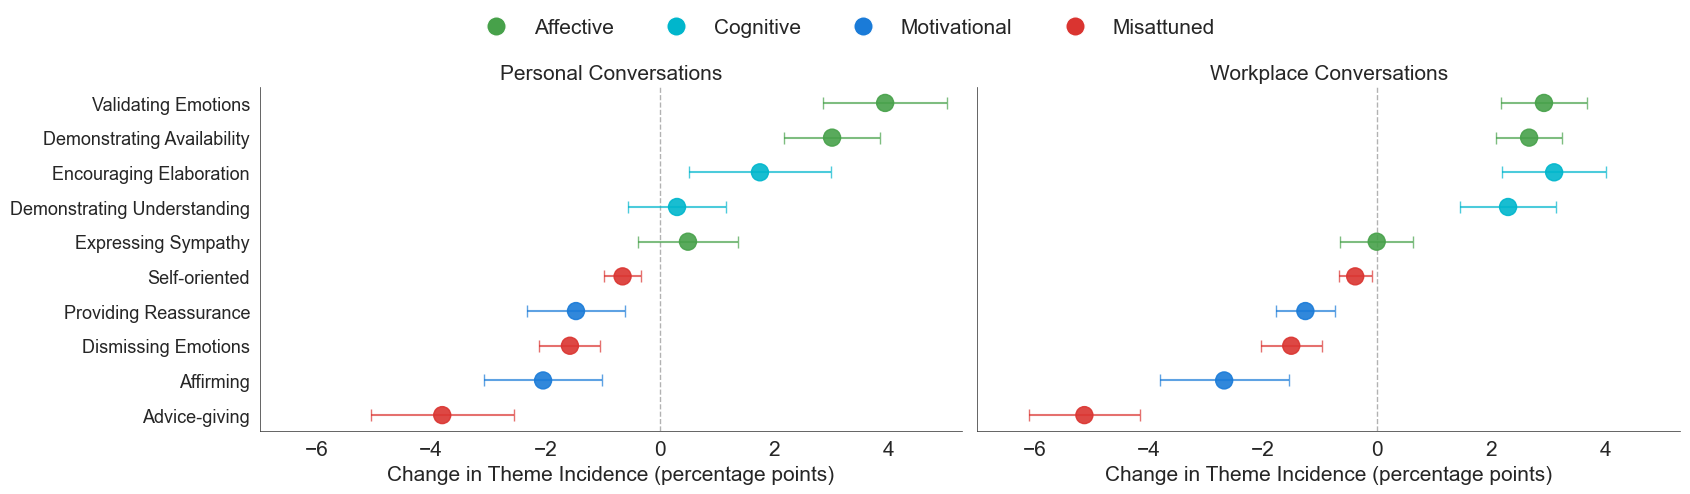

In [4]:
# Helper to clean/standardize level 1 labels
advice_aliases = {"advice giving", "advice-giving", "advicegiving"}
validate_aliases = {"validating emotions", "validating emotion", "validating"}

# Map themes to dimensions for coloring
DIMENSION_MAP = {
    'validating emotions': 'Affective',
    'demonstrating availability': 'Affective',
    'expressing sympathy': 'Affective',
    'demonstrating understanding': 'Cognitive',
    'encouraging elaboration': 'Cognitive',
    'providing reassurance': 'Motivational',
    'affirming': 'Motivational',
    'advice giving': 'Misattuned',
    'advice-giving': 'Misattuned',
    'dismissing emotions': 'Misattuned',
    'self-oriented': 'Misattuned',
    'self oriented': 'Misattuned',
}

DIMENSION_COLORS = {
    'Affective': '#47a14a',
    'Cognitive': '#00b6cc',
    'Motivational': '#1a7bd8',
    'Misattuned': '#da3430',
}

def normalize_theme(name: str):
    return str(name).strip().lower().replace('\n', ' ')

def clean_level(val):
    s = str(val).strip()
    lower = s.lower()
    if lower in {"nan", "none", "unknown", "", "no match found"}:
        return None
    if any(alias in lower for alias in advice_aliases):
        return "Advice-giving"
    if any(alias == lower for alias in validate_aliases):
        return "Validating Emotions"
    return s

# Define function to process data (level 1 themes, absolute count change)
def process_data(data, data_type):
    # Pre-training: first conversations from all conditions
    pre_training = data[data['conversation_number'] == 1].copy()
    # Post-training: conversations 2,3 from AICoach and Influencer conditions
    post_training = data[
        (data['conversation_number'].isin([2, 3])) & 
        (data['condition'].isin(['AICoach', 'CoachPlusInfluencer']))
    ].copy()
    
    n_pre = len(pre_training)
    n_post = len(post_training)
    print(f"{data_type} - Pre-training samples: {n_pre}")
    print(f"{data_type} - Post-training samples: {n_post}")

    level_col = 'Level 1'
    # Clean level 1 labels and drop unknowns
    pre_levels = pre_training[level_col].apply(clean_level).dropna()
    post_levels = post_training[level_col].apply(clean_level).dropna()
    pre_counts = Counter(pre_levels)
    post_counts = Counter(post_levels)
    
    # All categories seen in either split
    categories = sorted(set(pre_counts.keys()) | set(post_counts.keys()))
    
    # Absolute count change (post - pre)
    differences = [post_counts.get(cat, 0) - pre_counts.get(cat, 0) for cat in categories]
    
    # Sort by largest increases
    sorted_idx = np.argsort(differences)[::-1]
    categories_sorted = [categories[i] for i in sorted_idx]
    differences_sorted = [differences[i] for i in sorted_idx]
    
    return categories_sorted, differences_sorted


def _fdr_bh(pvals):
    p = np.asarray(pvals, dtype=float)
    n = len(p)
    order = np.argsort(p)
    ranked = p[order]
    adj = ranked * n / np.arange(1, n + 1)
    adj = np.minimum.accumulate(adj[::-1])[::-1]
    adj = np.clip(adj, 0, 1)
    out = np.empty(n, dtype=float)
    out[order] = adj
    return out


def _holm(pvals):
    p = np.asarray(pvals, dtype=float)
    n = len(p)
    order = np.argsort(p)
    ranked = p[order]
    adj = np.maximum.accumulate((n - np.arange(n)) * ranked)
    adj = np.clip(adj, 0, 1)
    out = np.empty(n, dtype=float)
    out[order] = adj
    return out


def process_data_prop(data, data_type):
    pre_training = data[data['conversation_number'] == 1].copy()
    post_training = data[
        (data['conversation_number'].isin([2, 3])) &
        (data['condition'].isin(['AICoach', 'CoachPlusInfluencer']))
    ].copy()
    n_pre = len(pre_training)
    n_post = len(post_training)
    print(f"{data_type} (prop) - Pre-training samples: {n_pre}")
    print(f"{data_type} (prop) - Post-training samples: {n_post}")

    level_col = 'Level 1'
    pre_levels = pre_training[level_col].apply(clean_level).dropna()
    post_levels = post_training[level_col].apply(clean_level).dropna()
    pre_counts = Counter(pre_levels)
    post_counts = Counter(post_levels)

    categories = sorted(set(pre_counts.keys()) | set(post_counts.keys()))
    rows = []

    for cat in categories:
        pre_c = pre_counts.get(cat, 0)
        post_c = post_counts.get(cat, 0)

        pre_prop = pre_c / n_pre if n_pre else np.nan
        post_prop = post_c / n_post if n_post else np.nan
        delta_pp = (post_prop - pre_prop) * 100  # percentage points

        # 95% CI for difference in proportions (unpooled SE)
        se = np.sqrt(
            (pre_prop * (1 - pre_prop) / n_pre) +
            (post_prop * (1 - post_prop) / n_post)
        ) if n_pre and n_post else np.nan
        ci_95 = 1.96 * se * 100 if np.isfinite(se) else np.nan

        # Two-proportion z-test (pooled SE)
        pooled = (pre_c + post_c) / (n_pre + n_post) if (n_pre + n_post) else np.nan
        se_pool = np.sqrt(
            pooled * (1 - pooled) * (1 / n_pre + 1 / n_post)
        ) if n_pre and n_post and 0 < pooled < 1 else np.nan

        if np.isfinite(se_pool) and se_pool > 0:
            z_stat = (post_prop - pre_prop) / se_pool
            # scipy is imported earlier in the notebook as `stats`
            p_val = 2 * stats.norm.sf(abs(z_stat))
        else:
            z_stat = np.nan
            p_val = np.nan

        rows.append({
            'theme': cat,
            'pre_count': pre_c,
            'post_count': post_c,
            'pre_prop': pre_prop,
            'post_prop': post_prop,
            'delta_pp': delta_pp,
            'ci_95': ci_95,
            'z_stat': z_stat,
            'p_val': p_val,
        })

    df = pd.DataFrame(rows).sort_values('delta_pp')

    # Multiple-comparison corrections across themes
    valid = df['p_val'].notna()
    df['p_fdr_bh'] = np.nan
    df['p_holm'] = np.nan
    if valid.any():
        pvals = df.loc[valid, 'p_val'].to_numpy(dtype=float)
        df.loc[valid, 'p_fdr_bh'] = _fdr_bh(pvals)
        df.loc[valid, 'p_holm'] = _holm(pvals)

    return df

# Process both datasets
personal_categories, personal_differences = process_data(personal_data, "Personal")
workplace_categories, workplace_differences = process_data(workplace_data, "Workplace")

# Build DataFrames for easier sorting/selection
personal_df = pd.DataFrame({'theme': personal_categories, 'delta': personal_differences})
workplace_df = pd.DataFrame({'theme': workplace_categories, 'delta': workplace_differences})

# Helper to wrap labels onto two lines (split at first space)
def wrap_label(name):
    parts = str(name).split(' ', 1)
    return parts[0] + ('\n' + parts[1] if len(parts) > 1 else '')

# Base-rate adjusted (proportion) version only
prop_personal = process_data_prop(personal_data, "Personal")
prop_workplace = process_data_prop(workplace_data, "Workplace")

# Keep top/bottom K by absolute percentage-point change
TOP_K_PROP = 12

def top_bottom(df, col, k):
    return pd.concat([
        df.nlargest(k, col),
        df.nsmallest(k, col)
    ]).drop_duplicates().sort_values(col)

prop_personal_plot = top_bottom(prop_personal, 'delta_pp', TOP_K_PROP)
prop_workplace_plot = top_bottom(prop_workplace, 'delta_pp', TOP_K_PROP)

# Add dimension and colors
palette = DIMENSION_COLORS

def add_dimension(df):
    df = df.copy()
    df['dimension'] = df['theme'].apply(lambda t: DIMENSION_MAP.get(normalize_theme(t)))
    df['color'] = df['dimension'].map(palette).fillna('#6b7280')
    return df

prop_personal_plot = add_dimension(prop_personal_plot)
prop_workplace_plot = add_dimension(prop_workplace_plot)

# Create unified ordering based on average delta_pp across both datasets
# Merge the two datasets
combined = pd.merge(
    prop_personal_plot[['theme', 'delta_pp']], 
    prop_workplace_plot[['theme', 'delta_pp']], 
    on='theme', 
    how='outer',
    suffixes=('_personal', '_workplace')
)
# Calculate average delta_pp for unified ordering
combined['delta_pp_avg'] = combined[['delta_pp_personal', 'delta_pp_workplace']].mean(axis=1)
combined = combined.sort_values('delta_pp_avg')
unified_order = combined['theme'].tolist()

# Reindex both dataframes to follow the unified order
prop_personal_plot = prop_personal_plot.set_index('theme').reindex(unified_order).reset_index()
prop_workplace_plot = prop_workplace_plot.set_index('theme').reindex(unified_order).reset_index()

def plot_prop_changes(ax, df, title):
    # Reset index to ensure proper alignment
    df = df.reset_index(drop=True)
    
    # Remove rows with NaN delta_pp
    df = df.dropna(subset=['delta_pp'])
    
    labels = df['theme']
    y_pos = np.arange(len(labels))
    
    # Plot dots instead of bars
    ax.scatter(df['delta_pp'], y_pos, color=df['color'], s=150, alpha=0.9, zorder=3)
    
    # Add error bars with matching colors
    for i, (idx, row) in enumerate(df.iterrows()):
        ax.errorbar(row['delta_pp'], i, xerr=row['ci_95'], 
                    fmt='none', ecolor=row['color'], capsize=4, linewidth=1.5, alpha=0.7, zorder=2)

    ax.set_yticks(y_pos)
    ax.set_yticklabels(labels)
    
    # Change to dashed vertical line at 0
    ax.axvline(0, color='gray', linewidth=1, linestyle='--', alpha=0.6, zorder=1)
    
    # Set x-axis limits to be consistent
    ax.set_xlim(-7, 5.3)
    
    ax.set_xlabel('Change in Theme Incidence (percentage points)', fontsize=15)
    ax.set_title(title, fontsize=15)
    ax.tick_params(axis='y', labelsize=13)
    ax.tick_params(axis='x', labelsize=15)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.spines['left'].set_linewidth(0.5)
    ax.spines['bottom'].set_linewidth(0.5)

fig, (ax3, ax4) = plt.subplots(1, 2, figsize=(17, 5), sharex=False, sharey=True)
plot_prop_changes(ax3, prop_personal_plot, 'Personal Conversations')
plot_prop_changes(ax4, prop_workplace_plot, 'Workplace Conversations')

handles = [Line2D([0], [0], marker='o', color='w', markerfacecolor=c, 
                  markersize=14, label=label) for label, c in palette.items()]
fig.legend(handles=handles, loc='upper center', ncol=4, frameon=False, fontsize=15)
plt.tight_layout(rect=(0,0,1,0.9))
plt.savefig('figures/figure2B.png', dpi=300, bbox_inches='tight')
plt.show()



Personal - Pre-training samples: 7919
Personal - Post-training samples: 7429


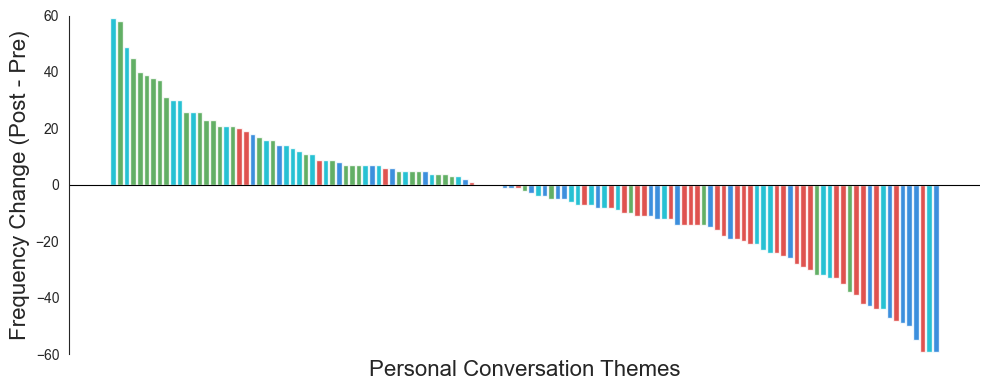

Workplace - Pre-training samples: 11026
Workplace - Post-training samples: 11855


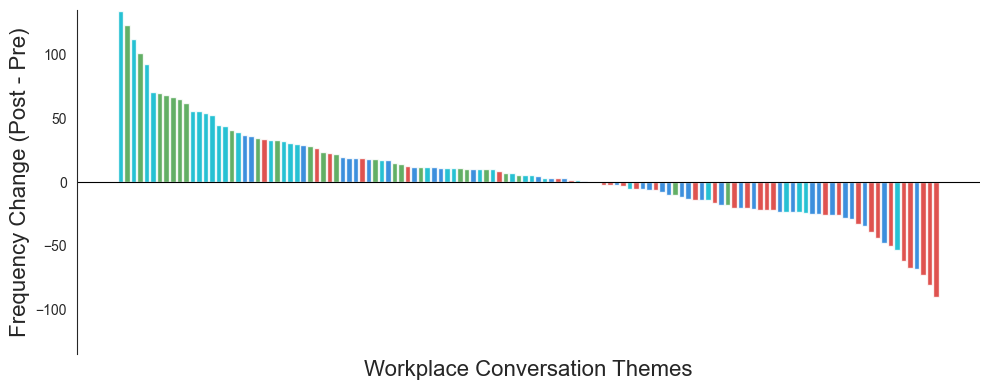


PERSONAL - TOP 12 INCREASED (Post > Pre)
 1. [Cognitive   ] + 59  Asks the question 'How are you feeling right now?'
 2. [Affective   ] + 58  Offers explicit availability to talk, listen, or vent using phrases like 'I'm here for you' or 'If you need someone to talk to'.
 3. [Cognitive   ] + 49  Asks if the other person wants to talk about their feelings or situation.
 4. [Affective   ] + 45  Uses the word 'overwhelming' or a variation of it
 5. [Affective   ] + 40  Uses the phrase 'That sounds' followed by an adjective or descriptor.
 6. [Affective   ] + 39  Uses the word 'scary' or variations of it to describe feelings of fear or uncertainty.
 7. [Affective   ] + 38  Uses language that explicitly describes the experience of shock or being shocked.
 8. [Affective   ] + 37  Explicitly states availability at any time for the other person
 9. [Affective   ] + 31  Repeatedly expresses the phrase 'I am here for you.'
10. [Cognitive   ] + 30  Asks the question 'How are you holding up?'
11. 

In [5]:
# Dimension mapping and colors
DIMENSION_MAP = {
    'validating emotions': 'Affective',
    'demonstrating availability': 'Affective',
    'expressing sympathy': 'Affective',
    'demonstrating understanding': 'Cognitive',
    'encouraging elaboration': 'Cognitive',
    'providing reassurance': 'Motivational',
    'affirming': 'Motivational',
    'advice giving': 'Misattuned',
    'advice-giving': 'Misattuned',
    'dismissing emotions': 'Misattuned',
    'self-oriented': 'Misattuned',
    'self oriented': 'Misattuned',
    
}

DIMENSION_COLORS = {
    'Affective': '#47a14a',
    'Cognitive': '#00b6cc',
    'Motivational': '#1a7bd8',
    'Misattuned': '#da3430',
    'Unknown': '#9ca3af',
}

def normalize_theme(name: str):
    return str(name).strip().lower().replace('\n', ' ')

def get_dimension(level1_value):
    if pd.isna(level1_value):
        return 'Unknown'
    normalized = normalize_theme(level1_value)
    return DIMENSION_MAP.get(normalized, 'Unknown')

def get_column_names(data):
    """Detect the correct column names for interpretation and level 1."""
    if 'Level 3 - interpretation' in data.columns:
        interp_col = 'Level 3 - interpretation'
    elif 'Interpretation' in data.columns:
        interp_col = 'Interpretation'
    else:
        interp_col = 'interpretation'
    
    if 'Level 1' in data.columns:
        level_col = 'Level 1'
    else:
        level_col = 'level 1'
    
    return interp_col, level_col

def plot_frequency_change_colored(data, title, figsize=(7, 3), ylim=None):
    """Plot frequency change (Post - Pre) for conversation themes, colored by dimension."""
    
    interp_col, level_col = get_column_names(data)
    
    # Pre-training: conversation 1 from all conditions
    pre_training = data[data['conversation_number'] == 1].copy()
    # Post-training: conversations 2,3 from AICoach and Influencer conditions
    post_training = data[
        (data['conversation_number'].isin([2, 3])) & 
        (data['condition'].isin(['AICoach', 'CoachPlusInfluencer']))
    ].copy()
    
    print(f"{title} - Pre-training samples: {len(pre_training)}")
    print(f"{title} - Post-training samples: {len(post_training)}")
    
    # Count interpretations
    pre_counts = pre_training[interp_col].value_counts()
    post_counts = post_training[interp_col].value_counts()
    
    # Align indices
    all_interpretations = set(pre_counts.index) | set(post_counts.index)
    pre_counts = pre_counts.reindex(all_interpretations, fill_value=0)
    post_counts = post_counts.reindex(all_interpretations, fill_value=0)
    
    # Calculate change
    change = post_counts - pre_counts
    change_sorted = change.sort_values(ascending=False)
    
    # Map interpretation to Level 1
    interp_to_level1 = data.groupby(interp_col)[level_col].agg(
        lambda x: x.mode().iloc[0] if len(x.mode()) > 0 else None
    )
    
    # Get colors for each bar
    bar_colors = []
    for interp in change_sorted.index:
        level1 = interp_to_level1.get(interp, None)
        dimension = get_dimension(level1)
        bar_colors.append(DIMENSION_COLORS.get(dimension, DIMENSION_COLORS['Unknown']))
    
    # Create figure
    fig, ax = plt.subplots(figsize=figsize)
    
    # Plot bars
    x = np.arange(len(change_sorted))
    bars = ax.bar(x, change_sorted.values, color=bar_colors, width=0.85, alpha=0.85)
    
    ax.axhline(y=0, color='black', linewidth=0.8)
    
    ax.set_ylabel('Frequency Change (Post - Pre)', fontsize=16)
    ax.set_xlabel(f'{title} Conversation Themes', fontsize=16)
    ax.set_xticks([])
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.spines['bottom'].set_visible(False)

    if ylim is not None:
        ax.set_ylim(*ylim)
    
    
    plt.tight_layout()
    return fig, ax, change_sorted, interp_to_level1

# Plot PERSONAL
fig_personal, ax_personal, personal_change, personal_level1_map = plot_frequency_change_colored(
    personal_data, title='Personal', figsize=(10, 4), ylim=(-60, 60)
)
plt.savefig('figures/figure2C-A.png', dpi=600, bbox_inches='tight')
plt.show()

# Plot WORKPLACE
fig_workplace, ax_workplace, workplace_change, workplace_level1_map = plot_frequency_change_colored(
    workplace_data, title='Workplace', figsize=(10, 4), ylim=(-135, 135)
)
plt.savefig('figures/figure2C-B.png', dpi=600, bbox_inches='tight')
plt.show()

# ============================================
# Print top and bottom 12 for each dataset
# ============================================
def print_top_bottom(change_series, level1_map, title, n=12):
    print(f"\n{'='*100}")
    print(f"{title.upper()} - TOP {n} INCREASED (Post > Pre)")
    print(f"{'='*100}")
    for i, (interp, val) in enumerate(change_series.head(n).items(), 1):
        level1 = level1_map.get(interp, 'Unknown')
        dim = get_dimension(level1)
        print(f"{i:2}. [{dim:12}] +{val:3.0f}  {interp}")
    
    print(f"\n{'='*100}")
    print(f"{title.upper()} - TOP {n} DECREASED (Post < Pre)")
    print(f"{'='*100}")
    for i, (interp, val) in enumerate(change_series.tail(n).iloc[::-1].items(), 1):
        level1 = level1_map.get(interp, 'Unknown')
        dim = get_dimension(level1)
        print(f"{i:2}. [{dim:12}] {val:4.0f}  {interp}")

print_top_bottom(personal_change, personal_level1_map, "Personal", n=12)
print_top_bottom(workplace_change, workplace_level1_map, "Workplace", n=12)

In [6]:
df = (
    pd.read_csv('data/experiment_1.csv')
    .drop_duplicates(subset=['conversation_id'])
    .reset_index(drop=True)
)
df = df[['user_id', 'conversation_id',
    'conversation', 'validating_emotions',
    'encouraging_elaboration', 'demonstrating_understanding',
    'advice_giving', 'self_oriented', 'dismissing_emotions',
    'conversation_number', 'starter', 'condition']]

# # only keep conversation_number = 1 for all conditions and conversations 2,3 for aicoach and coachplusinfluence conditions
# df = df[
#     (df['conversation_number'] == 1) |
#     ((df['conversation_number'].isin([2, 3])) & (df['condition'].isin(['AICoach', 'CoachPlusInfluencer'])))
# ]
# # add column 'updated_condition' - which is control if conversation_number = 1 and treatment otherwise
# df['updated_condition'] = df['conversation_number'].apply(lambda x: 'control' if x == 1 else 'treatment')

df['overall_empathy'] = (
    df['validating_emotions']
    + df['encouraging_elaboration']
    + df['demonstrating_understanding']
    - df['advice_giving']
    - df['self_oriented']
    - df['dismissing_emotions']
)
score_col = 'overall_empathy'
ordered_conditions = [c for c in ['Control', 'Video', 'AI Coach', 'Combined'] if c in df['condition'].unique()]

# give names to starters
starter_map = {
"I'm feeling so discouraged.. I just got passed over for the promotion I was working hard for": "promotion",
'I lost my dad last week.. I still can’t believe he’s really gone..': "loss_dad",
'I still can’t believe it… my mom just got diagnosed with cancer. It feels like my whole world just flipped.': "mom_unwell",
"So, I just lost my job today. I had a sense this was coming, but it's still a shock..": "job_loss",
"I've been working so hard but I don't think anyone cares..": "undervalued"
}
df['starter'] = df['starter'].map(starter_map)
starters = df['starter'].unique()



# =============================================================================
# STEP 1: Estimate Measurement Error from Control Group
# Fit random-intercept model: Y_it = μ + u_i + ε_it
# =============================================================================
control_df = df[df['condition'] == 'Control'].copy()

# Fit mixed-effects model on control group only
model = smf.mixedlm(
    f"{score_col} ~ 1",  # intercept-only model
    data=control_df,
    groups=control_df['user_id']
)
result = model.fit()

print("=" * 60)
print("STEP 1: Random-Intercept Model on Control Group")
print("=" * 60)
print(result.summary())

# Extract variance components
sigma_u_sq = result.cov_re.iloc[0, 0]  # Between-person variance (true score)
sigma_eps_sq = result.scale           # Residual variance (measurement error)

print(f"\nVariance Components:")
print(f"  σ²_u (between-person / true score): {sigma_u_sq:.4f}")
print(f"  σ²_ε (residual / measurement error): {sigma_eps_sq:.4f}")

# =============================================================================
# STEP 2: Compute Test-Retest Reliability
# =============================================================================
# Reliability of a single measurement
r_single = sigma_u_sq / (sigma_u_sq + sigma_eps_sq)

# Spearman-Brown reliability for k=2 (averaged post)
k = 2
r_k2 = (k * r_single) / (1 + (k - 1) * r_single)

print(f"\n{'=' * 60}")
print("STEP 2: Reliability Estimates")
print("=" * 60)
print(f"  Single-measurement reliability (r₁): {r_single:.4f}")
print(f"  Two-measurement average reliability (r₂): {r_k2:.4f}")

# =============================================================================
# STEP 3: Compute Standard Error of Change (SE_Δ)
# Pre = single measurement → variance = σ²_ε
# Post = average of 2 measurements → variance = σ²_ε / 2
# SE_Δ = √(σ²_ε + σ²_ε/2) = √(3/2 * σ²_ε)
# =============================================================================
SE_delta = np.sqrt((3/2) * sigma_eps_sq)

print(f"\n{'=' * 60}")
print("STEP 3: Standard Error of Change")
print("=" * 60)
print(f"  SE_Δ = √(3/2 × σ²_ε) = √(3/2 × {sigma_eps_sq:.4f}) = {SE_delta:.4f}")

# =============================================================================
# STEP 4: Compute Individual Change Scores for ALL Participants
# =============================================================================
def compute_change(sub):
    """Compute pre-post change for each participant."""
    first = (sub[sub['conversation_number'] == 1]
             .groupby('user_id')[score_col].mean())
    after = (sub[sub['conversation_number'].isin([2, 3])]
             .groupby('user_id')[score_col].mean())
    comp = pd.concat([first, after], axis=1, keys=['pre', 'post']).dropna()
    comp['delta'] = comp['post'] - comp['pre']
    return comp.reset_index()

z_thresh = 1.96

# Classify all participants
all_change = []
for cond in ordered_conditions:
    comp = compute_change(df[df['condition'] == cond])
    comp['z'] = comp['delta'] / SE_delta
    comp['condition'] = cond
    comp['classification'] = pd.cut(
        comp['z'],
        bins=[-np.inf, -z_thresh, z_thresh, np.inf],
        labels=['Worsened', 'No reliable change', 'Improved']
    )
    all_change.append(comp)

change_df = pd.concat(all_change, ignore_index=True)

# =============================================================================
# STEP 5: Validate Using Control Group
# =============================================================================
control_change = change_df[change_df['condition'] == 'Control']
control_counts = control_change['classification'].value_counts(normalize=True)

print(f"\n{'=' * 60}")
print("STEP 5: Validation - Control Group Classification")
print("=" * 60)
print(f"Expected under null (no true change):")
print(f"  Improved:          ~2.5%")
print(f"  No reliable change: ~95%")
print(f"  Worsened:          ~2.5%")
print(f"\nObserved in Control Group (N={len(control_change)}):")
for cat in ['Improved', 'No reliable change', 'Worsened']:
    pct = control_counts.get(cat, 0) * 100
    print(f"  {cat}: {pct:.1f}%")

# =============================================================================
# Build Summary Table for Plotting
# =============================================================================
rows = []
for cond in ordered_conditions:
    comp = change_df[change_df['condition'] == cond]
    n = len(comp)
    rows.append({
        'condition': cond,
        'N': n,
        'Improved': (comp['classification'] == 'Improved').mean(),
        'No reliable change': (comp['classification'] == 'No reliable change').mean(),
        'Worsened': (comp['classification'] == 'Worsened').mean(),
        'Mean Δ': comp['delta'].mean(),
        'SD Δ': comp['delta'].std()
    })

resp_df = pd.DataFrame(rows).set_index('condition')
print(f"\n{'=' * 60}")
print("Summary Table: Responder Classification by Condition")
print("=" * 60)
print(resp_df.round(3))

STEP 1: Random-Intercept Model on Control Group
            Mixed Linear Model Regression Results
Model:            MixedLM Dependent Variable: overall_empathy
No. Observations: 735     Method:             REML           
No. Groups:       245     Scale:              5.3823         
Min. group size:  3       Log-Likelihood:     -1910.1767     
Max. group size:  3       Converged:          Yes            
Mean group size:  3.0                                        
--------------------------------------------------------------
               Coef.   Std.Err.    z     P>|z|  [0.025  0.975]
--------------------------------------------------------------
Intercept      -1.448     0.236  -6.130  0.000  -1.910  -0.985
Group Var      11.868     0.653                               


Variance Components:
  σ²_u (between-person / true score): 11.8676
  σ²_ε (residual / measurement error): 5.3823

STEP 2: Reliability Estimates
  Single-measurement reliability (r₁): 0.6880
  Two-measurement avera

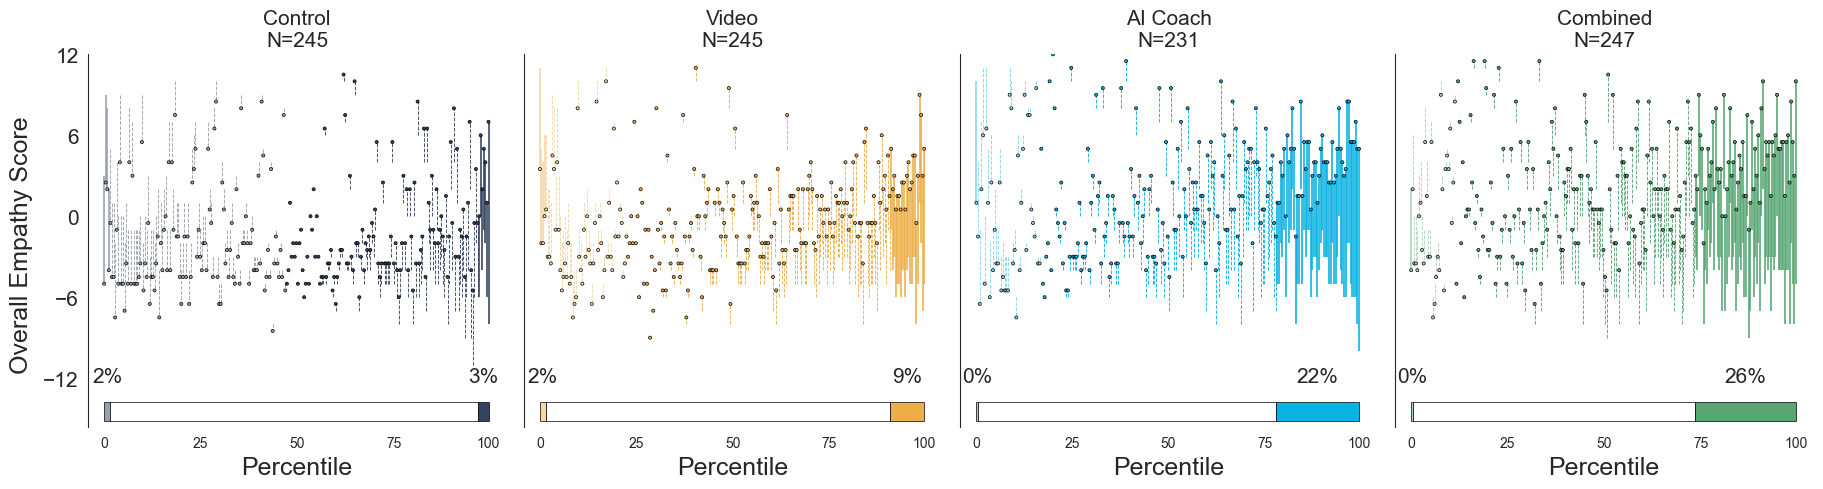

In [7]:
fig, axes = plt.subplots(1, 4, figsize=(18, 5), sharey=True)

def compute_change(sub):
    first = (sub[sub['conversation_number'] == 1]
             .groupby('user_id')[score_col].mean())
    after = (sub[sub['conversation_number'].isin([2, 3])]
             .groupby('user_id')[score_col].mean())
    comp = pd.concat([first, after], axis=1, keys=['first','after']).dropna()
    comp['delta'] = comp['after'] - comp['first']
    return comp.reset_index()

mapping = {
    'Control': 'Control',
    'Didactic Instruction': 'Video',
    'Influencer': 'Video',
    'Personalized Feedback': 'AI Coach',
    'AICoach': 'AI Coach',
    'Combined Training': 'Combined',
    'CoachPlusInfluencer': 'Combined'
}
ordered_conditions = ['Control', 'Video', 'AI Coach', 'Combined']
# map condition names to ordered conditions
df['condition'] = (df['condition']
                   .astype(str)
                   .str.strip()
                   .str.replace(r'\s+', ' ', regex=True)
                   .replace(mapping))  # Define color scheme matching Plot B
                   

custom_palette = {
    'Control': '#34435E',
    'Video': '#EDAE49', 
    'AI Coach': '#08B2E3',
    'Combined': '#57A773',
}

# Create lighter versions for declines (add transparency effect via lighter hex)
def lighten_color(hex_color, factor=0.5):
    """Create a lighter version of the color"""
    hex_color = hex_color.lstrip('#')
    r, g, b = int(hex_color[:2], 16), int(hex_color[2:4], 16), int(hex_color[4:], 16)
    r = int(r + (255 - r) * factor)
    g = int(g + (255 - g) * factor)
    b = int(b + (255 - b) * factor)
    return f'#{r:02x}{g:02x}{b:02x}'

condition_colors = {
    cond: {'positive': color, 'negative': lighten_color(color, 0.5)}
    for cond, color in custom_palette.items()
}

all_scores = df[score_col].dropna()
ymin, ymax = float(np.floor(all_scores.min())), float(np.ceil(all_scores.max()))
y_range = ymax - ymin
ymin_extended = ymin - 0.2 * y_range  
# Use condition-specific colors
def get_color(z, cond):
    colors = condition_colors[cond]
    if z >= 0:
        return colors['positive']
    else:
        return colors['negative']

def get_linestyle(z):
    # Dashed for non-reliable, solid for reliable
    if abs(z) >= z_thresh:
        return '-'      # solid for reliable
    else:
        return '--'     # dashed for non-reliable

for ax, cond in zip(axes, ordered_conditions):
    sub = df[df['condition'] == cond]
    comp = compute_change(sub)
    
    # Add RCI z-scores and colors
    comp['z'] = comp['delta'] / SE_delta
    comp['color'] = comp['z'].apply(lambda z: get_color(z, cond))
    comp['linestyle'] = comp['z'].apply(get_linestyle)
    
    # Sort by delta
    comp = comp.sort_values('delta').reset_index(drop=True)
    comp['idx'] = np.arange(len(comp))

    if comp.empty:
        ax.axis('off')
        continue

    # Line width: thicker for reliable changes
    def get_lw(z):
        return 1.3 if abs(z) >= z_thresh else 0.7
    
    for _, row in comp.iterrows():
        ax.vlines(row['idx'], row['first'], row['after'],
                  colors=row['color'], 
                  linewidth=get_lw(row['z']),
                  linestyles=row['linestyle'],
                  alpha=0.9)
    
    ax.scatter(comp['idx'], comp['after'],
               c=comp['color'], marker='o', facecolors='white', edgecolors='black', s=5, zorder=2, linewidths=0.5)

    # Counts
    n_reliable_imp = (comp['z'] >= z_thresh).sum()
    n_reliable_dec = (comp['z'] <= -z_thresh).sum()
    n_total = len(comp)

    # Calculate percentages
    pct_reliable_imp = 100 * n_reliable_imp / n_total
    pct_reliable_dec = 100 * n_reliable_dec / n_total
    pct_non_reliable = 100 - pct_reliable_imp - pct_reliable_dec

    # Position bar at bottom of plot
    bar_y = ymin_extended + 0.05 * y_range  # slightly above bottom
    bar_height = 0.06 * y_range
    bar_left = 0
    bar_width = len(comp) - 1

    # Reliable decline (left) - lighter color
    ax.barh(bar_y, pct_reliable_dec/100 * bar_width, height=bar_height, 
            left=bar_left, color=condition_colors[cond]['negative'], edgecolor='black', linewidth=0.5)
    # Non-reliable (middle) - gray/white
    ax.barh(bar_y, pct_non_reliable/100 * bar_width, height=bar_height,
            left=bar_left + pct_reliable_dec/100 * bar_width, color='white', edgecolor='black', linewidth=0.5)
    # Reliable improvement (right) - full color
    ax.barh(bar_y, pct_reliable_imp/100 * bar_width, height=bar_height,
            left=bar_left + (pct_reliable_dec + pct_non_reliable)/100 * bar_width, 
            color=condition_colors[cond]['positive'], edgecolor='black', linewidth=0.5)

    # Reliable decline label (above left segment)
    if pct_reliable_dec > 0:
        ax.text(bar_left + pct_reliable_dec/100 * bar_width / 2, bar_y + bar_height + 0.02 * y_range,
                f'{pct_reliable_dec:.0f}%', ha='center', va='bottom', fontsize=15)

    # Reliable improvement label (above right segment)
    if pct_reliable_imp > 0:
        ax.text(bar_left + (pct_reliable_dec + pct_non_reliable + pct_reliable_imp/2)/100 * bar_width, 
                bar_y + bar_height + 0.02 * y_range,
                f'{pct_reliable_imp:.0f}%', ha='center', va='bottom', fontsize=15)
        
    ax.set_title(f"{cond}\nN={n_total}", fontsize=15)
    
    ax.set_xlim(-1, len(comp))

    ax.set_ylim(ymin_extended, ymax)
    if cond == 'Control':  
        ax.set_yticks([-12, -6, 0, 6, 12])
        ax.tick_params(axis='y', labelsize=15)   
    ax.spines[['top','right', 'bottom']].set_visible(False)
    ax.set_xlabel('Percentile', fontsize=18)
    n = len(comp)
    tick_positions = [0, n*0.25, n*0.5, n*0.75, n-1]
    tick_labels = ['0', '25', '50', '75', '100']

    ax.set_xlim(-10, n + 10)
    ax.set_xticks(tick_positions)
    ax.set_xticklabels(tick_labels)#
legend_elements = [
    Line2D([0], [0], color='black', lw=2.5, linestyle='-', label='Reliable improvement'),
    Line2D([0], [0], color='black', lw=1.5, linestyle='--', label='Non-reliable improvement'),
    Line2D([0], [0], color='gray', lw=1.5, linestyle=':', label='Non-reliable decline'),
    Line2D([0], [0], color='gray', lw=2.5, linestyle='-', label='Reliable decline')
]

fig.text(-0.01, 0.5, "Overall Empathy Score",
         rotation='vertical', va='center', fontsize=18)

plt.tight_layout()
plt.savefig("figures/figure3A.png", dpi=200, bbox_inches='tight')
plt.show()


Pairwise post-baseline contrasts (term_a - term_b):
                  Dimension                 Contrast  Diff (beta)  SE_diff      z  p_value  p_holm  Diff (in SD)
    Encouraging Elaboration    personalized vs video        0.430    0.095  4.535    0.000   0.000         0.389
    Encouraging Elaboration        combined vs video        0.403    0.094  4.299    0.000   0.000         0.365
    Encouraging Elaboration combined vs personalized       -0.027    0.099 -0.269    0.788   1.000        -0.024
        Validating Emotions    personalized vs video        0.240    0.070  3.435    0.001   0.007         0.237
        Validating Emotions        combined vs video        0.379    0.070  5.418    0.000   0.000         0.374
        Validating Emotions combined vs personalized        0.139    0.074  1.866    0.062   0.373         0.137
Demonstrating Understanding    personalized vs video        0.212    0.069  3.065    0.002   0.020         0.214
Demonstrating Understanding        combined 

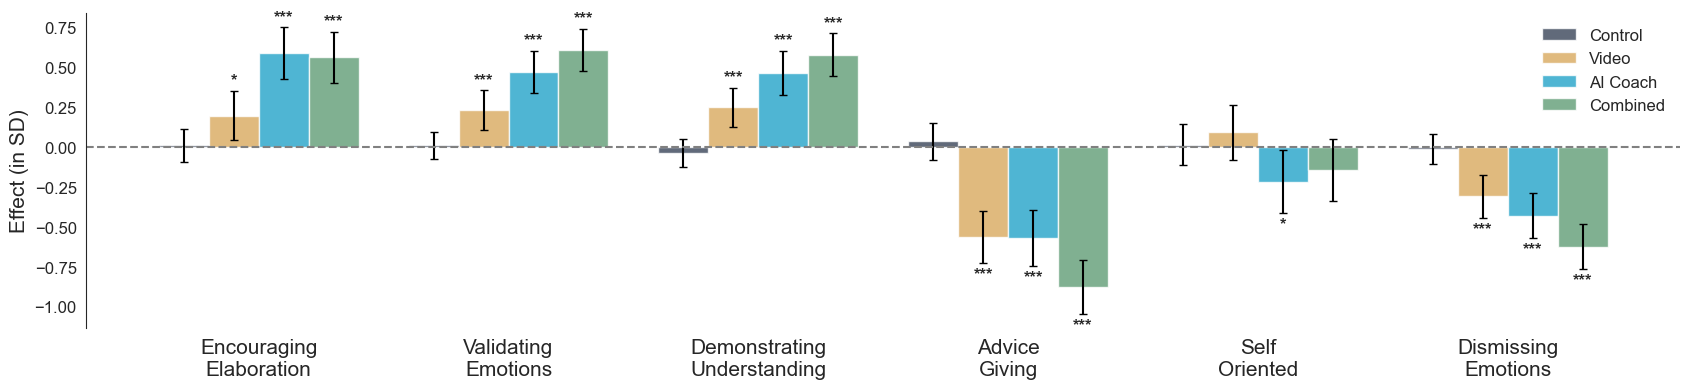

In [8]:
# standardized effects
std_devs = {}
for dv in dependent_vars:
  std_devs[dv] = data[dv].std()
effects_with_ci = []
for i, dv in enumerate(dependent_vars):
  model = models[i]
  for term in independent_vars[3:]:
    condition = {
      'round_indicator': 'Control',
      'Didactic Instruction*round_indicator': 'Video',
      'Personalized Feedback*round_indicator': 'AI Coach',
      'Combined Training*round_indicator': 'Combined',
    }[term]
    coef = model.params[term]
    se = model.bse[term]
    sd = std_devs[dv]
    
    # Get p-value for significance testing
    p_value = model.pvalues[term]
    
    # Calculate 95% confidence interval (1.96 * SE)
    ci_margin = 1.96 * se / sd
    
    effects_with_ci.append(
      {
        'Condition': condition,
        'Dimension': dv.replace('_', ' ').title(),
        'Effect (in SD)': coef / sd,
        'CI_Margin (in SD)': ci_margin,
        'P_Value': p_value,
      }
    )

effect_df_reg = pd.DataFrame(effects_with_ci)

def wald_contrast(model, term_a, term_b):
    """Cluster-robust Wald test for difference between two coefficients."""
    cov = model.cov_params()
    diff = model.params[term_a] - model.params[term_b]
    se_diff = np.sqrt(
        cov.loc[term_a, term_a]
        + cov.loc[term_b, term_b]
        - 2 * cov.loc[term_a, term_b]
    )
    z = diff / se_diff
    p_value = 2 * norm.sf(abs(z))
    return diff, se_diff, z, p_value

contrast_specs = [
  ('Personalized Feedback*round_indicator', 'Didactic Instruction*round_indicator', 'personalized vs video'),
  ('Combined Training*round_indicator', 'Didactic Instruction*round_indicator', 'combined vs video'),
  ('Combined Training*round_indicator', 'Personalized Feedback*round_indicator', 'combined vs personalized'),
]

contrast_rows = []
for i, dv in enumerate(dependent_vars):
  model = models[i]
  sd = std_devs[dv]
  for term_a, term_b, label in contrast_specs:
    diff, se_diff, z, p_value = wald_contrast(model, term_a, term_b)
    contrast_rows.append(
      {
        'Dimension': dv.replace('_', ' ').title(),
        'Contrast': label,
        'Diff (beta)': diff,
        'SE_diff': se_diff,
        'z': z,
        'p_value': p_value,
        'Diff (in SD)': diff / sd,
      }
    )

pairwise_contrasts = pd.DataFrame(contrast_rows)

_, pairwise_contrasts['p_holm'], _, _ = multipletests(
    pairwise_contrasts['p_value'], 
    method='holm'
)

pairwise_contrasts_display = pairwise_contrasts.copy()
pairwise_contrasts_display[[
  'Diff (beta)', 'SE_diff', 'z', 'p_value', 'p_holm', 'Diff (in SD)'
]] = pairwise_contrasts_display[[
  'Diff (beta)', 'SE_diff', 'z', 'p_value', 'p_holm', 'Diff (in SD)'
]].round(3)
print('Pairwise post-baseline contrasts (term_a - term_b):')
cols = [
  'Dimension', 'Contrast', 'Diff (beta)', 'SE_diff', 'z', 'p_value', 'p_holm', 'Diff (in SD)'
]
print(pairwise_contrasts_display[cols].to_string(index=False))

def get_significance_stars(p_value):
    if p_value < 0.001:
        return '***'
    elif p_value < 0.01:
        return '**'
    elif p_value < 0.05:
        return '*'
    else:
        return ''

custom_palette = {
    'Control': '#34435E',
    'Video': '#EDAE49', 
    'AI Coach': '#08B2E3',
    'Combined': '#57A773',
}
plt.figure(figsize=(17, 4))
sns.barplot(
  data=effect_df_reg,
  x='Dimension',
  y='Effect (in SD)',
  hue='Condition',
  palette=custom_palette,
  capsize=0.1,
  errcolor='black',
  errwidth=1,
  ci=None,
  alpha=0.8,
  # edgecolor='black',
)

conditions = [
  'Control',
  'Video',
  'AI Coach',
  'Combined',
]
n_dimensions = len(effect_df_reg['Dimension'].unique())
n_conditions = len(conditions)

for dim_idx in range(n_dimensions):
  dimension = effect_df_reg['Dimension'].unique()[dim_idx]
  
  
  for cond_idx, condition in enumerate(conditions):
    subset = effect_df_reg[
      (effect_df_reg['Dimension'] == dimension) & (effect_df_reg['Condition'] == condition)
    ]
    if not subset.empty:
      x_pos = dim_idx + (cond_idx - (n_conditions - 1) / 2) * 0.8 / n_conditions
      effect_val = subset['Effect (in SD)'].values[0]
      ci_margin = subset['CI_Margin (in SD)'].values[0]
      p_value = subset['P_Value'].values[0]
      
      plt.errorbar(
        x=x_pos,
        y=effect_val,
        yerr=ci_margin,
        fmt='none',
        color='black',
        capsize=3,
      )
      
      # Add significance stars
      stars = get_significance_stars(p_value)
      if stars:
        # Position stars above the error bar for positive effects, below for negative effects
        if effect_val >= 0:
          star_y = effect_val + ci_margin + 0.02  # Above for positive
          va = 'bottom'
        else:
          star_y = effect_val - ci_margin - 0.02  # Below for negative
          va = 'top'
        
        plt.text(x_pos, star_y, stars, ha='center', va=va, 
                fontsize=12, fontweight='bold')
  
labels = [
  'Encouraging\nElaboration',
  'Validating\nEmotions',
  'Demonstrating\nUnderstanding',
  'Advice\nGiving',
  'Self\nOriented',
  'Dismissing\nEmotions',
]
plt.gca().set_xticklabels(labels, fontsize=15)
plt.axhline(0, color='gray', linestyle='--')
plt.xlabel('')
plt.ylabel('Effect (in SD)', fontsize=15)
plt.gca().tick_params(axis='y', labelsize=12)
plt.legend(title='', frameon=False, fontsize=12)
# remove right and top spines
plt.gca().spines['right'].set_visible(False)
plt.gca().spines['top'].set_visible(False)
plt.gca().spines['bottom'].set_visible(False)

# plt.gca().spines['left'].set_color('black')
# plt.gca().spines['bottom'].set_color('lightgray')
plt.tight_layout()
plt.savefig('figures/figure3B.png', dpi=300, bbox_inches='tight')
plt.show()


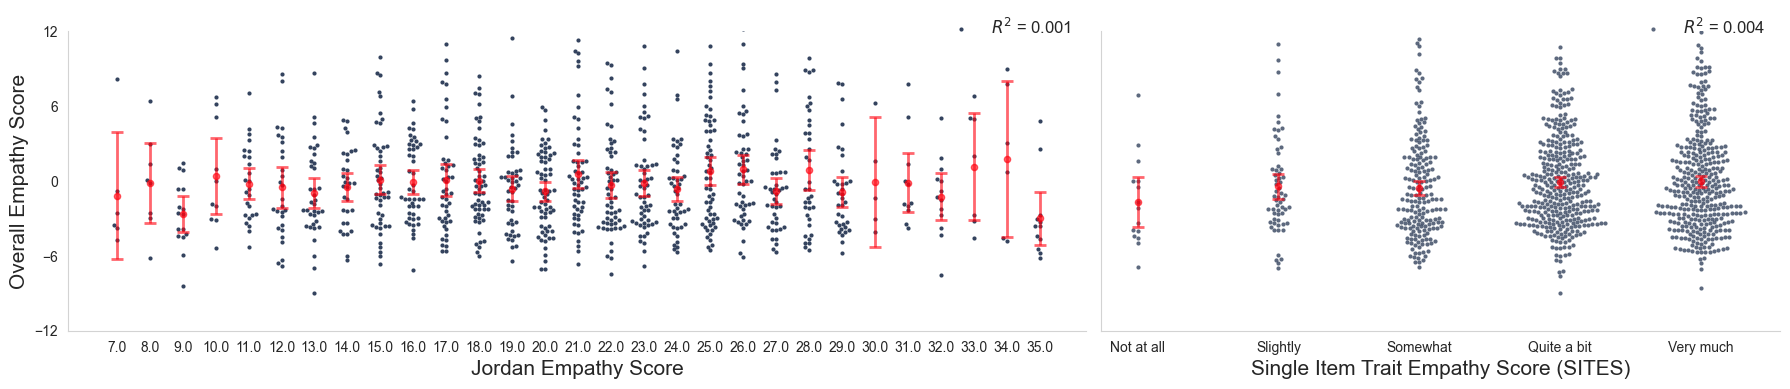

In [9]:
# Set a clean, professional style
sns.set_style("white")

# Load baseline responses from the unified E4 export
baseline_source_cols = [
    'baseline_empathy_item_1', 'baseline_empathy_item_2', 'baseline_empathy_item_3', 'baseline_empathy_item_4',
    'baseline_empathy_item_5', 'baseline_empathy_item_6', 'baseline_empathy_item_7', 'baseline_empathy_item_8'
]
baseline = (
    experiment_1_data[['user_id'] + baseline_source_cols]
    .drop_duplicates(subset=['user_id'])
    .rename(columns={col: col.replace('baseline_', '') for col in baseline_source_cols})
)

# Map text responses to numeric values
response_mapping = {
    'not_at_all': 1,
    'slightly': 2,
    'somewhat': 3,
    'quite_a_bit': 4,
    'very_much': 5
}

# Detect baseline item naming scheme after renaming
baseline_cols = [
    'empathy_item_1', 'empathy_item_2', 'empathy_item_3', 'empathy_item_4', 
    'empathy_item_5', 'empathy_item_6', 'empathy_item_7'
]
sites_col = 'empathy_item_8'

# Convert responses to numeric
for col in baseline_cols + [sites_col]:
    baseline[col] = baseline[col].map(response_mapping)

baseline['jordan_empathy'] = baseline[baseline_cols].sum(axis=1)
baseline['baseline8'] = baseline[sites_col]

# Convert responses to numeric
all_baseline_cols = baseline_cols + ['baseline8']

for col in all_baseline_cols:
    baseline[col] = baseline[col].map(response_mapping).fillna(baseline[col])
    baseline[col] = pd.to_numeric(baseline[col], errors='coerce')

# Jordan empathy is sum of items 1-7; item 8 is SITES
baseline_cols = all_baseline_cols[:7]
sites_col = all_baseline_cols[7]
baseline['jordan_empathy'] = baseline[baseline_cols].sum(axis=1)
baseline['baseline8'] = baseline[sites_col]

# Calculate overall empathy score from communication behaviors
data['overall_empathy_score'] = (
    data['validating_emotions'] + 
    data['encouraging_elaboration'] + 
    data['demonstrating_understanding'] - 
    data['advice_giving'] - 
    data['self_oriented'] - 
    data['dismissing_emotions']
)
swarm_color = "#34435E" 


# Aggregate to user level (mean across conversations)
user_empathy = data.groupby('user_id')['overall_empathy_score'].mean().reset_index()

# Merge jordan empathy with overall empathy scores
plot_data = baseline[['user_id', 'jordan_empathy']].merge(
    user_empathy, on='user_id', how='inner'
)

# Remove any missing values
plot_data = plot_data.dropna()

# Create cleaner subplots with shared y-axis - Jordan empathy gets 65%, SITES gets 35%
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 4), sharey=True, 
                               gridspec_kw={'width_ratios': [0.6, 0.4]})

# Define nice colors - keep them the same

# Add jitter to overall empathy score for better visualization
jitter_strength = 0.1
plot_data_jittered = plot_data.copy()
plot_data_jittered['overall_empathy_score_jittered'] = (
    plot_data_jittered['overall_empathy_score'] + 
    np.random.normal(0, jitter_strength, size=len(plot_data_jittered))
)
# Plot 1: Jordan Empathy - Use continuous values, not binned
sns.swarmplot(data=plot_data_jittered, x='jordan_empathy', y='overall_empathy_score_jittered', 
              ax=ax1, color=swarm_color, alpha=1, size=3)

# Add means and error bars for Jordan Empathy (AFTER swarmplot)
unique_jordan_vals = sorted(plot_data['jordan_empathy'].unique())

for i, val in enumerate(unique_jordan_vals):
    val_data = plot_data[plot_data['jordan_empathy'] == val]['overall_empathy_score']
    if not val_data.empty:
        val_mean = np.mean(val_data)

        if len(val_data) > 1:
            se = stats.sem(val_data)
            ci_95 = se * stats.t.ppf((1 + 0.95) / 2, len(val_data) - 1)
        else:
            ci_95 = 0

        # Draw error bar above the swarm (use i for categorical position, not val)
        ax1.errorbar(i, val_mean, yerr=ci_95,
                    color='#FF000D', capsize=4, capthick=2,
                    linewidth=2, zorder=6, alpha=0.6)
        # Draw mean marker on top
        ax1.scatter(i, val_mean, color='#FF000D', marker='o', s=20,
                    zorder=7, linewidth=1, alpha=0.6)

# Calculate R-squared for jordan empathy
correlation1 = plot_data['jordan_empathy'].corr(plot_data['overall_empathy_score'])
r_squared1 = correlation1 ** 2

# Add R-squared legend
leg1 = ax1.legend([f'$R^2$ = {r_squared1:.3f}'], fontsize=12, loc='upper right', bbox_to_anchor=(1, 1.1))
if leg1 is not None:
    leg1.set_frame_on(False)

ax1.set_xlabel('Jordan Empathy Score', fontsize=15)
ax1.set_ylabel('Overall Empathy Score', fontsize=15)

# Plot 2: SITES - Much cleaner with proper labels
if 'baseline8' in baseline.columns:
    sites_data = baseline[['user_id', 'baseline8']].merge(
        user_empathy, on='user_id', how='inner'
    ).dropna()
    
    # Add jitter to SITES data
    sites_data_jittered = sites_data.copy()
    sites_data_jittered['overall_empathy_score_jittered'] = (
        sites_data_jittered['overall_empathy_score'] + 
        np.random.normal(0, jitter_strength, size=len(sites_data_jittered))
    )
    
    # Create proper labels for SITES
    sites_data['sites_label'] = sites_data['baseline8'].map({
        1: 'Not at all', 2: 'Slightly', 3: 'Somewhat', 
        4: 'Quite a bit', 5: 'Very much'
    })
    sites_data_jittered['sites_label'] = sites_data_jittered['baseline8'].map({
        1: 'Not at all', 2: 'Slightly', 3: 'Somewhat', 
        4: 'Quite a bit', 5: 'Very much'
    })
    
    # Ensure proper ordering
    sites_order = ['Not at all', 'Slightly', 'Somewhat', 'Quite a bit', 'Very much']
    
    sns.swarmplot(data=sites_data_jittered, x='sites_label', y='overall_empathy_score_jittered', 
                  ax=ax2, color=swarm_color, alpha=.8, size=3, order=sites_order)
    
    
    # Add means and error bars for SITES
    unique_sites_vals = sorted(sites_data['baseline8'].unique())
    
    for i, val in enumerate(unique_sites_vals):
        val_data = sites_data[sites_data['baseline8'] == val]['overall_empathy_score']
        if not val_data.empty:
            val_mean = np.mean(val_data)

            if len(val_data) > 1:
                se = stats.sem(val_data)
                ci_95 = se * stats.t.ppf((1 + 0.95) / 2, len(val_data) - 1)
            else:
                ci_95 = 0

            # Draw error bar above the swarm
            ax2.errorbar(i, val_mean, yerr=ci_95,
                         color='#FF000D', capsize=4, capthick=2,
                         linewidth=2, zorder=6, alpha=0.6)
            # Draw mean marker on top
            ax2.scatter(i, val_mean, color='#FF000D', marker='o', s=20,
                        zorder=7, linewidth=1, alpha=0.6)
    
    # Calculate R-squared for SITES
    correlation2 = sites_data['baseline8'].corr(sites_data['overall_empathy_score'])
    r_squared2 = correlation2 ** 2
    
    # Add R-squared legend
    leg2 = ax2.legend([f'$R^2$ = {r_squared2:.3f}'], fontsize=12, loc='upper right', bbox_to_anchor=(1, 1.1))
    if leg2 is not None:
        leg2.set_frame_on(False)
    
    ax2.set_xlabel('Single Item Trait Empathy Score (SITES)', fontsize=15)
    ax2.set_ylabel('')  # Remove y-label since it's shared
    
    # Rotate x-axis labels for better readability
    ax2.tick_params(axis='x', rotation=0)

# Set y-axis limits and ticks for both plots
for ax in [ax1, ax2]:
    ax.set_ylim(-12, 12)
    ax.set_yticks([-12, -6, 0, 6, 12])
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.spines['bottom'].set_color('lightgray')
    ax.spines['left'].set_color('lightgray')


plt.tight_layout()
plt.savefig('figures/figure5A.png', 
           dpi=600, bbox_inches='tight', facecolor='white')
plt.show()


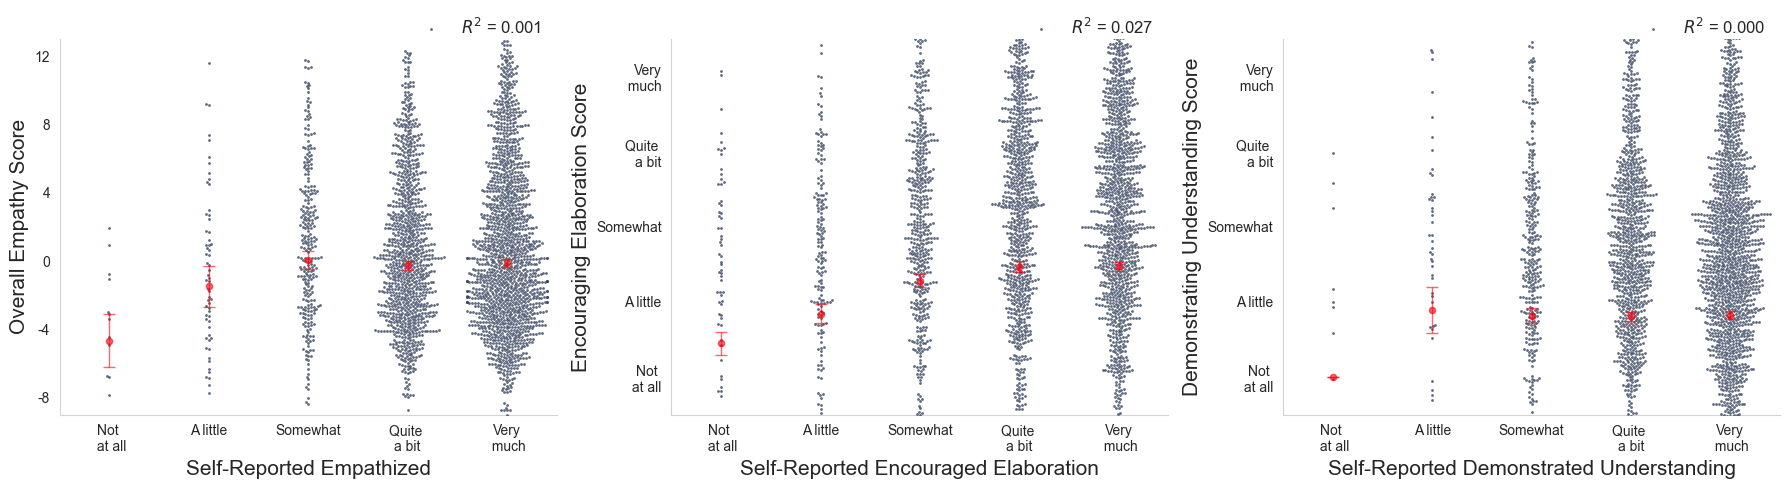

In [10]:
# Prepare beeswarm plots for the three pairs (with swapped axes):
plot_pairs = [
    {
        "x": "self_empathized",  # Now x-axis
        "y": "overall_empathy_score",  # Use continuous score instead of binned
        "xlabel": "Self-Reported Empathized",
        "ylabel": "Overall Empathy Score",
        "y_labels": ['-8', '-4', '0', '4', '8', '12'],  # Numeric labels
        "x_labels": likert_labels  # Use for x-axis (self-reported)
    },
    {
        "x": "self_encourage_elaboration",  # Now x-axis
        "y": "encouraging_elaboration",  # Now y-axis
        "xlabel": "Self-Reported Encouraged Elaboration",
        "ylabel": "Encouraging Elaboration Score",
        "y_labels": likert_labels,  # Use for y-axis
        "x_labels": likert_labels  # Use for x-axis
    },
    {
        "x": "self_showed_understanding",  # Now x-axis
        "y": "demonstrating_understanding",  # Now y-axis
        "xlabel": "Self-Reported Demonstrated Understanding",
        "ylabel": "Demonstrating Understanding Score",
        "y_labels": likert_labels,  # Use for y-axis
        "x_labels": likert_labels  # Use for x-axis
    }
]

likert_map = {
    "Not at all": 1,
    "A little": 2,
    "Somewhat": 3,
    "Quite a bit": 4, 
    "Very much": 5, 
}
fig, axes = plt.subplots(1, 3, figsize=(18, 5), sharey=False)

jitter_strength = 0.95
swarm_color = "#34435E" 
line_color = "black"

def mean_ci(series, conf=0.95):
    n = series.count()
    mean = series.mean()
    sem = series.sem()
    if n > 1:
        h = sem * stats.t.ppf((1 + conf) / 2., n-1)
    else:
        h = np.nan
    return mean, mean-h, mean+h

for i, pair in enumerate(plot_pairs):
    ax = axes[i]
    plot_data = data[[pair["x"], pair["y"]]].dropna().copy()
    plot_data[pair["x"]] = plot_data[pair["x"]].astype(int)
    plot_data[pair["y"]] = plot_data[pair["y"]].astype(int)
    plot_data[f'{pair["y"]}_jittered'] = (
        plot_data[pair["y"]] + np.random.normal(jitter_strength, jitter_strength, size=len(plot_data))
    )
    
    # Swarmplot: x = self-report, y = objective (with jitter on y)
    sns.swarmplot(
        x=pair["x"],  # x-axis: self-reported (no jitter needed)
        y=f'{pair["y"]}_jittered',  # y-axis: objective with jitter
        data=plot_data,
        ax=ax,
        size=2,
        color=swarm_color,
        alpha=.8,
        order=[1,2,3,4,5]  # This applies to x-axis now
    )
    
    # Add mean and confidence intervals for each x value (self-reported)
    means = []
    ci_lowers = []
    ci_uppers = []
    x_vals = np.array([1, 2, 3, 4, 5])
    for xval in x_vals:
        # Get y-values (objective scores) for each x-value (self-reported)
        yvals = plot_data.loc[plot_data[pair["x"]] == xval, pair["y"]]
        mean, ci_low, ci_up = mean_ci(yvals)
        means.append(mean)
        ci_lowers.append(ci_low)
        ci_uppers.append(ci_up)
    
        # Plot means and CIs above the swarm
    ax.errorbar(
        x=x_vals-1, y=means,
        yerr=[np.array(means)-np.array(ci_lowers), np.array(ci_uppers)-np.array(means)],
        fmt='none', color='#FF000D', elinewidth=1, capsize=4, zorder=6, alpha=0.6
    )
    ax.scatter(x_vals-1, means, color='#FF000D', s=20, zorder=7, alpha=0.6)

    # Calculate R-squared and add to plot
    correlation = plot_data[pair["x"]].corr(plot_data[pair["y"]])
    r_squared = correlation ** 2
    
    # Add R-squared legend in top right
    leg = ax.legend([f'$R^2$ = {r_squared:.3f}'], fontsize=12, loc='upper right', bbox_to_anchor=(1, 1.1))
    if leg is not None:
        leg.set_frame_on(False)

    # Set axis labels and ticks
    ax.set_xlabel(pair["xlabel"], fontsize=15)
    ax.set_ylabel(pair["ylabel"], fontsize=15)
    ax.set_xticks([0,1,2,3,4])
    ax.set_xticklabels(pair["x_labels"], rotation=0, ha='center')
    
    # Set y-axis based on plot type
    if i == 0:  # First plot: Overall Empathy Score (adjust range to actual data)
        ax.set_yticks([-8, -4, 0, 4, 8, 12])
        ax.set_yticklabels(['-8', '-4', '0', '4', '8', '12'])
        ax.set_ylim(-9, 13)  # Give a bit of padding above and below
    else:  # Other plots: Likert scale 1-5
        ax.set_yticks([1,2,3,4,5])
        ax.set_yticklabels(pair["y_labels"])
        ax.set_ylim(0.5,5.5)
    
    ax.set_xlim(-0.5,4.5)
    
    # Match the styling of the 1x2 plot
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.spines['bottom'].set_color('lightgray')
    ax.spines['left'].set_color('lightgray')

plt.tight_layout()
plt.savefig('figures/figure5B.png', dpi=600, bbox_inches='tight')
plt.show()

In [11]:
# Robustness check for Figure 5B: how does the relationship between self-reported and objective scores change when we only use the first conversation?
first_convo_data = data[data['conversation_number'] == 1].copy()

robustness_pairs = [
    ('self_empathized', 'overall_empathy_score', 'Self empathized vs Overall empathy'),
    ('self_encourage_elaboration', 'encouraging_elaboration', 'Self encouraged elaboration vs Encouraging elaboration'),
    ('self_showed_understanding', 'demonstrating_understanding', 'Self showed understanding vs Demonstrating understanding'),
]

rows = []
for x_col, y_col, label in robustness_pairs:
    # Conversation-1 only
    first_tmp = first_convo_data[[x_col, y_col]].dropna().copy()
    first_tmp[x_col] = pd.to_numeric(first_tmp[x_col], errors='coerce')
    first_tmp[y_col] = pd.to_numeric(first_tmp[y_col], errors='coerce')
    first_tmp = first_tmp.dropna()

    # All conversations (current Figure 5B setup)
    all_tmp = data[[x_col, y_col]].dropna().copy()
    all_tmp[x_col] = pd.to_numeric(all_tmp[x_col], errors='coerce')
    all_tmp[y_col] = pd.to_numeric(all_tmp[y_col], errors='coerce')
    all_tmp = all_tmp.dropna()

    r2_all = all_tmp[x_col].corr(all_tmp[y_col]) ** 2
    r2_first = first_tmp[x_col].corr(first_tmp[y_col]) ** 2

    rows.append({
        'comparison': label,
        'R2_all_conversations': r2_all,
        'n_all': len(all_tmp),
        'R2_first_conversation_only': r2_first,
        'n_first': len(first_tmp),
    })

robustness_df = pd.DataFrame(rows)
print('how does the relationship between self-reported and LLM scores change when we only use the first conversation?')
display(robustness_df.round(4))


how does the relationship between self-reported and LLM scores change when we only use the first conversation?


,comparison,R2_all_conversations,n_all,R2_first_conversation_only,n_first
0,Self empathized vs Overall empathy,0.0012,2904,0.0071,968
1,Self encouraged elaboration vs Encouraging ela...,0.0269,2904,0.0593,968
2,Self showed understanding vs Demonstrating und...,0.0001,2904,0.0010,968


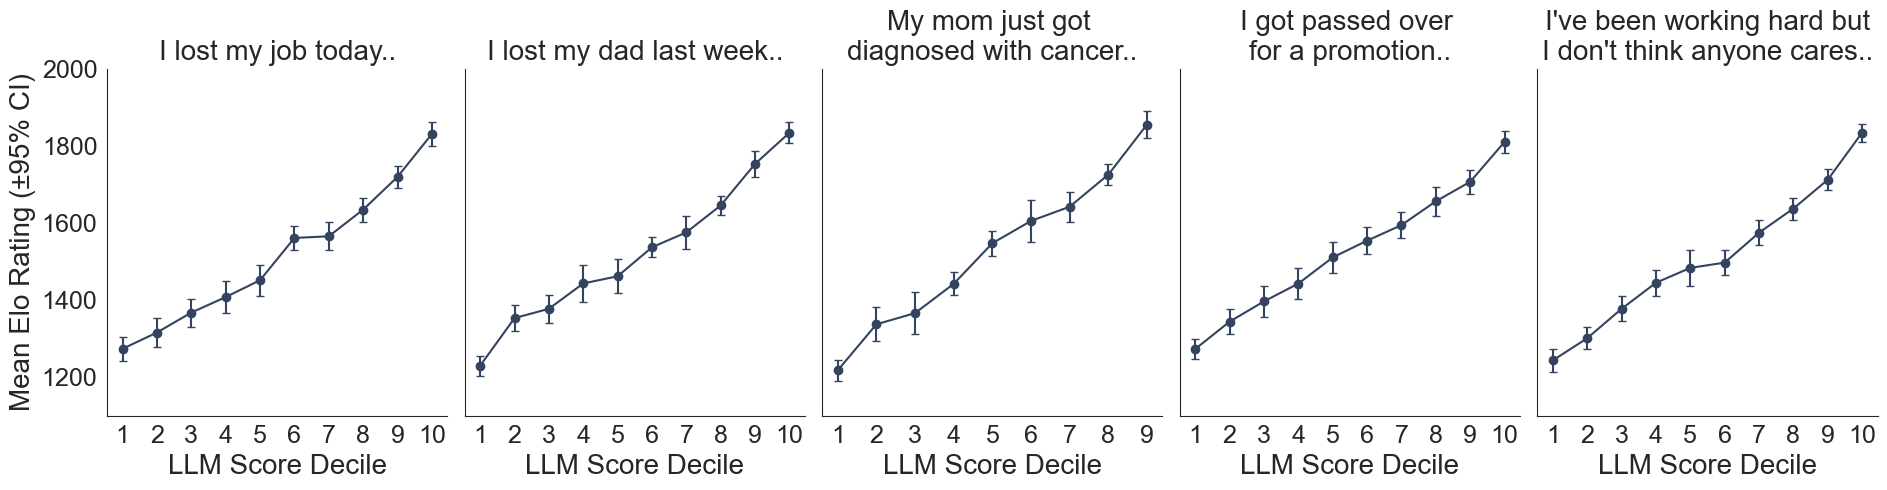

In [12]:
# Load the 5 different datasets
elo_data = pd.read_csv("data/elo_rankings.csv")

starters = {
    'Job Loss': "I lost my job today..",
    'Loss Dad': "I lost my dad last week..",
    'Mom Unwell': "My mom just got \ndiagnosed with cancer..",
    'Promotion': "I got passed over \nfor a promotion..", 
    'Undervalued': "I've been working hard but\nI don't think anyone cares.."
}
elo_starters = elo_data['starter'].unique()

fig, axes = plt.subplots(1, 5, figsize=(19, 5), sharey=True)

for i, title in enumerate(starters):
    
    df = elo_data.loc[elo_data['starter'] == elo_starters[i]].copy()
    df['emp_bin'] = pd.qcut(df['overall_empathy'], 10, duplicates='drop')
    g = df.groupby('emp_bin')['elo_rating'].agg(['mean','count','std'])
    g['se'] = g['std'] / np.sqrt(g['count'])
    x = np.arange(len(g)) + 1
    color = '#34435E'
    
    axes[i].errorbar(x, g['mean'], yerr=1.96*g['se'], fmt='o-', capsize=3, color=color)
    axes[i].set_xticks(x)
    axes[i].set_xticklabels([f'{j+1}' for j in range(len(g))], fontsize=20)
    axes[i].set_xlabel('LLM Score Decile', fontsize=20)
    axes[0].set_ylabel('Mean Elo Rating (±95% CI)', fontsize=20)
    axes[i].set_title(starters[title], fontsize=20)
    
    # remove spines
    axes[i].spines['top'].set_visible(False)
    axes[i].spines['right'].set_visible(False)
    axes[i].set_ylim(1100, 2000)
    axes[i].tick_params(axis='both', which='major', labelsize=18)

plt.tight_layout()
plt.savefig('figures/figure6A.png', dpi=300)


Model 1a | DV: select_higher_annotation | IV: abs_score_diff + topics
                             Results: Logit
Model:              Logit                    Method:           MLE       
Dependent Variable: select_higher_annotation Pseudo R-squared: 0.056     
Date:               2026-02-27 17:41         AIC:              1611.5036 
No. Observations:   1409                     BIC:              1643.0074 
Df Model:           5                        Log-Likelihood:   -799.75   
Df Residuals:       1403                     LL-Null:          -846.99   
Converged:          1.0000                   LLR p-value:      7.7278e-19
No. Iterations:     6.0000                   Scale:            1.0000    
--------------------------------------------------------------------------
                        Coef.   Std.Err.     z     P>|z|    [0.025  0.975]
--------------------------------------------------------------------------
const                  -0.0871    0.1492  -0.5836  0.5595  -0.3795  

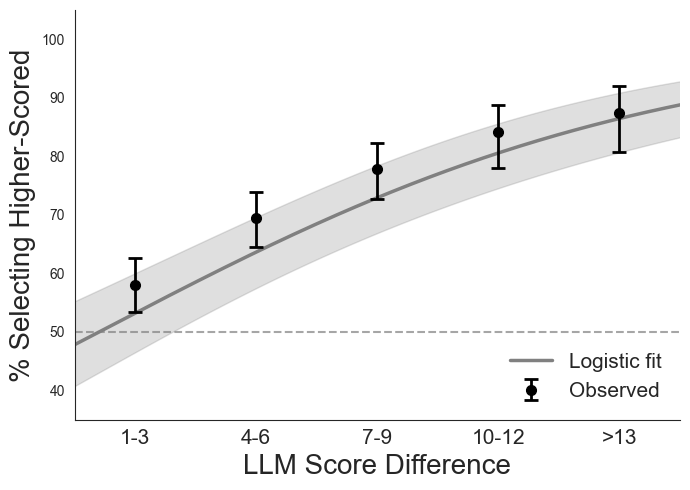

Spearman rho (BT rank vs Elo rank): 0.849, p = 8.90e-43, N = 150


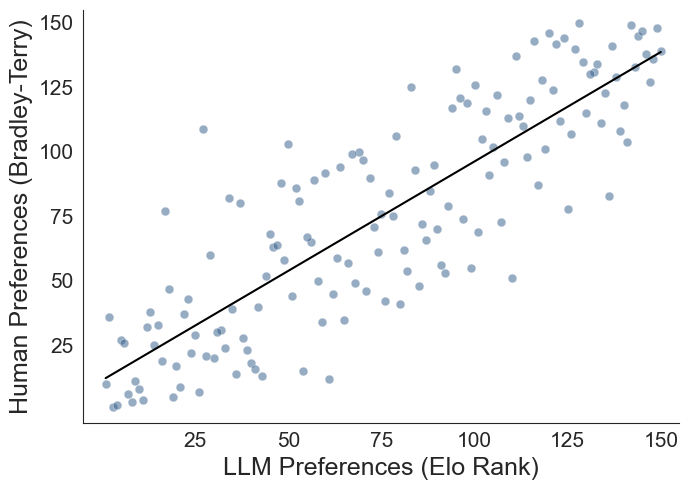

In [13]:
elo_dict = pd.read_csv('data/elo_rankings.csv').set_index('conversation_id')['elo_rating'].to_dict()
COMPONENT_COLS = [
    'validating_emotions',
    'encouraging_elaboration',
    'demonstrating_understanding',
    'advice_giving',
    'dismissing_emotions',
    'self_oriented',
]

expt_2 = pd.read_csv("data/experiment_2.csv").copy()

elo_df = pd.read_csv("data/elo_rankings.csv", dtype={"conversation_id": str})
elo_dict = elo_df.set_index("conversation_id")["elo_rating"].to_dict()

expt_2["conversation_left_id"] = expt_2["conversation_left_id"].astype(str)
expt_2["conversation_right_id"] = expt_2["conversation_right_id"].astype(str)
expt_2["conv_left_elo"] = expt_2["conversation_left_id"].map(elo_dict)
expt_2["conv_right_elo"] = expt_2["conversation_right_id"].map(elo_dict)

topic_col = 'scenario'
participant_col = 'participant_id'

# Overall score gap
if 'abs_score_diff' not in expt_2.columns:
    if 'llm_score_diff' in expt_2.columns:
        expt_2['abs_score_diff'] = expt_2['llm_score_diff'].abs()
    elif {'conv_left_empathy_score', 'conv_right_empathy_score'}.issubset(expt_2.columns):
        expt_2['abs_score_diff'] = (expt_2['conv_left_empathy_score'] - expt_2['conv_right_empathy_score']).abs()
    else:
        raise KeyError('Need abs_score_diff or enough columns to construct it.')

# Forced-choice match DV (participant vs LLM-preferred side from Elo)
if 'select_match' not in expt_2.columns:
    side_map = {
        'left': 'left', 'a': 'left', 'conversation_a': 'left',
        'right': 'right', 'b': 'right', 'conversation_b': 'right',
    }
    human = expt_2['participant_choice'].astype(str).str.strip().str.lower().map(side_map).fillna(expt_2['participant_choice'])
    llm_side = pd.Series(pd.NA, index=expt_2.index, dtype='object')
    llm_side[expt_2['conv_left_elo'] > expt_2['conv_right_elo']] = 'left'
    llm_side[expt_2['conv_right_elo'] > expt_2['conv_left_elo']] = 'right'
    expt_2['select_match'] = np.where(llm_side.notna(), (human == llm_side).astype(int), np.nan)

# Component diffs
for c in COMPONENT_COLS:
    std = f'{c}_diff'
    alt = f'diff_{c}'
    if std not in expt_2.columns and alt in expt_2.columns:
        expt_2[std] = expt_2[alt]

if not all(f'{c}_diff' in expt_2.columns for c in COMPONENT_COLS):
    ann = (
        pd.read_csv("data/experiment_1.csv")
        .drop_duplicates(subset=['conversation_id'])
        [['conversation_id', *COMPONENT_COLS]]
        .copy()
    )
    ann['conversation_id'] = ann['conversation_id'].astype(str)
    ann = ann.groupby('conversation_id', as_index=False)[COMPONENT_COLS].mean()

    tmp = expt_2.copy()
    tmp['conversation_left_id'] = tmp['conversation_left_id'].astype(str)
    tmp['conversation_right_id'] = tmp['conversation_right_id'].astype(str)

    left = ann.rename(columns={'conversation_id': 'conversation_left_id', **{c: f'left_{c}' for c in COMPONENT_COLS}})
    right = ann.rename(columns={'conversation_id': 'conversation_right_id', **{c: f'right_{c}' for c in COMPONENT_COLS}})
    tmp = tmp.merge(left, on='conversation_left_id', how='left').merge(right, on='conversation_right_id', how='left')

    for c in COMPONENT_COLS:
        std = f'{c}_diff'
        if std not in tmp.columns:
            tmp[std] = tmp[f'left_{c}'] - tmp[f'right_{c}']
    expt_2 = tmp


def fit_clustered_logit(y, X, groups, label):
    X = sm.add_constant(X.reset_index(drop=True), has_constant='add')
    y = y.reset_index(drop=True)
    g = groups.reset_index(drop=True)
    res = sm.Logit(y, X).fit(cov_type='cluster', cov_kwds={'groups': g}, disp=False)
    print(f"\n{'='*60}\n{label}\n{'='*60}")
    print(res.summary2())
    return res


results = {}

def with_topic_dummies(data):
    return pd.get_dummies(data[topic_col], drop_first=True, prefix='topic').astype(int)

# Model 1a
m1a = expt_2.dropna(subset=['select_higher_annotation', 'abs_score_diff', topic_col, participant_col]).copy()
X1a = pd.concat([m1a[['abs_score_diff']].reset_index(drop=True), with_topic_dummies(m1a).reset_index(drop=True)], axis=1)
results['model_1a'] = fit_clustered_logit(m1a['select_higher_annotation'], X1a, m1a[participant_col], 'Model 1a | DV: select_higher_annotation | IV: abs_score_diff + topics')

# Model 1b
m1b = expt_2.dropna(subset=['select_match', 'abs_score_diff', topic_col, participant_col]).copy()
X1b = pd.concat([m1b[['abs_score_diff']].reset_index(drop=True), with_topic_dummies(m1b).reset_index(drop=True)], axis=1)
results['model_1b'] = fit_clustered_logit(m1b['select_match'], X1b, m1b[participant_col], 'Model 1b | DV: select_match | IV: abs_score_diff + topics')

# Model 2a
comp_cols = [f'{c}_diff' for c in COMPONENT_COLS]
m2a = expt_2.dropna(subset=['select_higher_annotation', *comp_cols, topic_col, participant_col]).copy()
X2a = pd.concat([m2a[comp_cols].reset_index(drop=True), with_topic_dummies(m2a).reset_index(drop=True)], axis=1)
results['model_2a'] = fit_clustered_logit(m2a['select_higher_annotation'], X2a, m2a[participant_col], 'Model 2a | DV: select_higher_annotation | IV: 6 component diffs + topics')

# Model 2b
m2b = expt_2.dropna(subset=['select_match', *comp_cols, topic_col, participant_col]).copy()
X2b = pd.concat([m2b[comp_cols].reset_index(drop=True), with_topic_dummies(m2b).reset_index(drop=True)], axis=1)
results['model_2b'] = fit_clustered_logit(m2b['select_match'], X2b, m2b[participant_col], 'Model 2b | DV: select_match | IV: 6 component diffs + topics')


plot_df = expt_2.dropna(subset=['abs_score_diff', 'select_higher_annotation']).copy()
bins = [0, 3, 6, 9, 12, 100]
labels = ['1-3', '4-6', '7-9', '10-12', '>13']
plot_df['score_diff_bin'] = pd.cut(plot_df['abs_score_diff'], bins=bins, labels=labels)

rows = []
for i, label in enumerate(labels):
    sub = plot_df[plot_df['score_diff_bin'] == label]
    if len(sub) == 0:
        continue
    p = sub['select_higher_annotation'].mean()
    lo, hi = proportion_confint(sub['select_higher_annotation'].sum(), len(sub), alpha=0.05, method='wilson')
    mid = (bins[i] + bins[i + 1]) / 2
    if bins[i + 1] == 100:
        mid = bins[i] + 1.5
    rows.append({'bin': label, 'mid': mid, 'p': p, 'lo': lo, 'hi': hi})
obs = pd.DataFrame(rows)

m1a_res = results['model_1a']
x = np.linspace(0, plot_df['abs_score_diff'].max(), 200)
exog_names = m1a_res.model.exog_names
pred = pd.DataFrame(0.0, index=np.arange(len(x)), columns=exog_names)
if 'const' in pred.columns:
    pred['const'] = 1.0
pred['abs_score_diff'] = x

y = m1a_res.predict(pred)
params = m1a_res.params.values
cov = m1a_res.cov_params().values
Xp = pred.values
lp = Xp @ params
se = np.sqrt(np.einsum('ij,jk,ik->i', Xp, cov, Xp))
y_lo = 1 / (1 + np.exp(-(lp - 1.96 * se)))
y_hi = 1 / (1 + np.exp(-(lp + 1.96 * se)))

fig, ax = plt.subplots(figsize=(7, 5))
ax.fill_between(x, y_lo * 100, y_hi * 100, alpha=0.25, color='gray')
ax.plot(x, y * 100, color='gray', linewidth=2.5, label='Logistic fit')
ax.errorbar(
    obs['mid'],
    obs['p'] * 100,
    yerr=[(obs['p'] - obs['lo']) * 100, (obs['hi'] - obs['p']) * 100],
    fmt='o', color='black', markersize=7, capsize=5, capthick=2, linewidth=2, label='Observed', zorder=5,
)
ax.axhline(50, color='gray', linestyle='--', linewidth=1.5, alpha=0.7)
ax.set_xlabel('LLM Score Difference', fontsize=20)
ax.set_ylabel('% Selecting Higher-Scored', fontsize=20)
ax.set_xlim([0, 15])
ax.set_ylim([35, 105])
ax.set_yticks([40, 50, 60, 70, 80, 90, 100])
ax.set_xticks(obs['mid'])
ax.set_xticklabels(obs['bin'], fontsize=15)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.legend(loc='lower right', frameon=False, fontsize=15)
plt.tight_layout()
Path('figures').mkdir(exist_ok=True)
plt.savefig('figures/figure6B.png', dpi=300, bbox_inches='tight')
plt.show()


comparisons = []
for _, row in expt_2.dropna(subset=['participant_choice']).iterrows():
    l, r = row['conversation_left_id'], row['conversation_right_id']
    winner, loser = (l, r) if row['participant_choice'] == 'left' else (r, l)
    comparisons.append((winner, loser))

all_ids = sorted({w for w, _ in comparisons} | {l for _, l in comparisons})
idx = {cid: i for i, cid in enumerate(all_ids)}
pairs = [(idx[w], idx[l]) for w, l in comparisons]
bt = choix.ilsr_pairwise(len(all_ids), pairs, alpha=0.01)

bt_rankings = pd.DataFrame({'conversation_id': all_ids, 'bt_score': bt})
bt_rankings['elo_rating'] = bt_rankings['conversation_id'].map(elo_dict)
bt_elo = bt_rankings.dropna(subset=['bt_score', 'elo_rating']).copy()
bt_elo['bt_rank'] = bt_elo['bt_score'].rank(ascending=False)
bt_elo['elo_rank'] = bt_elo['elo_rating'].rank(ascending=False)

rho, pval = spearmanr(bt_elo['bt_rank'], bt_elo['elo_rank'])
print(f"Spearman rho (BT rank vs Elo rank): {rho:.3f}, p = {pval:.2e}, N = {len(bt_elo)}")

fig, ax = plt.subplots(figsize=(7, 5))
ax.scatter(bt_elo['elo_rank'], bt_elo['bt_rank'], alpha=0.5, s=40, color='#2E5A87', edgecolor='white', linewidth=0.5)
z = np.polyfit(bt_elo['elo_rank'], bt_elo['bt_rank'], 1)
x_trend = np.linspace(bt_elo['elo_rank'].min(), bt_elo['elo_rank'].max(), 100)
ax.plot(x_trend, np.poly1d(z)(x_trend), color='black', linewidth=1.5)
ax.set_xlabel('LLM Preferences (Elo Rank)', fontsize=18)
ax.set_ylabel('Human Preferences (Bradley-Terry)', fontsize=18)
ax.set_xlim([-5, 155])
ax.set_ylim([-5, 155])
ax.set_xticks([25, 50, 75, 100, 125, 150])
ax.set_yticks([25, 50, 75, 100, 125, 150])
ax.tick_params(axis='both', labelsize=15)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.tight_layout()
plt.savefig('figures/figure6C.png', dpi=300, bbox_inches='tight')
plt.show()

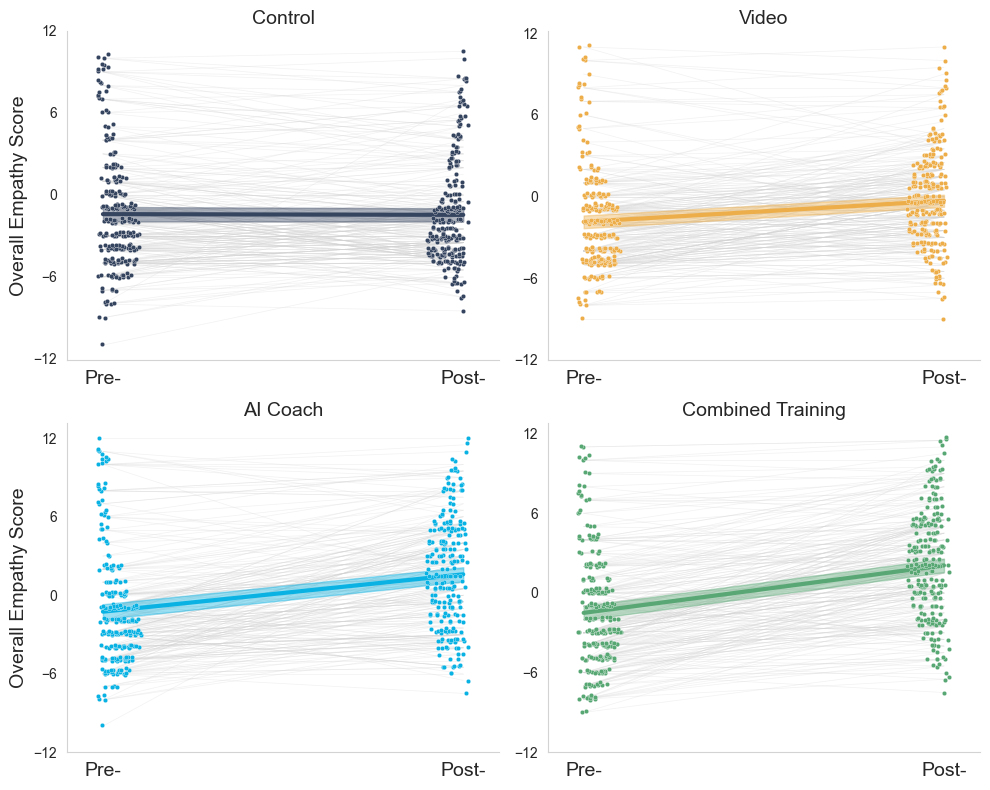

In [14]:
df = (
    pd.read_csv('data/experiment_1.csv')
    .drop_duplicates(subset=['conversation_id'])
    .reset_index(drop=True)
)

# Keep only necessary columns
df = df[['user_id', 'conversation_id', 'conversation',
    'validating_emotions', 'encouraging_elaboration', 'demonstrating_understanding',
    'advice_giving', 'self_oriented', 'dismissing_emotions',
    'conversation_number', 'condition']]

# Now run the empathy score calculation
positive_behaviors = ['validating_emotions', 'encouraging_elaboration', 'demonstrating_understanding']
negative_behaviors = ['dismissing_emotions', 'advice_giving', 'self_oriented']

df['overall_empathy'] = df[positive_behaviors].sum(axis=1) - df[negative_behaviors].sum(axis=1)

condition_mapping = {
    'Control': 'Control',
    'Influencer': 'Video',
    'AICoach': 'AI Coach',
    'CoachPlusInfluencer': 'Combined Training',
}

df['condition'] = df['condition'].map(condition_mapping)

# Custom color palette
custom_palette = {
    'Control': '#34435E',
    'Video': '#EDAE49', 
    'AI Coach': '#08B2E3',
    'Combined Training': '#57A773',
}

# Updated to include all 4 conditions
condition_order = ['Control', 'Video', 'AI Coach', 'Combined Training']

# Create pre-post data structure
df_pre = df[df['conversation_number'] == 1][['user_id', 'condition', 'overall_empathy']].copy()
df_pre['time_point'] = 'Pre'
df_pre = df_pre.rename(columns={'overall_empathy': 'score'})

df_post = df[df['conversation_number'].isin([2, 3])].groupby(['user_id', 'condition'])['overall_empathy'].mean().reset_index()
df_post['time_point'] = 'Post'
df_post = df_post.rename(columns={'overall_empathy': 'score'})

df_combined = pd.concat([df_pre, df_post], ignore_index=True)

# Filter for users with both pre and post measurements
users_with_both = df_combined.groupby('user_id')['time_point'].nunique()
complete_users = users_with_both[users_with_both == 2].index
df_plot = df_combined[df_combined['user_id'].isin(complete_users)].copy()

# Create figure with 2x2 layout
fig, axes = plt.subplots(2, 2, figsize=(10, 8))

for i, condition in enumerate(condition_order):
    # Calculate row and column position
    row = i // 2
    col = i % 2
    ax = axes[row, col]
    
    # Filter data for this condition
    condition_data = df_plot[df_plot['condition'] == condition]
    
    if len(condition_data) == 0:
        ax.set_title(f'{condition}')
        ax.set_xticks([0, 1])
        ax.set_xticklabels(['Pre-', 'Post-'])
        continue
    
    # Create user-level data for connecting lines
    user_data = condition_data.pivot(index='user_id', columns='time_point', values='score')
    
    # Add kernel density estimates
    pre_data = condition_data[condition_data['time_point'] == 'Pre']
    post_data = condition_data[condition_data['time_point'] == 'Post']
    
    # Plot individual user trajectories as gray lines FIRST (so they go under everything)
    np.random.seed(42)
    for user_id in user_data.index:
        pre_score = user_data.loc[user_id, 'Pre']
        post_score = user_data.loc[user_id, 'Post']
        if pd.notna(pre_score) and pd.notna(post_score):
            ax.plot([0, 1], [pre_score, post_score], 
                   color='lightgray', alpha=0.3, linewidth=0.5, zorder=1)
    
    # Calculate and plot TREND LINE (mean change = intervention effect)
    if len(pre_data) > 0 and len(post_data) > 0:
        pre_mean = pre_data['score'].mean()
        post_mean = post_data['score'].mean()
        
        # Add confidence interval around the means (below the mean line)
        pre_sem = stats.sem(pre_data['score'])
        post_sem = stats.sem(post_data['score'])
        
        ax.fill_between([0, 1], 
                        [pre_mean - 1.96*pre_sem, post_mean - 1.96*post_sem],
                        [pre_mean + 1.96*pre_sem, post_mean + 1.96*post_sem],
                        color=custom_palette[condition], alpha=0.4, zorder=4)
        
        # Plot trend line showing intervention effect (on top of CI band)
        ax.plot([0, 1], [pre_mean, post_mean], 
                color=custom_palette[condition].replace('cc', ''), 
                linewidth=3, alpha=0.99, zorder=5)
  
    # Function to create distribution outline with dots
    def plot_distribution_outline(x_pos, scores, color, ax, side='right'):
        if len(scores) < 2:
            # If too few points, just plot them with small jitter
            jitter = np.random.uniform(-0.12, 0.15, len(scores))
            ax.scatter(x_pos + jitter, scores, color=color, alpha=0.8, s=20, zorder=10)
            return
                    
        # Create KDE for distribution shape
        kde = stats.gaussian_kde(scores)
        
        # Create y range for evaluation
        y_min, y_max = scores.min() - 0.3, scores.max() + 0.3
        y_range = np.linspace(y_min, y_max, 150)
        density = kde(y_range)
        
        # Normalize density to reasonable width
        max_width = 0.18
        density_norm = density / density.max() * max_width
        
        # Create orderly bins for y-values
        n_bins = min(30, len(scores) // 2 + 8)  # More bins for better distribution
        y_bins = np.linspace(scores.min() - 0.2, scores.max() + 0.2, n_bins)
        
        # Assign each score to a bin
        bin_indices = np.digitize(scores, y_bins)
        
        plotted_x = []
        plotted_y = []
        
        # Process each bin
        for bin_idx in range(1, len(y_bins)):
            # Get scores in this bin
            bin_scores = scores[bin_indices == bin_idx]
            if len(bin_scores) == 0:
                continue
                
            # Find the bin center for density calculation
            bin_center = (y_bins[bin_idx-1] + y_bins[bin_idx]) / 2
            closest_density_idx = np.argmin(np.abs(y_range - bin_center))
            width = density_norm[closest_density_idx]
            
            # Sort scores within bin for consistent ordering
            bin_scores_sorted = np.sort(bin_scores)
            
            # Calculate how many dots can fit across the width
            dot_spacing = 0.018  # Slightly tighter spacing
            max_dots_per_row = max(1, int(width / dot_spacing)) if width > 0.01 else 1
            
            # Arrange dots in orderly rows and columns
            for i, score in enumerate(bin_scores_sorted):
                row = i // max_dots_per_row
                col = i % max_dots_per_row
                
                # Calculate x position for this dot
                if max_dots_per_row == 1:
                    x_offset = 0
                else:
                    # Evenly space dots across the available width
                    col_spacing = width / (max_dots_per_row - 1) if max_dots_per_row > 1 else 0
                    x_offset = -width/2 + col * col_spacing
                
                # Add small vertical offset for multiple rows
                y_offset = row * 0.12  # Slightly tighter row spacing
                
                # Apply side-specific positioning
                if side == 'right':
                    final_x = x_pos + abs(x_offset)
                else:  # left
                    final_x = x_pos - abs(x_offset)
                
                # Increased jitter to fill white spaces while maintaining structure
                jitter_x = np.random.uniform(-0.015, 0.015)  # Increased from 0.008
                jitter_y = np.random.uniform(-0.06, 0.06)   # Increased from 0.03
                
                plotted_x.append(final_x + jitter_x)
                plotted_y.append(score + y_offset + jitter_y)
        
        # Plot all points with smaller size and high zorder to ensure they're on top
        ax.scatter(plotted_x, plotted_y, color=color, alpha=1, s=10, 
                   edgecolors='white', linewidth=0.2, zorder=10)
    
    # Plot distribution outlines with dots
    if len(pre_data) > 1:
        plot_distribution_outline(0, pre_data['score'].values, 
                                custom_palette[condition], ax, side='right')
    else:
        # Fallback for small samples
        jitter = np.random.uniform(-0.12, 0.12, len(pre_data))
        ax.scatter(0 + jitter, pre_data['score'], 
                  color=custom_palette[condition], alpha=1, s=10, 
                  edgecolors='white', linewidth=0.2, zorder=10)
    
    if len(post_data) > 1:
        plot_distribution_outline(1, post_data['score'].values, 
                                custom_palette[condition], ax, side='left')
    else:
        # Fallback for small samples
        jitter = np.random.uniform(-0.12, 0.12, len(post_data))
        ax.scatter(1 + jitter, post_data['score'], 
                  color=custom_palette[condition], alpha=1, s=10,
                  edgecolors='white', linewidth=0.2, zorder=10)
     
    # Formatting
    ax.set_title(f'{condition}', fontsize=14, pad=5)
    ax.set_xticks([0, 1])
    ax.set_xticklabels(['Pre-', 'Post-'], fontsize=14)
    # Y-label only on left column
    ax.set_ylabel('Overall Empathy Score' if col == 0 else '', fontsize=14)
    ax.set_yticks([-12, -6, 0, 6, 12])
    ax.set_xlim([-0.1, 1.1])
    
    # Remove top and right spines
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.spines['bottom'].set_color('lightgray')
    ax.spines['left'].set_color('lightgray')

plt.tight_layout()
plt.savefig('figures/extended_data_figure_1.png', dpi=300, bbox_inches='tight')
plt.show()

In [15]:
# PREREGISTERED REGRESSION ANALYSIS

conv_level_columns = [
    'user_id', 'conversation_id', 'conversation', 'seeker_count', 
    'supporter_count', 'self_demonstrate_desire', 'self_showed_understanding', 
    'self_encourage_elaboration', 'self_empathized', 'validating_emotions', 
    'encouraging_elaboration', 'demonstrating_understanding', 'advice_giving', 
    'self_oriented', 'dismissing_emotions', 'conversation_number', 'starter', 
    'condition', 'Fluent languages', 'Age', 'Sex', 'Ethnicity simplified', 
    'Country of birth', 'Country of residence', 'Nationality', 'Language', 
    'Student status', 'Employment status'
]

data = experiment_1_data[conv_level_columns].drop_duplicates(subset=['conversation_id'])

data['condition'] = data['condition'].replace(
  {
    'Control': 'Control',
    'Influencer': 'Didactic Instruction',
    'AICoach': 'Personalized Feedback',
    'CoachPlusInfluencer': 'Combined Training',
  }
)

# Create binary indicator: 0 for first conversation, 1 for subsequent conversations
data['round_indicator'] = data['conversation_number'].apply(
  lambda x: 0 if x == 1 else 1
)


# add dummy variables for conditions
data['Didactic Instruction'] = data['condition'].apply(
  lambda x: 1 if x == 'Didactic Instruction' else 0
)
data['Personalized Feedback'] = data['condition'].apply(
  lambda x: 1 if x == 'Personalized Feedback' else 0
)
data['Combined Training'] = data['condition'].apply(
  lambda x: 1 if x == 'Combined Training' else 0
)


# OLS Regression examining treatment effects, using round_indicator
regression_results = []

# Create interaction terms using round_indicator
data['Didactic Instruction*round_indicator'] = (
  data['Didactic Instruction'] * data['round_indicator']
)
data['Personalized Feedback*round_indicator'] = (
  data['Personalized Feedback'] * data['round_indicator']
)
data['Combined Training*round_indicator'] = (
  data['Combined Training'] * data['round_indicator']
)

print(f'Data shape for regression: {data.shape}')
print('-' * 30)

dependent_vars = [
  'encouraging_elaboration',
  'validating_emotions',
  'demonstrating_understanding',
  'advice_giving',
  'self_oriented',
  'dismissing_emotions',
]

independent_vars = [
  'Didactic Instruction',
  'Personalized Feedback',
  'Combined Training',
  'round_indicator',
  'Didactic Instruction*round_indicator',
  'Personalized Feedback*round_indicator',
  'Combined Training*round_indicator',
]

# Run regressions and store results
models = []
for dv in dependent_vars:
  temp_data = data.dropna(subset=[dv] + independent_vars + ['user_id'])

  X = sm.add_constant(temp_data[independent_vars])
  y = temp_data[dv]
  groups = temp_data['user_id']

  model = sm.OLS(y, X)
  results = model.fit(cov_type='cluster', cov_kwds={'groups': groups})
  models.append(results)

  if len(models) == 1:
    print('Variable names in model:', results.model.exog_names)
    print('-' * 30)

stargazer = Stargazer(models)
stargazer.title('Regression Results')
stargazer.significance_levels([0.05, 0.01, 0.001])

var_names = models[0].model.exog_names

covariate_order = [
  'const',
  'Didactic Instruction',
  'Personalized Feedback',
  'Combined Training',
  'round_indicator',
  'Didactic Instruction*round_indicator',
  'Personalized Feedback*round_indicator',
  'Combined Training*round_indicator',
]

covariate_order = [var for var in covariate_order if var in var_names]
stargazer.covariate_order(covariate_order)

rename_dict = {
  'const': 'Constant (Round 1)',
  'Didactic Instruction': 'Didactic Training (vs Control, R1)',
  'Personalized Feedback': 'Personalized Feedback (vs Control, R1)',
  'Combined Training': 'Combined Training (vs Control, R1)',
  'round_indicator': 'Post-Baseline Rounds (2/3 vs 1)',
  'Didactic Instruction*round_indicator': 'Didactic Training * R2/R3',
  'Personalized Feedback*round_indicator': 'Personalized Feedback * R2/R3',
  'Combined Training*round_indicator': 'Combined Training * R2/R3',
}

rename_dict = {k: v for k, v in rename_dict.items() if k in var_names}
stargazer.rename_covariates(rename_dict)
stargazer.custom_columns = dependent_vars
stargazer.add_line('Dependent Variable', dependent_vars)
stargazer.show_degrees_of_freedom = False
stargazer.show_r2 = True
stargazer.show_adj_r2 = True
stargazer.show_n = True
stargazer.show_notes = True

# Render and print the HTML table
HTML(stargazer.render_html())


Data shape for regression: (2904, 35)
------------------------------
Variable names in model: ['const', 'Didactic Instruction', 'Personalized Feedback', 'Combined Training', 'round_indicator', 'Didactic Instruction*round_indicator', 'Personalized Feedback*round_indicator', 'Combined Training*round_indicator']
------------------------------


In [16]:
def wald_contrast(model, term_a, term_b):
    """Cluster-robust Wald test for difference between two coefficients."""
    cov = model.cov_params()
    diff = model.params[term_a] - model.params[term_b]
    se_diff = np.sqrt(
        cov.loc[term_a, term_a]
        + cov.loc[term_b, term_b]
        - 2 * cov.loc[term_a, term_b]
    )
    z = diff / se_diff
    p_value = 2 * norm.sf(abs(z))
    return diff, se_diff, z, p_value

# All pairwise contrasts between active treatment conditions (post-baseline)
contrast_specs = [
    ('Personalized Feedback*round_indicator', 'Didactic Instruction*round_indicator', 
     'AI Coach vs Video'),
    ('Combined Training*round_indicator', 'Didactic Instruction*round_indicator', 
     'Combined vs Video'),
    ('Combined Training*round_indicator', 'Personalized Feedback*round_indicator', 
     'Combined vs AI Coach'),
]

contrast_rows = []
for i, dv in enumerate(dependent_vars):
    model = models[i]
    sd = std_devs[dv]
    for term_a, term_b, label in contrast_specs:
        diff, se_diff, z, p_value = wald_contrast(model, term_a, term_b)
        
        # 95% CI for the difference
        ci_lower = diff - 1.96 * se_diff
        ci_upper = diff + 1.96 * se_diff
        
        contrast_rows.append({
            'Dimension': dv.replace('_', ' ').title(),
            'Contrast': label,
            'Diff (β)': diff,
            'SE': se_diff,
            'Diff (SD)': diff / sd,
            'CI_Lower (SD)': ci_lower / sd,
            'CI_Upper (SD)': ci_upper / sd,
            'z': z,
            'p_value': p_value,
            'Significant': '***' if p_value < 0.001 else '**' if p_value < 0.01 else '*' if p_value < 0.05 else ''
        })

pairwise_contrasts = pd.DataFrame(contrast_rows)
pairwise_contrasts['p_adjusted'] = np.nan
for dim in pairwise_contrasts['Dimension'].unique():
    mask = pairwise_contrasts['Dimension'] == dim
    _, p_adj, _, _ = multipletests(
        pairwise_contrasts.loc[mask, 'p_value'], 
        method='holm'
    )
    pairwise_contrasts.loc[mask, 'p_adjusted'] = p_adj

pairwise_contrasts['Sig_Adjusted'] = pairwise_contrasts['p_adjusted'].apply(
    lambda p: '***' if p < 0.001 else '**' if p < 0.01 else '*' if p < 0.05 else ''
)

# Display formatted results
print('='*80)
print('PAIRWISE WALD TESTS: Comparing Intervention Effectiveness')
print('(Differences in post-baseline treatment effects, with cluster-robust SEs)')
print('='*80)

display_cols = ['Dimension', 'Contrast', 'Diff (SD)', 'CI_Lower (SD)', 'CI_Upper (SD)', 
                'z', 'p_value', 'Significant', 'p_adjusted', 'Sig_Adjusted']
pairwise_display = pairwise_contrasts[display_cols].copy()
pairwise_display[['Diff (SD)', 'CI_Lower (SD)', 'CI_Upper (SD)', 'z', 'p_value', 'p_adjusted']] = \
    pairwise_display[['Diff (SD)', 'CI_Lower (SD)', 'CI_Upper (SD)', 'z', 'p_value', 'p_adjusted']].round(3)

print(pairwise_display.to_string(index=False))

# Summary by contrast type
print('\n' + '='*80)
print('SUMMARY: Significant Differences by Contrast Type')
print('='*80)
for contrast_label in contrast_specs:
    label = contrast_label[2]
    subset = pairwise_contrasts[pairwise_contrasts['Contrast'] == label]
    sig_dims = subset[subset['p_value'] < 0.05]['Dimension'].tolist()
    sig_adj_dims = subset[subset['p_adjusted'] < 0.05]['Dimension'].tolist()
    print(f"\n{label}:")
    print(f"  Significant (uncorrected): {sig_dims if sig_dims else 'None'}")
    print(f"  Significant (Holm-corrected): {sig_adj_dims if sig_adj_dims else 'None'}")

PAIRWISE WALD TESTS: Comparing Intervention Effectiveness
(Differences in post-baseline treatment effects, with cluster-robust SEs)
                  Dimension             Contrast  Diff (SD)  CI_Lower (SD)  CI_Upper (SD)      z  p_value Significant  p_adjusted Sig_Adjusted
    Encouraging Elaboration    AI Coach vs Video      0.389          0.221          0.557  4.535    0.000         ***       0.000          ***
    Encouraging Elaboration    Combined vs Video      0.365          0.198          0.531  4.299    0.000         ***       0.000          ***
    Encouraging Elaboration Combined vs AI Coach     -0.024         -0.199          0.151 -0.269    0.788                   0.788             
        Validating Emotions    AI Coach vs Video      0.237          0.102          0.373  3.435    0.001         ***       0.001           **
        Validating Emotions    Combined vs Video      0.374          0.239          0.510  5.418    0.000         ***       0.000          ***
        Va

In [17]:
df = (
  pd.read_csv('data/experiment_1.csv')
  .drop_duplicates(subset=['conversation_id'])
  .reset_index(drop=True)
)
df_first = df[df['conversation_number'] == 1].copy()

workplace_starters = [
  "So, I just lost my job today. I had a sense this was coming, but it's still a shock..",
  "I'm feeling so discouraged.. I just got passed over for the promotion I was working hard for",
  "I've been working so hard but I don't think anyone cares..",
]

personal_starters = [
  "I lost my dad last week.. I still can't believe he's really gone..",
  "I still can't believe it… my mom just got diagnosed with cancer. It feels like my whole world just flipped.",
]

# Create trouble_type column
df_first['trouble_type'] = df_first['starter'].apply(
  lambda x: 'Workplace' if x in workplace_starters else 'Personal'
)

# Verify the categorization for first conversations only
print('First conversation trouble type distribution:')
print(df_first['trouble_type'].value_counts())
print('\nFirst conversation starter breakdown by trouble type:')
starter_breakdown = (
  df_first.groupby(['trouble_type', 'starter']).size().reset_index(name='count')
)
print(starter_breakdown)

# Variables to analyze
communication_vars = [
  'encouraging_elaboration',
  'validating_emotions',
  'demonstrating_understanding',
  'advice_giving',
  'self_oriented',
  'dismissing_emotions',
]
overall_stats = {}
for var in communication_vars:
  overall_stats[var] = {
    'mean': df_first[var].mean(),
    'std': df_first[var].std(),
  }

# Calculate means and confidence intervals for each trouble type 
summary_data = []
for var in communication_vars:
  for trouble_type in ['Workplace', 'Personal']:
    subset = df_first[df_first['trouble_type'] == trouble_type][var]
    mean = subset.mean()
    ci = stats.t.interval(confidence=0.95, df=len(subset)-1, loc=mean, scale=stats.sem(subset))
    ci_width = (ci[1] - ci[0])/2  # Half-width of confidence interval
    std_mean = (mean - overall_stats[var]['mean']) / overall_stats[var]['std']
    std_ci_width = ci_width / overall_stats[var]['std']

    summary_data.append(
      {
        'Variable': var,
        'Trouble_Type': trouble_type,
        'Mean': mean,
        'CI': ci_width,
        'Std_Mean': std_mean,
        'Std_CI': std_ci_width,
        'N': len(subset),
      }
    )

summary_df = pd.DataFrame(summary_data)

# Perform t-tests comparing workplace vs personal troubles 
ttest_results = {}
for var in communication_vars:
  workplace_data = df_first[df_first['trouble_type'] == 'Workplace'][var]
  personal_data = df_first[df_first['trouble_type'] == 'Personal'][var]

  t_stat, p_val = stats.ttest_ind(workplace_data, personal_data)
  ttest_results[var] = {
    't_stat': t_stat,
    'p_val': p_val,
  }

First conversation trouble type distribution:
trouble_type
Workplace    577
Personal     391
Name: count, dtype: int64

First conversation starter breakdown by trouble type:
  trouble_type                                            starter  count
0     Personal  I lost my dad last week.. I still can’t believ...    204
1     Personal  I still can’t believe it… my mom just got diag...    187
2    Workplace  I'm feeling so discouraged.. I just got passed...    188
3    Workplace  I've been working so hard but I don't think an...    186
4    Workplace  So, I just lost my job today. I had a sense th...    203


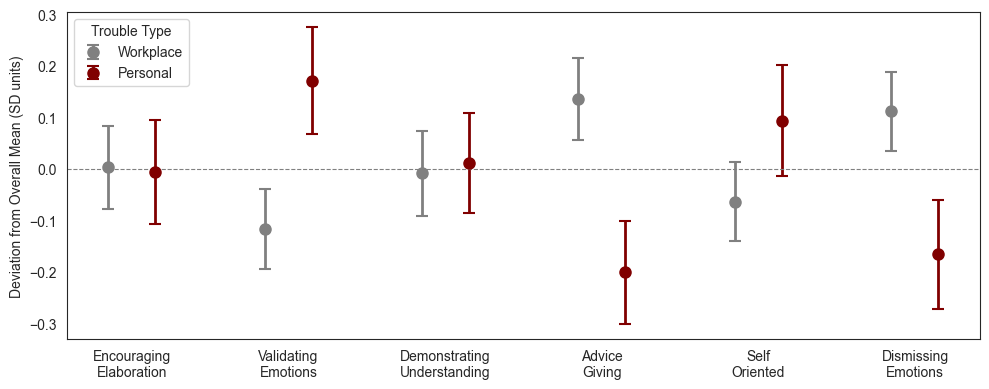

In [18]:
# Create visualization - single plot with scatter points
fig, ax = plt.subplots(figsize=(10, 4))

# Define colors - two shades of gray
colors = {'Workplace': 'gray', 'Personal': 'maroon'}

# X positions for each variable
x_positions = np.arange(len(communication_vars))

# Offset for the two groups to avoid overlap
offset = 0.15

for trouble_type, color in colors.items():
    type_data = summary_df[summary_df['Trouble_Type'] == trouble_type]
    
    # Determine x offset
    x_offset = -offset if trouble_type == 'Workplace' else offset
    
    ax.errorbar(
        x_positions + x_offset,
        type_data['Std_Mean'],
        yerr=type_data['Std_CI'],
        fmt='o',  # scatter points
        color=color,
        ecolor=color,  # error bar color matches point
        capsize=4,
        capthick=1.5,
        markersize=8,
        label=trouble_type,
        linewidth=2,
    )

# Customize the plot
wrapped_labels = [
    'Encouraging\nElaboration',
    'Validating\nEmotions',
    'Demonstrating\nUnderstanding',
    'Advice\nGiving',
    'Self\nOriented',
    'Dismissing\nEmotions',
]

ax.set_xticks(x_positions)
ax.set_xticklabels(wrapped_labels, rotation=0, ha='center')
ax.set_ylabel('Deviation from Overall Mean (SD units)')
ax.axhline(y=0, color='grey', linestyle='--', linewidth=0.8)
ax.legend(title='Trouble Type')

plt.tight_layout()
plt.savefig('figures/extended_data_figure_2.png', dpi=300, bbox_inches='tight')
plt.show()

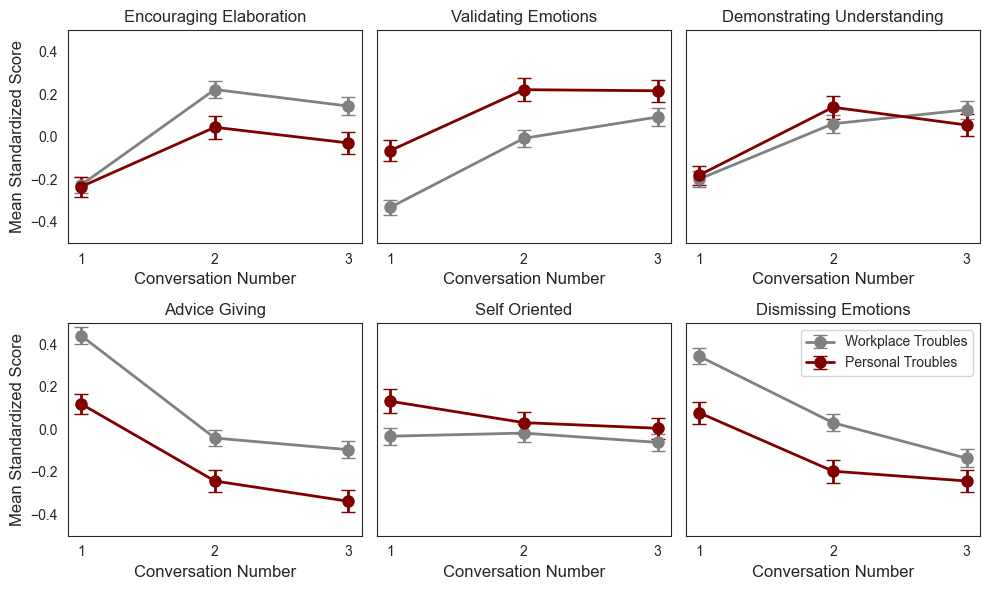

In [19]:
# Partition starter messages into workplace vs personal troubles
workplace_starters = [
  "So, I just lost my job today. I had a sense this was coming, but it's still a shock..",
  "I'm feeling so discouraged.. I just got passed over for the promotion I was working hard for",
  "I've been working so hard but I don't think anyone cares..",
]

personal_starters = [
  "I lost my dad last week.. I still can't believe he's really gone..",
  "I still can't believe it… my mom just got diagnosed with cancer. It feels like my whole world just flipped.",
]

# Create trouble_type column
df['trouble_type'] = df['starter'].apply(
  lambda x: 'Workplace' if x in workplace_starters else 'Personal'
)

# Define dimensions to analyze
dimensions = [
  'encouraging_elaboration',
  'validating_emotions',
  'demonstrating_understanding',
  'advice_giving',
  'self_oriented',
  'dismissing_emotions',
]

# Standardize each dimension across the entire dataset
for dim in dimensions:
    df[f'{dim}_standardized'] = (df[dim] - df[dim].mean()) / df[dim].std()

# Calculate standardized means and standard errors for each dimension by trouble type and conversation number
summary_data = []
for dim in dimensions:
  for trouble_type in ['Workplace', 'Personal']:
    for conv_num in [1, 2, 3]:
      subset = df[
        (df['trouble_type'] == trouble_type)
        & (df['conversation_number'] == conv_num)
      ][f'{dim}_standardized']
      summary_data.append(
        {
          'Dimension': dim,
          'Trouble_Type': trouble_type,
          'Conversation_Number': conv_num,
          'Mean': subset.mean(),
          'SE': subset.sem(),
          'N': len(subset),
        }
      )

summary_df = pd.DataFrame(summary_data)

# Create color palette
colors = {'Workplace': 'gray', 'Personal': 'maroon'}
# Create separate plots for each dimension, sharing y-axis label per row
fig, axes = plt.subplots(2, 3, figsize=(10, 6), sharey='row')
axes = axes.flatten()

for i, dim in enumerate(dimensions):
  ax = axes[i]

  # Plot data for each trouble type
  for trouble_type in ['Workplace', 'Personal']:
    dim_data = summary_df[
      (summary_df['Dimension'] == dim)
      & (summary_df['Trouble_Type'] == trouble_type)
    ]

    ax.errorbar(
      dim_data['Conversation_Number'],
      dim_data['Mean'],
      yerr=dim_data['SE'],
      label=f'{trouble_type} Troubles',
      color=colors[trouble_type],
      marker='o',
      markersize=8,
      linewidth=2,
      capsize=5,
    )

  # Customize plot
  ax.set_title(
    f'{dim.replace("_", " ").title()}', fontsize=12
  )
  ax.set_xlabel('Conversation Number', fontsize=12)
  # Only set y-axis label for the first column in each row (i.e., i==0 or i==3)
  if i % 3 == 0:
    ax.set_ylabel('Mean Standardized Score', fontsize=12)
  else:
      ax.set_ylabel('')
  ax.set_xticks([1, 2, 3])

  # Remove top and right spines
  # ax.spines['top'].set_visible(False)
  # ax.spines['right'].set_visible(False)
  ax.set_ylim(-.5, .5)

plt.tight_layout()

plt.legend()
plt.savefig('figures/extended_data_figure_3.png', dpi=300, bbox_inches='tight')
plt.show()

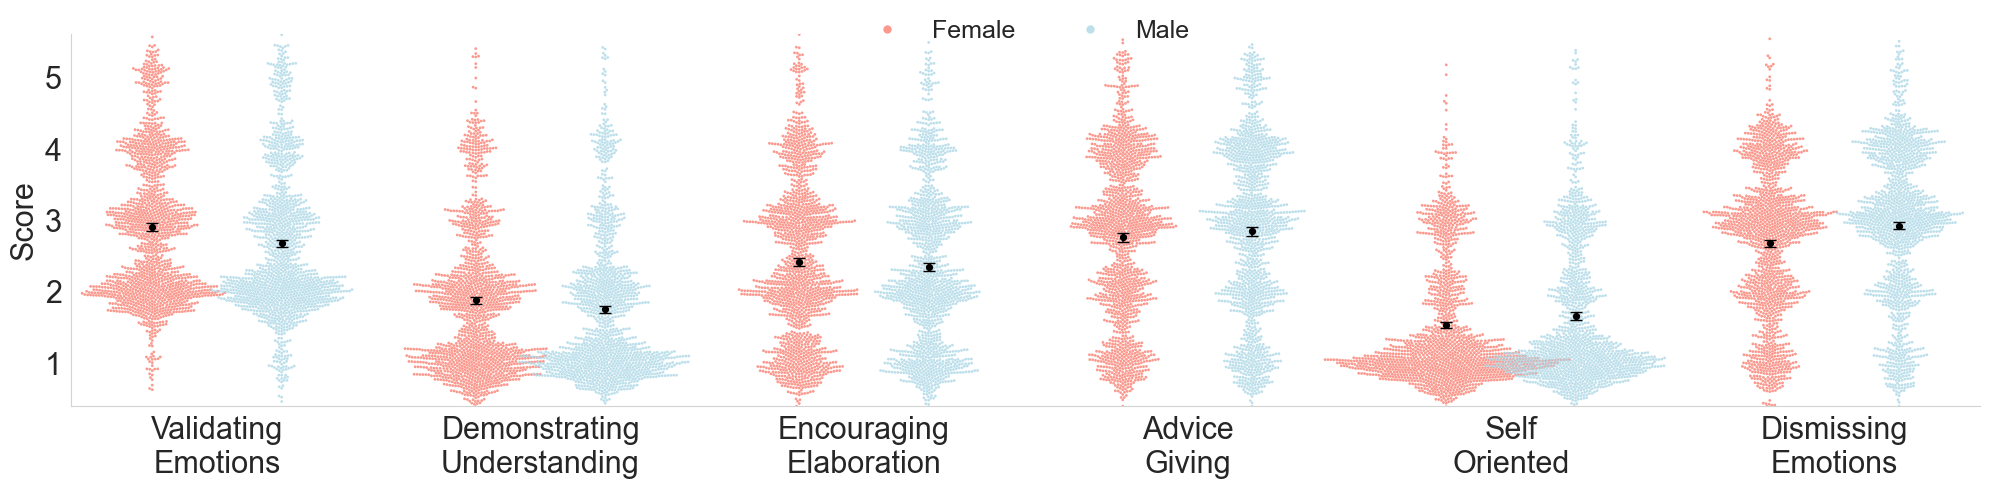

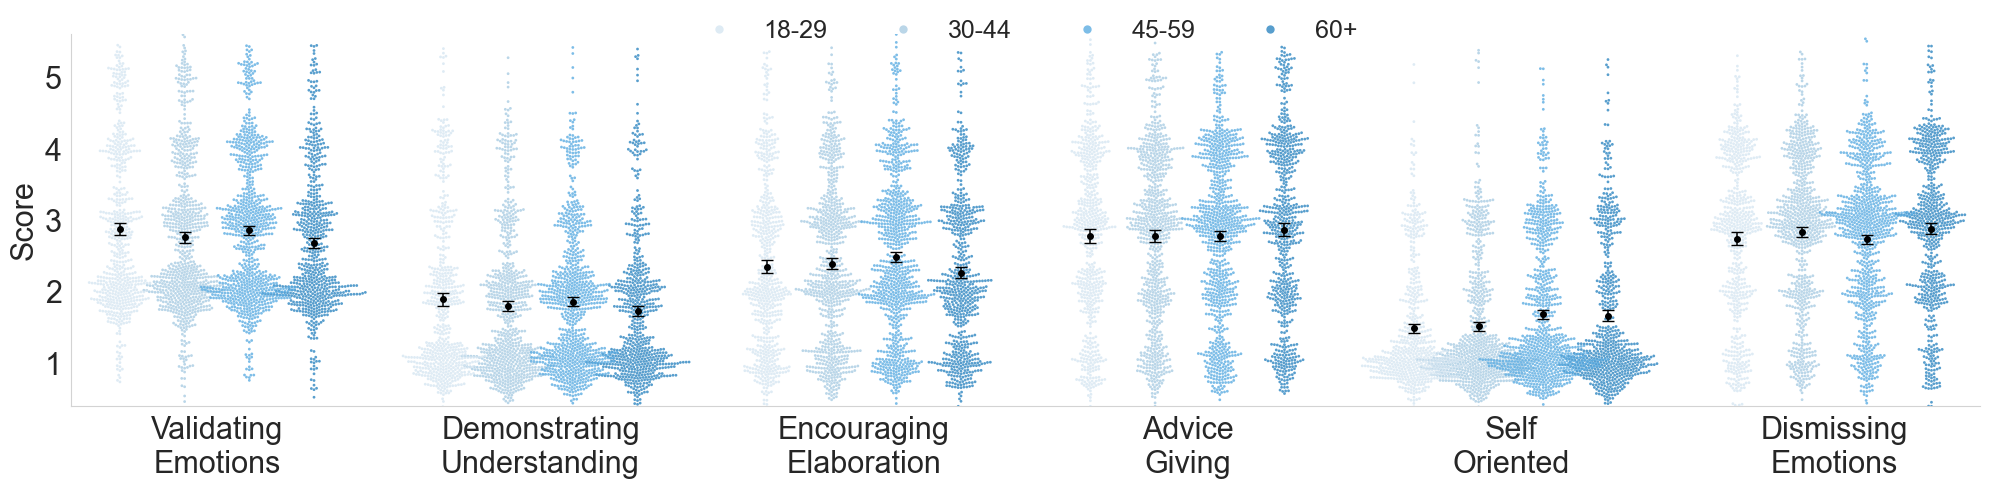

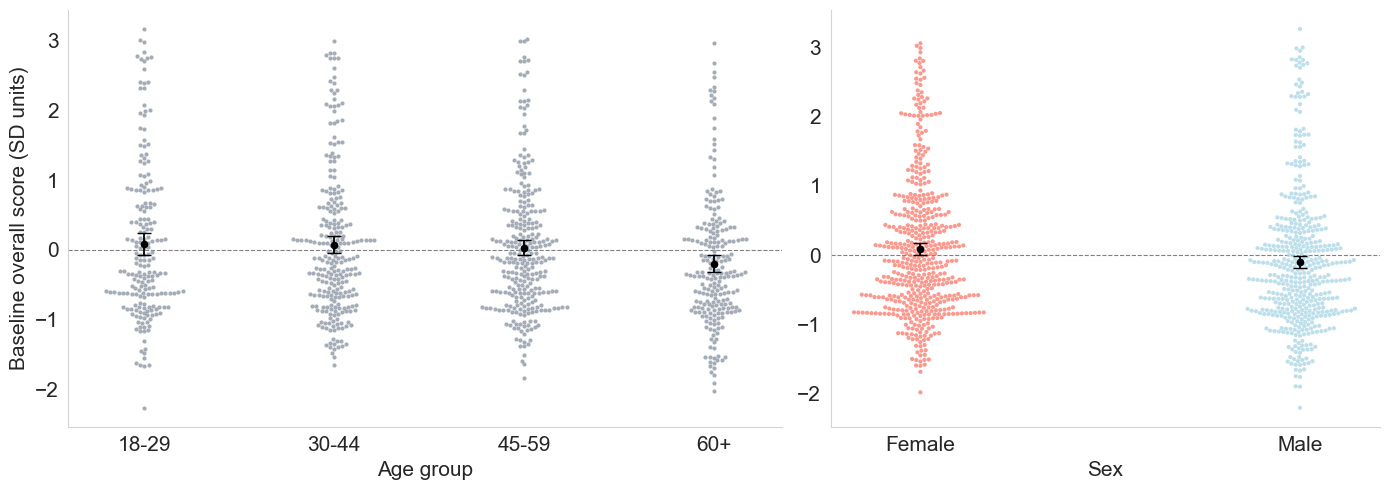

In [20]:
sns.set_style('white')
# -----------------------------------------------------------------------------
# SIfig1: Sex differences across six dimensions
# -----------------------------------------------------------------------------
plot_frames = []

vars_to_plot = [
    'validating_emotions',
    'demonstrating_understanding',
    'encouraging_elaboration',
    'advice_giving',
    'self_oriented',
    'dismissing_emotions'
]

for var in vars_to_plot:
    tmp = df[['Sex', var]].copy()
    tmp['Variable'] = var.replace('_', ' ').title()
    tmp = tmp.rename(columns={var: 'Value'})
    plot_frames.append(tmp)

plot_long = pd.concat(plot_frames, ignore_index=True)
plot_summary = (
    plot_long.groupby(['Variable', 'Sex'])['Value']
    .agg(mean='mean', se='sem')
    .reset_index()
)
plot_summary['ci95'] = 1.96 * plot_summary['se']

label_map = {
    'validating_emotions': 'Validating Emotions',
    'demonstrating_understanding': 'Demonstrating Understanding',
    'encouraging_elaboration': 'Encouraging Elaboration',           
    'advice_giving': 'Advice Giving',
    'self_oriented': 'Self Oriented',
    'dismissing_emotions': 'Dismissing Emotions'    
}

plot_long['Variable'] = plot_long['Variable'].replace({
    k.replace('_', ' ').title(): v for k, v in label_map.items()
})

var_order = [label_map[v] for v in vars_to_plot]
var_order_wrapped = [
    label.replace(' ', '\n', 1) if ' ' in label else label
    for label in var_order
]
sex_order = ['Female', 'Male']
palette = {'Female': 'salmon', 'Male': 'lightblue'}

plot_summary['Variable'] = plot_summary['Variable'].replace({
    k.replace('_', ' ').title(): v for k, v in label_map.items()
})
plot_summary['Variable'] = pd.Categorical(plot_summary['Variable'], categories=var_order, ordered=True)
plot_summary['Sex'] = pd.Categorical(plot_summary['Sex'], categories=sex_order, ordered=True)
plot_summary = plot_summary.sort_values(['Variable', 'Sex']).reset_index(drop=True)

fig, ax = plt.subplots(figsize=(20, 5))

plot_long_swarm = plot_long.dropna(subset=['Variable', 'Sex', 'Value']).copy()
rng = np.random.default_rng(42)
plot_long_swarm['y_jitter'] = plot_long_swarm['Value'] + rng.normal(0, 0.24, size=len(plot_long_swarm))

sns.swarmplot(
    data=plot_long_swarm,
    x='Variable',
    y='y_jitter',
    hue='Sex',
    order=var_order,
    hue_order=sex_order,
    palette=palette,
    dodge=True,
    size=2,
    alpha=0.80,
    ax=ax
)

sex_offsets = {
    sex: (idx - (len(sex_order) - 1) / 2) * (0.8 / len(sex_order))
    for idx, sex in enumerate(sex_order)
}

for i, var in enumerate(var_order):
    for sex in sex_order:
        row = plot_summary[(plot_summary['Variable'] == var) & (plot_summary['Sex'] == sex)]
        if not row.empty and pd.notna(row['mean'].iloc[0]):
            ax.errorbar(
                i + sex_offsets[sex],
                row['mean'].iloc[0],
                yerr=row['ci95'].iloc[0],
                fmt='o',
                color='black',
                markerfacecolor='black',
                markeredgecolor='black',
                markersize=4.2,
                capsize=4,
                elinewidth=1.1,
                zorder=10
            )

ax.set_xlabel('', fontsize=22)
ax.set_ylabel('Score', fontsize=22)
ax.set_ylim(0.4, 5.6)
ax.set_yticks([1, 2, 3, 4, 5])
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f'{int(y)}'))
for label in ax.get_yticklabels():
    label.set_fontsize(22)
ax.set_xticklabels(var_order_wrapped, rotation=0, ha='center', fontsize=22)
ax.margins(x=0.01)
ax.set_xlim(-0.45, len(var_order) - 0.55)
ax.legend(
    title='', frameon=False, fontsize=18, ncol=2,
    loc='upper center', bbox_to_anchor=(0.5, 1.1), markerscale=3
)

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['bottom'].set_color('lightgray')
ax.spines['left'].set_color('lightgray')

plt.tight_layout()
fig.savefig('figures/SIfig1.png', dpi=300, bbox_inches='tight')
plt.show()

# -----------------------------------------------------------------------------
# SIfig2: Age-bin differences across six dimensions
# -----------------------------------------------------------------------------
df['Age_numeric'] = pd.to_numeric(df['Age'], errors='coerce')
age_bin_edges = [17, 29, 44, 59, 120]
age_bin_labels = ['18-29', '30-44', '45-59', '60+']
df['Age_bin'] = pd.cut(
    df['Age_numeric'],
    bins=age_bin_edges,
    labels=age_bin_labels,
    include_lowest=True
)

age_plot_frames = []
for var in vars_to_plot:
    tmp = df[['Age_bin', var]].dropna().copy()
    tmp['Variable'] = label_map[var]
    tmp = tmp.rename(columns={var: 'Value'})
    age_plot_frames.append(tmp)

age_plot_long = pd.concat(age_plot_frames, ignore_index=True)
age_plot_summary = (
    age_plot_long.groupby(['Variable', 'Age_bin'])['Value']
    .agg(mean='mean', se='sem')
    .reset_index()
)
age_plot_summary['ci95'] = 1.96 * age_plot_summary['se']

age_order = age_bin_labels
age_palette = {
    '18-29': '#D6E6F2',
    '30-44': '#A9CCE3',
    '45-59': '#5DADE2',
    '60+': '#2E86C1'
}

age_plot_summary['Variable'] = pd.Categorical(age_plot_summary['Variable'], categories=var_order, ordered=True)
age_plot_summary['Age_bin'] = pd.Categorical(age_plot_summary['Age_bin'], categories=age_order, ordered=True)
age_plot_summary = age_plot_summary.sort_values(['Variable', 'Age_bin']).reset_index(drop=True)

fig, ax = plt.subplots(figsize=(20, 5))

age_plot_long_swarm = age_plot_long.dropna(subset=['Variable', 'Age_bin', 'Value']).copy()
rng = np.random.default_rng(42)
age_plot_long_swarm['y_jitter'] = age_plot_long_swarm['Value'] + rng.normal(0, 0.24, size=len(age_plot_long_swarm))

sns.swarmplot(
    data=age_plot_long_swarm,
    x='Variable',
    y='y_jitter',
    hue='Age_bin',
    order=var_order,
    hue_order=age_order,
    palette=age_palette,
    dodge=True,
    size=2.0,
    alpha=0.80,
    ax=ax
)

age_offsets = {
    age_bin: (idx - (len(age_order) - 1) / 2) * (0.8 / len(age_order))
    for idx, age_bin in enumerate(age_order)
}

for i, var in enumerate(var_order):
    for age_bin in age_order:
        row = age_plot_summary[(age_plot_summary['Variable'] == var) & (age_plot_summary['Age_bin'] == age_bin)]
        if not row.empty and pd.notna(row['mean'].iloc[0]):
            ax.errorbar(
                i + age_offsets[age_bin],
                row['mean'].iloc[0],
                yerr=row['ci95'].iloc[0],
                fmt='o',
                color='black',
                markerfacecolor='black',
                markeredgecolor='black',
                markersize=4.0,
                capsize=4,
                elinewidth=1.1,
                zorder=10
            )

ax.set_xlabel('', fontsize=22)
ax.set_ylabel('Score', fontsize=22)
ax.set_ylim(0.4, 5.6)
ax.set_yticks([1, 2, 3, 4, 5])
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f'{int(y)}'))
for label in ax.get_yticklabels():
    label.set_fontsize(22)
ax.set_xticklabels(var_order_wrapped, rotation=0, ha='center', fontsize=22)
ax.margins(x=0.01)
ax.set_xlim(-0.45, len(var_order) - 0.55)
ax.legend(
    title=None, frameon=False, fontsize=18, ncol=len(age_order),
    loc='upper center', bbox_to_anchor=(0.5, 1.1), markerscale=3
)

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['bottom'].set_color('lightgray')
ax.spines['left'].set_color('lightgray')

plt.tight_layout()
fig.savefig('figures/SIfig2.png', dpi=300, bbox_inches='tight')
plt.show()

# -----------------------------------------------------------------------------
# SIfig3: Baseline overall empathy by age-bin and sex (conversation 1)
# -----------------------------------------------------------------------------
if 'conversation_number' not in df.columns and 'conversation' in df.columns:
    df['conversation_number'] = df['conversation']

baseline_cols = [
    'user_id', 'conversation_number', 'Age_numeric', 'Sex',
    'validating_emotions', 'encouraging_elaboration', 'demonstrating_understanding',
    'advice_giving', 'self_oriented', 'dismissing_emotions'
]

baseline_df = df[baseline_cols].copy()
baseline_df = baseline_df[baseline_df['conversation_number'] == 1].drop_duplicates(subset=['user_id'])

baseline_df['baseline_overall_empathy'] = (
    baseline_df['validating_emotions']
    + baseline_df['encouraging_elaboration']
    + baseline_df['demonstrating_understanding']
    - baseline_df['advice_giving']
    - baseline_df['self_oriented']
    - baseline_df['dismissing_emotions']
)

baseline_df['baseline_overall_empathy_z'] = (
    baseline_df['baseline_overall_empathy'] - baseline_df['baseline_overall_empathy'].mean()
) / baseline_df['baseline_overall_empathy'].std()

analysis_df = baseline_df[['user_id', 'Age_numeric', 'Sex', 'baseline_overall_empathy_z']].dropna().copy()
analysis_df['Age_bin'] = pd.cut(
    analysis_df['Age_numeric'],
    bins=age_bin_edges,
    labels=age_bin_labels,
    include_lowest=True
)

fig, axes = plt.subplots(1, 2, figsize=(14, 5), gridspec_kw={'width_ratios': [1.3, 1]})

age_data = analysis_df.dropna(subset=['Age_bin', 'baseline_overall_empathy_z']).copy()
rng = np.random.default_rng(42)
age_data['y_jitter'] = age_data['baseline_overall_empathy_z'] + rng.normal(0, 0.06, size=len(age_data))

sns.swarmplot(
    data=age_data,
    x='Age_bin',
    y='y_jitter',
    order=age_bin_labels,
    color='#8E98A7',
    size=3,
    alpha=0.80,
    ax=axes[0]
)

age_summary = (
    age_data.groupby('Age_bin', observed=True)['baseline_overall_empathy_z']
    .agg(mean='mean', se='sem')
    .reindex(age_bin_labels)
)
age_summary['ci95'] = 1.96 * age_summary['se']

for i, grp in enumerate(age_bin_labels):
    if grp in age_summary.index and pd.notna(age_summary.loc[grp, 'mean']):
        axes[0].errorbar(
            i,
            age_summary.loc[grp, 'mean'],
            yerr=age_summary.loc[grp, 'ci95'],
            fmt='o',
            color='black',
            markerfacecolor='black',
            markeredgecolor='black',
            markersize=4.5,
            capsize=5,
            elinewidth=1.3,
            zorder=10
        )

axes[0].axhline(0, color='gray', linestyle='--', linewidth=0.8)
axes[0].set_xlabel('Age group', fontsize=15)
axes[0].set_ylabel('Baseline overall score (SD units)', fontsize=15)

sex_order_plot = ['Female', 'Male']
sex_palette = {'Female': 'salmon', 'Male': 'lightblue'}

sex_data = analysis_df.dropna(subset=['Sex', 'baseline_overall_empathy_z']).copy()
sex_data['y_jitter'] = sex_data['baseline_overall_empathy_z'] + rng.normal(0, 0.06, size=len(sex_data))

sns.swarmplot(
    data=sex_data,
    x='Sex',
    y='y_jitter',
    order=sex_order_plot,
    palette=sex_palette,
    size=3,
    alpha=0.80,
    ax=axes[1]
)

sex_summary = (
    sex_data.groupby('Sex')['baseline_overall_empathy_z']
    .agg(mean='mean', se='sem')
    .reindex(sex_order_plot)
)
sex_summary['ci95'] = 1.96 * sex_summary['se']

for i, sex in enumerate(sex_order_plot):
    if sex in sex_summary.index and pd.notna(sex_summary.loc[sex, 'mean']):
        axes[1].errorbar(
            i,
            sex_summary.loc[sex, 'mean'],
            yerr=sex_summary.loc[sex, 'ci95'],
            fmt='o',
            color='black',
            markerfacecolor='black',
            markeredgecolor='black',
            markersize=4.5,
            capsize=5,
            elinewidth=1.3,
            zorder=10
        )

axes[1].axhline(0, color='gray', linestyle='--', linewidth=0.8)
axes[1].set_xlabel('Sex', fontsize=15)
axes[1].set_ylabel('')

for ax in axes:
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.spines['bottom'].set_color('lightgray')
    ax.spines['left'].set_color('lightgray')
    ax.tick_params(axis='both', labelsize=15)

plt.tight_layout()
os.makedirs('figures', exist_ok=True)
fig.savefig('figures/SIfig3.png', dpi=300, bbox_inches='tight')
plt.show()


In [21]:
# Load data
data = data[['user_id', 'conversation_id','self_demonstrate_desire', 'self_showed_understanding',
       'self_encourage_elaboration', 'self_empathized', 'validating_emotions',
       'encouraging_elaboration', 'demonstrating_understanding',
       'advice_giving', 'self_oriented', 'dismissing_emotions',
       'conversation_number', 'condition']]

# Standardize condition names
data['condition'] = data['condition'].replace(
    {
        'Control': 'Control',
        'Influencer': 'Didactic Video',
        'AICoach': 'LLM Coach',
        'CoachPlusInfluencer': 'Combo',
    }
)

# Define the Likert scale mapping for axis labels
likert_labels = [
    "Not \n at all", "A little", "Somewhat", "Quite \na bit", "Very\n much"
]

# map all the columns to the likert scale
data = data.replace({
    'self_demonstrate_desire': likert_labels,
    'self_showed_understanding': likert_labels,
    'self_encourage_elaboration': likert_labels,
    'self_empathized': likert_labels,
    'demonstrating_understanding': likert_labels,
    'validating_emotions': likert_labels,
    'encouraging_elaboration': likert_labels,
    'dismissing_emotions': likert_labels,
    'advice_giving': likert_labels,
    'self_oriented': likert_labels,
})

data['overall_empathy_score'] = (
    data['demonstrating_understanding'] +
    data['validating_emotions'] +
    data['encouraging_elaboration'] -
    data['dismissing_emotions'] -
    data['advice_giving'] -
    data['self_oriented']
)
score_bins = pd.qcut(data['overall_empathy_score'], 5, labels=likert_labels)
self_empathized_bins = data['self_empathized']


In [22]:
baseline_source_cols = [
    'baseline_empathy_item_1', 'baseline_empathy_item_2', 'baseline_empathy_item_3', 'baseline_empathy_item_4',
    'baseline_empathy_item_5', 'baseline_empathy_item_6', 'baseline_empathy_item_7', 'baseline_empathy_item_8'
]

baseline = (
    experiment_1_data[['user_id'] + baseline_source_cols]
    .drop_duplicates(subset=['user_id'])
    .rename(columns={col: col.replace('baseline_', '') for col in baseline_source_cols})
)

# Map text responses to numeric values
response_mapping = {
    'not_at_all': 1,
    'slightly': 2, 
    'somewhat': 3,
    'quite_a_bit': 4,
    'very_much': 5
}


empathy_item_cols = [f'empathy_item_{i}' for i in range(1, 9)]

if all(col in baseline.columns for col in empathy_item_cols):
    baseline_cols = empathy_item_cols
else:
    raise KeyError(
        "Expected baseline item columns not found. Available columns include: "
        f"{sorted([c for c in baseline.columns if c != 'user_id'])}"
    )

# Convert baseline responses to numeric
for col in baseline_cols:
    baseline[col] = baseline[col].map(response_mapping).fillna(baseline[col])
    baseline[col] = pd.to_numeric(baseline[col], errors='coerce')

# Jordan empathy = sum of first 7 baseline items; SITES = item 8
jordan_cols = baseline_cols[:7]
sites_col = baseline_cols[7]
baseline['jordan_empathy'] = baseline[jordan_cols].sum(axis=1)
baseline['baseline8'] = baseline[sites_col]

# Calculate LLM-evaluated overall empathy score
data['overall_empathy_score'] = (
    data['validating_emotions'] + 
    data['encouraging_elaboration'] + 
    data['demonstrating_understanding'] - 
    data['advice_giving'] - 
    data['self_oriented'] - 
    data['dismissing_emotions']
)

# Aggregate to user level
user_empathy = data.groupby('user_id').agg({
    'overall_empathy_score': 'mean',
    'self_empathized': 'mean',
    'self_encourage_elaboration': 'mean',
    'self_showed_understanding': 'mean',
    'encouraging_elaboration': 'mean',
    'demonstrating_understanding': 'mean',
    'validating_emotions': 'mean'
}).reset_index()

# Merge with baseline data
merged = baseline[['user_id', 'jordan_empathy', 'baseline8']].merge(
    user_empathy, on='user_id', how='inner'
).dropna()

print("=" * 70)
print("SAMPLE SIZE")
print("=" * 70)
print(f"N participants: {len(merged)}")
print(f"N conversations: {len(data)}")
print(f"Conversations per participant: {len(data) / len(merged):.1f}")

print("\n" + "=" * 70)
print("R² VALUES: TRAIT EMPATHY vs LLM-EVALUATED BEHAVIOR")
print("=" * 70)

# Jordan Empathy vs Overall Empathy Score
r_jordan, p_jordan = stats.pearsonr(merged['jordan_empathy'], merged['overall_empathy_score'])
r2_jordan = r_jordan ** 2
print(f"\nJordan Empathy → Overall Empathy Score:")
print(f"  r = {r_jordan:.3f}, R² = {r2_jordan:.3f}, p = {p_jordan:.4f}")

# SITES vs Overall Empathy Score
r_sites, p_sites = stats.pearsonr(merged['baseline8'], merged['overall_empathy_score'])
r2_sites = r_sites ** 2
print(f"\nSITES → Overall Empathy Score:")
print(f"  r = {r_sites:.3f}, R² = {r2_sites:.3f}, p = {p_sites:.4f}")

print("\n" + "=" * 70)
print("R² VALUES: SELF-REPORT vs LLM-EVALUATED (SAME DIMENSION)")
print("=" * 70)

# Self-empathized vs Overall Empathy
r_self_emp, p_self_emp = stats.pearsonr(merged['self_empathized'], merged['overall_empathy_score'])
r2_self_emp = r_self_emp ** 2
print(f"\nSelf-Reported Empathized → Overall Empathy Score:")
print(f"  r = {r_self_emp:.3f}, R² = {r2_self_emp:.3f}, p = {p_self_emp:.4f}")

# Self-encourage vs LLM encouraging elaboration
r_enc, p_enc = stats.pearsonr(merged['self_encourage_elaboration'], merged['encouraging_elaboration'])
r2_enc = r_enc ** 2
print(f"\nSelf-Reported Encouraged → LLM Encouraging Elaboration:")
print(f"  r = {r_enc:.3f}, R² = {r2_enc:.3f}, p = {p_enc:.4f}")

# Self-understanding vs LLM demonstrating understanding
r_und, p_und = stats.pearsonr(merged['self_showed_understanding'], merged['demonstrating_understanding'])
r2_und = r_und ** 2
print(f"\nSelf-Reported Understanding → LLM Demonstrating Understanding:")
print(f"  r = {r_und:.3f}, R² = {r2_und:.3f}, p = {p_und:.4f}")

print("\n" + "=" * 70)
print("SELF-REPORT DISTRIBUTION (at conversation level)")
print("=" * 70)

# Distribution of self_empathized
self_emp_counts = data['self_empathized'].value_counts().sort_index()
self_emp_pct = (self_emp_counts / len(data) * 100)

print("\nSelf-Reported Empathized distribution:")
labels = {1: 'Not at all', 2: 'A little', 3: 'Somewhat', 4: 'Quite a bit', 5: 'Very much'}
for val in sorted(self_emp_counts.index):
    print(f"  {labels.get(val, val)}: {self_emp_counts[val]:,} ({self_emp_pct[val]:.1f}%)")

# High vs Low self-reports
high_self = (data['self_empathized'] >= 4).sum()
low_self = (data['self_empathized'] <= 2).sum()
pct_high = high_self / len(data) * 100
pct_low = low_self / len(data) * 100

print(f"\n% rating 'Quite a bit' or 'Very much': {pct_high:.1f}%")
print(f"% rating 'Not at all' or 'A little': {pct_low:.1f}%")

print("\n" + "=" * 70)
print("OVERALL EMPATHY SCORE DISTRIBUTION")
print("=" * 70)
print(f"\nMean: {data['overall_empathy_score'].mean():.2f}")
print(f"SD: {data['overall_empathy_score'].std():.2f}")
print(f"Range: {data['overall_empathy_score'].min():.0f} to {data['overall_empathy_score'].max():.0f}")
print(f"Median: {data['overall_empathy_score'].median():.2f}")



SAMPLE SIZE
N participants: 968
N conversations: 2904
Conversations per participant: 3.0

R² VALUES: TRAIT EMPATHY vs LLM-EVALUATED BEHAVIOR

Jordan Empathy → Overall Empathy Score:
  r = 0.035, R² = 0.001, p = 0.2740

SITES → Overall Empathy Score:
  r = 0.061, R² = 0.004, p = 0.0594

R² VALUES: SELF-REPORT vs LLM-EVALUATED (SAME DIMENSION)

Self-Reported Empathized → Overall Empathy Score:
  r = 0.049, R² = 0.002, p = 0.1250

Self-Reported Encouraged → LLM Encouraging Elaboration:
  r = 0.077, R² = 0.006, p = 0.0162

Self-Reported Understanding → LLM Demonstrating Understanding:
  r = 0.016, R² = 0.000, p = 0.6180

SELF-REPORT DISTRIBUTION (at conversation level)

Self-Reported Empathized distribution:
  Not at all: 12 (0.4%)
  A little: 61 (2.1%)
  Somewhat: 275 (9.5%)
  Quite a bit: 1,003 (34.5%)
  Very much: 1,553 (53.5%)

% rating 'Quite a bit' or 'Very much': 88.0%
% rating 'Not at all' or 'A little': 2.5%

OVERALL EMPATHY SCORE DISTRIBUTION

Mean: -0.19
SD: 4.50
Range: -11 to 1

In [24]:
# -----------------------------------------------------------------------------
# Demographic correlates analysis reported in SI text
# -----------------------------------------------------------------------------

analysis_cols = [
    'user_id', 'conversation_number', 'condition', 'Age', 'Sex',
    'validating_emotions', 'encouraging_elaboration', 'demonstrating_understanding',
    'advice_giving', 'self_oriented', 'dismissing_emotions'
]

tmp = df[analysis_cols].copy()
tmp['Age_numeric'] = pd.to_numeric(tmp['Age'], errors='coerce')

condition_map = {
    'AICoach': 'AI Coach',
    'CoachPlusInfluencer': 'Combined',
    'Influencer': 'Video',
    'Control': 'Control'
}
tmp['condition'] = tmp['condition'].replace(condition_map)

positive = ['validating_emotions', 'encouraging_elaboration', 'demonstrating_understanding']
negative = ['advice_giving', 'self_oriented', 'dismissing_emotions']
tmp['overall_empathy'] = tmp[positive].sum(axis=1) - tmp[negative].sum(axis=1)

baseline = (
    tmp[tmp['conversation_number'] == 1]
    .sort_values(['user_id'])
    .drop_duplicates(subset=['user_id'])
    [['user_id', 'Sex', 'Age_numeric', 'condition', 'overall_empathy']]
    .rename(columns={'overall_empathy': 'baseline_empathy'})
)

post = (
    tmp[tmp['conversation_number'].isin([2, 3])]
    .groupby('user_id', as_index=False)['overall_empathy']
    .mean()
    .rename(columns={'overall_empathy': 'post_empathy'})
)

person = baseline.merge(post, on='user_id', how='inner')
person['improvement'] = person['post_empathy'] - person['baseline_empathy']

person['baseline_empathy_sd'] = (
    person['baseline_empathy'] - person['baseline_empathy'].mean()
) / person['baseline_empathy'].std()
person['improvement_sd'] = (
    person['improvement'] - person['improvement'].mean()
) / person['improvement'].std()

model_df = person.dropna(
    subset=['Sex', 'Age_numeric', 'condition', 'baseline_empathy_sd', 'improvement_sd']
).copy()

m_baseline = smf.ols(
    "baseline_empathy_sd ~ C(Sex, Treatment(reference='Male')) + Age_numeric",
    data=model_df
).fit(cov_type='HC3')

m_change = smf.ols(
    "improvement_sd ~ baseline_empathy_sd + C(Sex, Treatment(reference='Male')) + Age_numeric "
    "+ C(condition, Treatment(reference='Control')) "
    "+ C(condition, Treatment(reference='Control')):C(Sex, Treatment(reference='Male')) "
    "+ C(condition, Treatment(reference='Control')):Age_numeric",
    data=model_df
).fit(cov_type='HC3')

stargazer_baseline = Stargazer([m_baseline])
stargazer_baseline.title('SI Regressions: Baseline Empathy (SD)')
display(HTML(stargazer_baseline.render_html()))

stargazer_change = Stargazer([m_change])
stargazer_change.title('SI Regressions: Improvement (SD)')
display(HTML(stargazer_change.render_html()))

In [ ]:
# -----------------------------------------------------------------------------
# Templatic response analysis
# -----------------------------------------------------------------------------

ROOT = Path.cwd()
DATA = ROOT / 'data'
OUT = ROOT / 'analysis_outputs'
TEMPLATIC_OUT = OUT / 'templaticity'
FIG_DIR = ROOT / 'figures'
TEMPLATIC_OUT.mkdir(parents=True, exist_ok=True)
(TEMPLATIC_OUT / 'figures').mkdir(parents=True, exist_ok=True)
FIG_DIR.mkdir(exist_ok=True)

# Set True to re-run phrase-span tagging even when cached outputs exist.
REGENERATE_TEMPLATIC_OUTPUTS = False
# Optional smoke test: annotate only the first N conversations.
TEMPLATIC_TAG_LIMIT = None

CONDITION_LABELS = {
    'Control': 'Control',
    'Influencer': 'Video',
    'AICoach': 'AI Coach',
    'CoachPlusInfluencer': 'Combined',
}

metrics_path = TEMPLATIC_OUT / 'conversation_templaticity_novelty_metrics.csv'
summary_path = TEMPLATIC_OUT / 'template_coverage_summary.csv'
span_path = TEMPLATIC_OUT / 'templatic_span_annotations.csv'

TACTICS = {
    'X': 'Emotional Expression',
    'E': 'Empowerment',
    'V': 'Validation',
    'I': 'Information',
    'P': 'Paraphrasing',
    'R': 'Reappraisal',
    'S': 'Self-Disclosure',
    'A': 'Advice',
    'H': 'Assistance',
    'Q': 'Questioning',
}
TACTIC_ORDER = ['X', 'P', 'V', 'Q', 'S', 'H', 'E', 'R', 'I', 'A']

LEVEL1_TO_TACTIC = {
    'Expressing Sympathy': ['X'],
    'Validating Emotions': ['V'],
    'Validating emotions': ['V'],
    'Demonstrating Understanding': ['P'],
    'Encouraging Elaboration': ['Q'],
    'Advice-giving': ['A'],
    'Advice-Giving': ['A'],
    'Affirming': ['E'],
    'Demonstrating Availability': ['H'],
    'Self-oriented': ['S'],
    'Providing Reassurance': ['R'],
}
LEVEL2_TO_TACTIC = {
    'Apologetic Language': ['X'],
    'Emotional Exclamation': ['X'],
    'Naming Emotions': ['V'],
    'Validating Emotional Experience': ['V'],
    'Normalizing Experience': ['V'],
    'Normalization': ['V'],
    'Expressing Comprehension': ['P'],
    'Acknowledging Perspective': ['P'],
    'Promoting Dialogue': ['Q'],
    'Sharing Personal Experience': ['S'],
    'Providing Support': ['H'],
    'Offer help': ['H'],
    'Promoting Self-Worth': ['E'],
    'Positive Reinforcement': ['E'],
    'Promoting Resilience': ['E', 'R'],
    'Future-Oriented': ['R'],
    'Meaning-Making': ['R'],
    'Providing Additional Perspective': ['R', 'I'],
    'Providing additional perspective': ['R', 'I'],
    'Problem-Solving Guidance': ['A'],
    'Promoting Support Seeking': ['A', 'I'],
    'Promoting Emotional Processing': ['A'],
    'Promoting Self-Reflection': ['A', 'Q'],
    'Promoting Emotional Expression': ['Q'],
}

PAPER_PATTERNS = {
    'pattern_1': r'^X?[PV]+[XE]?[AIP]+',
    'pattern_2': r'^X?[PV]+[XE]?[AIP]+[VXER]+',
    'pattern_3': r'^X?[PV]+[XE]?[AIP]+[VXER]+[AIP]+',
    'pattern_4': r'^X?[PV]+[XE]?[AIP]+[VXER]+[AIP]+[VXER]+',
    'pattern_5': r'^X?[PV]+[XE]?[AIP]+[VXER]+[AIP]+[VXER]+[AIP]+',
}

@dataclass(frozen=True)
class PatternRule:
    code: str
    name: str
    pattern: re.Pattern[str]

def compile_rule(code: str, name: str, pattern: str) -> PatternRule:
    return PatternRule(code=code, name=name, pattern=re.compile(pattern, re.I))

RULES = [
    compile_rule('X', 'apology_or_emotional_reaction', r"\b(i'?m|i am|so)?\s*(sorry|saddened|heartbroken|devastated)\b|\bthat'?s (awful|terrible|heartbreaking|devastating|sad)\b|\bwow\b|❤️|<3"),
    compile_rule('P', 'reflects_or_paraphrases_experience', r"\b(it sounds like|sounds like|it seems like|seems like|i hear|i'?m hearing|what i'?m hearing|you(?:'re| are) feeling|you feel|you felt|you seem|you mentioned|you said|from what you(?:'ve| have) shared|that must feel)\b"),
    compile_rule('V', 'validates_or_normalizes_feelings', r"\b(makes sense|understandable|valid|normal|natural|okay to feel|ok to feel|anyone would|you'?re not overreacting|not overreacting|your feelings are|it'?s okay|it is okay|it'?s ok|that'?s completely understandable|you have every right|of course you)\b"),
    compile_rule('Q', 'asks_question', r"\?|^\s*(how|what|why|when|where|who|which|can you|could you|would you|do you|did you|have you|are you|is there|tell me more)\b"),
    compile_rule('S', 'self_discloses_or_self_orients', r"\b(i can relate|i relate|me too|same here|i'?ve been|i have been|when i|my\b.*\b(experience|mom|dad|friend|partner|job|boss|family)|i went through|i experienced|happened to me|in my life)\b"),
    compile_rule('H', 'offers_availability_or_assistance', r"\b(i'?m here for you|i am here for you|here to listen|here if you|if you want to talk|if you need to talk|can i help|anything i can do|how can i help|reach out|lean on me)\b"),
    compile_rule('E', 'empowers_or_affirms_person', r"\b(you can|you'?ve got this|you got this|you are (?:very |really |so |much |very much )?capable|you'?re (?:very |really |so |much |very much )?capable|you are (?:very |really |so )?strong|you'?re (?:very |really |so )?strong|you are (?:very |really |so )?brave|you'?re (?:very |really |so )?brave|proud of you|you deserve|you matter|you are enough|believe in you|you'?re doing (great|your best|so well)|good job)\b"),
    compile_rule('R', 'reframes_or_reappraises', r"\b(not your fault|out of your control|doesn'?t define you|does not define you|another way to look|reframe|perspective|try to remember|remember that|this doesn'?t mean|this does not mean|one step at a time|take it one day at a time|it can also mean|instead of|rather than|be kind to yourself|grace with yourself)\b"),
    compile_rule('I', 'provides_facts_or_resources', r"\b(research shows|studies show|statistics|statistically|resource|resources|hotline|therapist|therapy|counselor|doctor|professional help|support group|hr\b|human resources|policy|legal|website|link|phone number|number to call)\b"),
    compile_rule('A', 'gives_advice_or_solution', r"\b(you should|you need to|you have to|you must|try to|try\b|consider|i suggest|i recommend|my advice|it might help to|it may help to|make sure|focus on|talk to|speak to|ask for|write down|take care of|keep\b|start\b|stop\b|don'?t\b|do not\b|let yourself|maybe you can|you could|you can always)\b"),
]

def normalize_text(text: object) -> str:
    if not isinstance(text, str):
        return ''
    return re.sub(r'\s+', ' ', text).strip()

def pattern_matched(seq: object, pattern: str) -> bool:
    if not isinstance(seq, str) or not seq:
        return False
    return re.match(pattern, seq) is not None

def parse_supporter_turns(conversation: str) -> list[dict[str, object]]:
    turns = []
    current_role = None
    current_lines: list[str] = []
    message_idx = 0

    def flush() -> None:
        nonlocal message_idx, current_lines, current_role
        if current_role is None:
            return
        text = normalize_text('\n'.join(current_lines))
        if text:
            message_idx += 1
            if current_role == 'Supporter':
                turns.append({
                    'supporter_turn_index': len(turns) + 1,
                    'message_index': message_idx,
                    'turn_number': message_idx,
                    'supporter_turn_text': text,
                })
        current_lines = []

    for raw_line in str(conversation).splitlines():
        line = raw_line.strip()
        if not line:
            continue
        if line.startswith('Seeker:'):
            flush()
            current_role = 'Seeker'
            current_lines = [line.removeprefix('Seeker:').strip()]
        elif line.startswith('Supporter:'):
            flush()
            current_role = 'Supporter'
            current_lines = [line.removeprefix('Supporter:').strip()]
        else:
            current_lines.append(line)
    flush()
    return turns

def split_phrase_spans(text: str) -> list[str]:
    text = normalize_text(text)
    if not text:
        return []
    sentence_parts = re.split(r'(?<=[.!?])\s+|\n+', text)
    spans = []
    for sentence in sentence_parts:
        sentence = sentence.strip()
        if not sentence:
            continue
        clauses = re.split(r'\s+(?:but|and|because|while|though|although|however)\s+|[;:]', sentence, flags=re.I)
        for clause in clauses:
            clause = clause.strip(' ,')
            if clause:
                spans.append(clause)
    return spans

def rules_for_span(text: str) -> set[str]:
    labels = {rule.code for rule in RULES if rule.pattern.search(text)}
    if 'Q' in labels and re.match(r'^\s*(tell me more|can you|could you|would you|how|what|why)', text, re.I):
        labels.discard('A')
    return labels

def build_theme_lookup(themes: pd.DataFrame) -> dict[tuple[str, int, int], list[dict[str, object]]]:
    relevant = themes.copy()
    relevant['theme_text_norm'] = relevant['text'].map(normalize_text)
    relevant = relevant[relevant['theme_text_norm'] != '']
    lookup: dict[tuple[str, int, int], list[dict[str, object]]] = {}
    for _, row in relevant.iterrows():
        key = (str(row['user_id']), int(row['conversation_number']), int(row['turn_number']))
        lookup.setdefault(key, []).append(row.to_dict())
    return lookup

def theme_labels_for_span(span_text, user_id, conversation_number, turn_number, theme_lookup):
    labels: set[str] = set()
    sources: list[str] = []
    span_norm = normalize_text(span_text).lower()
    key = (str(user_id), int(conversation_number), int(turn_number))
    for theme in theme_lookup.get(key, []):
        theme_text = str(theme.get('theme_text_norm', '')).lower()
        if not theme_text:
            continue
        near_exact_span = span_norm in theme_text and len(span_norm) / max(len(theme_text), 1) >= 0.75
        theme_phrase_inside_span = theme_text in span_norm
        if near_exact_span or theme_phrase_inside_span:
            for code in LEVEL1_TO_TACTIC.get(str(theme.get('Level 1')), []):
                labels.add(code)
                sources.append(f"theme_level1:{theme.get('Level 1')}")
            for code in LEVEL2_TO_TACTIC.get(str(theme.get('Level 2')), []):
                labels.add(code)
                sources.append(f"theme_level2:{theme.get('Level 2')}")
    return labels, sorted(set(sources))

def collapse_consecutive(sequence: list[str]) -> str:
    collapsed: list[str] = []
    for code in sequence:
        if not collapsed or collapsed[-1] != code:
            collapsed.append(code)
    return ''.join(collapsed)

def build_sequences(conversation: pd.DataFrame, labels: pd.DataFrame) -> pd.DataFrame:
    rows = []
    for _, conv in conversation.iterrows():
        sub = labels[labels['conversation_id'] == conv['conversation_id']].sort_values(
            ['supporter_turn_index', 'span_index', 'tactic_order_within_span']
        )
        seq = sub['tactic_code'].tolist()
        collapsed = collapse_consecutive(seq)
        rows.append({
            'user_id': conv['user_id'],
            'conversation_id': conv['conversation_id'],
            'conversation_number': conv['conversation_number'],
            'condition': conv['condition'],
            'starter': conv['starter'],
            'raw_tactic_sequence': ''.join(seq),
            'tactic_sequence': collapsed,
        })
    return pd.DataFrame(rows)

def annotate_conversations(conversation: pd.DataFrame, themes: pd.DataFrame):
    theme_lookup = build_theme_lookup(themes)
    span_rows, label_rows = [], []
    for _, conv in conversation.iterrows():
        turns = parse_supporter_turns(str(conv['conversation']))
        for turn in turns:
            spans = split_phrase_spans(str(turn['supporter_turn_text']))
            for span_index, span_text in enumerate(spans, start=1):
                rule_labels = rules_for_span(span_text)
                theme_labels, theme_sources = theme_labels_for_span(
                    span_text, conv['user_id'], conv['conversation_number'], turn['turn_number'], theme_lookup
                )
                labels = sorted(rule_labels | theme_labels, key=TACTIC_ORDER.index)
                source_bits = []
                if rule_labels:
                    source_bits.append('rules')
                source_bits.extend(theme_sources)
                span_id = f"{conv['conversation_id']}_t{turn['supporter_turn_index']:02d}_s{span_index:02d}"
                span_rows.append({
                    'span_id': span_id,
                    'user_id': conv['user_id'],
                    'conversation_id': conv['conversation_id'],
                    'conversation_number': conv['conversation_number'],
                    'condition': conv['condition'],
                    'starter': conv['starter'],
                    'supporter_turn_index': turn['supporter_turn_index'],
                    'message_index': turn['message_index'],
                    'turn_number': turn['turn_number'],
                    'span_index': span_index,
                    'span_text': span_text,
                    'tactic_codes': '|'.join(labels),
                    'tactic_names': '|'.join(TACTICS[code] for code in labels),
                    'annotation_sources': '|'.join(sorted(set(source_bits))),
                })
                for tactic_order, code in enumerate(labels, start=1):
                    label_rows.append({
                        'span_id': span_id,
                        'user_id': conv['user_id'],
                        'conversation_id': conv['conversation_id'],
                        'conversation_number': conv['conversation_number'],
                        'condition': conv['condition'],
                        'supporter_turn_index': turn['supporter_turn_index'],
                        'message_index': turn['message_index'],
                        'turn_number': turn['turn_number'],
                        'span_index': span_index,
                        'tactic_order_within_span': tactic_order,
                        'tactic_code': code,
                        'tactic_name': TACTICS[code],
                        'span_text': span_text,
                        'annotation_sources': '|'.join(sorted(set(source_bits))),
                    })
    return pd.DataFrame(span_rows), pd.DataFrame(label_rows)

def build_conversation_table(experiment_1: pd.DataFrame) -> pd.DataFrame:
    convo_cols = [
        'user_id', 'conversation_id', 'conversation',
        'conversation_number', 'starter', 'condition',
    ]
    convo = experiment_1[convo_cols].drop_duplicates('conversation_id').copy()
    convo['condition_label'] = convo['condition'].map(CONDITION_LABELS)
    return convo

def summarize_pattern_rates(df: pd.DataFrame) -> pd.DataFrame:
    rows = []
    for (condition, round_num), sub in df.groupby(['condition', 'conversation_number']):
        row = {
            'condition': condition,
            'condition_label': CONDITION_LABELS[condition],
            'conversation_number': round_num,
            'n': len(sub),
        }
        for name in PAPER_PATTERNS:
            row[name] = sub[f'{name}_matched'].mean()
        rows.append(row)
    return pd.DataFrame(rows).sort_values(['condition', 'conversation_number'])

def run_templatic_tagging_pipeline() -> pd.DataFrame:
    experiment_1 = pd.read_csv(DATA / 'experiment_1.csv')
    themes = pd.read_csv(DATA / 'all_themes.csv')
    conversation = build_conversation_table(experiment_1)
    if TEMPLATIC_TAG_LIMIT is not None:
        conversation = conversation.head(TEMPLATIC_TAG_LIMIT).copy()

    print(f'Annotating {len(conversation):,} conversations with phrase-span templatic tactics...')
    spans, labels = annotate_conversations(conversation, themes)
    sequences = build_sequences(conversation, labels)

    spans.to_csv(span_path, index=False)
    labels.to_csv(TEMPLATIC_OUT / 'templatic_span_labels_long.csv', index=False)
    sequences.to_csv(TEMPLATIC_OUT / 'templatic_conversation_sequences.csv', index=False)

    merged = conversation.merge(
        sequences[['conversation_id', 'tactic_sequence']],
        on='conversation_id',
        how='left',
    )
    merged['tactic_sequence'] = merged['tactic_sequence'].fillna('')

    for name, pattern in PAPER_PATTERNS.items():
        merged[f'{name}_matched'] = merged['tactic_sequence'].apply(lambda s, p=pattern: pattern_matched(s, p))

    metrics_cols = [
        'user_id', 'conversation_id', 'conversation_number', 'condition', 'condition_label',
        'tactic_sequence',
        *[f'{name}_matched' for name in PAPER_PATTERNS],
    ]
    metrics = merged[metrics_cols].copy()
    metrics.to_csv(metrics_path, index=False)

    template_summary = summarize_pattern_rates(metrics)
    template_summary.to_csv(summary_path, index=False)

    print(f'Wrote {len(spans):,} phrase spans to {span_path}')
    print(f'Wrote conversation metrics to {metrics_path}')
    return metrics

if REGENERATE_TEMPLATIC_OUTPUTS or not metrics_path.exists():
    templatic = run_templatic_tagging_pipeline()
else:
    print(f'Loading cached templatic metrics from {metrics_path}')
    print('Set REGENERATE_TEMPLATIC_OUTPUTS=True to re-run phrase-span tagging.')
    templatic = pd.read_csv(metrics_path)

if summary_path.exists():
    template_summary = pd.read_csv(summary_path)
else:
    template_summary = summarize_pattern_rates(templatic)
    template_summary.to_csv(summary_path, index=False)

plot_palette = {'Control': '#5B5B5B', 'Video': '#7A9E7E', 'AI Coach': '#3B6EA8', 'Combined': '#B45F3C'}
order = [x for x in ['Control', 'Video', 'AI Coach', 'Combined'] if x in set(templatic['condition_label'].dropna())]

if 'pattern_1' in template_summary.columns:
    fig, ax = plt.subplots(figsize=(7.4, 4.4))
    sns.lineplot(
        data=template_summary, x='conversation_number', y='pattern_1', hue='condition_label',
        hue_order=order, palette=plot_palette, marker='o', ax=ax,
    )
    ax.set_xlabel('Conversation')
    ax.set_ylabel('Pattern 1 match rate')
    ax.set_ylim(bottom=0)
    ax.legend(title='Condition', frameon=False)
    fig.tight_layout()
    fig.savefig(TEMPLATIC_OUT / 'figures' / 'template_coverage_by_round.png', dpi=300, bbox_inches='tight')
    fig.savefig(FIG_DIR / 'template_coverage_by_round.png', dpi=300, bbox_inches='tight')
    plt.show()

display(template_summary.round(3))
print(
    f'Loaded {len(templatic):,} conversations and {pd.read_csv(span_path).shape[0]:,} phrase spans.'
    if span_path.exists() else f'Loaded {len(templatic):,} conversations.'
)


---

### API-dependent analyses (KSAEs, Pangram, embedding novelty, AI-coach feedback coding)

These cells require external API keys and are placed at the end of the notebook so the main replication analyses can run offline.

- **Pangram:** set `PANGRAM_API_KEY`
- **KSAE, Embedding novelty, & AI-coach coding:** set `OPENAI_API_KEY`


In [ ]:
# Package loading for k-SAE analysis
from hypothesaes.embedding import get_openai_embeddings
from hypothesaes.quickstart import train_sae, interpret_sae
import torch



In [ ]:
# SAE pipeline:
# 1) load experiment_1.csv
# 2) extract supporter messages and split into sentence-level units
# 3) run SAE separately for workplace and personal trouble scenarios

ROOT = Path.cwd()
OUT = ROOT / 'analysis_outputs' / 'sae'
OUT.mkdir(parents=True, exist_ok=True)

if not os.getenv("OPENAI_API_KEY"):
    raise ValueError("Set OPENAI_API_KEY in your environment before running SAE analysis.")

workplace_starters = [
    "So, I just lost my job today. I had a sense this was coming, but it's still a shock..",
    "I'm feeling so discouraged.. I just got passed over for the promotion I was working hard for",
    "I've been working so hard but I don't think anyone cares..",
]

personal_starters = [
    "I lost my dad last week.. I still can't believe he's really gone..",
    "I still can't believe it… my mom just got diagnosed with cancer. It feels like my whole world just flipped.",
]


def explode_supporter_messages(df: pd.DataFrame) -> pd.DataFrame:
    sentence_pattern = r"[.!?]+[\s\n]*"
    rows = []

    for _, row in df.iterrows():
        message = row.get("user_message", "")
        if pd.isna(message) or not isinstance(message, str) or not message.strip():
            continue

        sentences = [s.strip() for s in re.split(sentence_pattern, message) if s.strip()]
        for sent in sentences:
            new_row = row.to_dict()
            new_row["turn_message"] = sent
            rows.append(new_row)

    return pd.DataFrame(rows)


def analyze_texts_with_sae(
    texts,
    task_specific_instructions,
    output_prefix,
    M=64,
    K=2,
    embedder="text-embedding-3-large",
    print_examples_n=3,
    meta_df=None,
    meta_columns=None,
):
    texts = [str(t) for t in texts]
    run_id = uuid.uuid4().hex
    cache_name = f"{output_prefix}_{embedder}_{run_id}".replace("/", "_")

    print(f"[{output_prefix}] Step 1/6: Creating embeddings for {len(texts)} texts via OpenAI API...")
    text2embedding = get_openai_embeddings(texts, model=embedder, cache_name=cache_name)
    embeddings = np.stack([text2embedding[text] for text in texts])

    checkpoint_dir = os.path.join(OUT, "sae_checkpoints", cache_name)
    print(f"[{output_prefix}] Step 2/6: Training SAE (M={M}, K={K})...")
    sae_model = train_sae(embeddings=embeddings, M=M, K=K, checkpoint_dir=checkpoint_dir)

    print(f"[{output_prefix}] Step 3/6: Interpreting SAE neurons...")
    results_df = interpret_sae(
        texts=texts,
        embeddings=embeddings,
        sae=sae_model,
        n_random_neurons=M,
        print_examples_n=print_examples_n,
        task_specific_instructions=task_specific_instructions,
    )

    print(f"[{output_prefix}] Step 4/6: Building activation-level examples...")
    embeddings_tensor = torch.tensor(embeddings, dtype=torch.float32)
    activations = sae_model.get_activations(embeddings_tensor)

    rows = []
    for neuron_idx in range(activations.shape[1]):
        neuron_activations = activations[:, neuron_idx]
        sorted_indices = np.argsort(-neuron_activations)
        for rank, idx in enumerate(sorted_indices, 1):
            row_dict = {
                "neuron": neuron_idx,
                "example_rank": rank,
                "activation": neuron_activations[idx],
                "text": texts[idx],
            }
            if meta_df is not None and meta_columns is not None:
                for col in meta_columns:
                    row_dict[col] = meta_df.iloc[idx][col] if col in meta_df.columns else None
            rows.append(row_dict)

    examples_df = pd.DataFrame(rows)
    neuron2interpretation = results_df.set_index("neuron_idx")["interpretation"].to_dict()
    examples_df["interpretation"] = examples_df["neuron"].map(neuron2interpretation)
    examples_df = examples_df[examples_df["activation"] > 0].copy()

    print(f"[{output_prefix}] Step 5/6: Summarizing interpreted features...")
    summary_df = (
        examples_df["interpretation"].value_counts().rename_axis("Interpretation").reset_index(name="Count")
    )
    summary_df["Percentage"] = (summary_df["Count"] / summary_df["Count"].sum() * 100).round(2)

    out_dir = Path("data/ksae_concepts")
    out_dir.mkdir(parents=True, exist_ok=True)
    print(f"[{output_prefix}] Step 6/6: Saving outputs to {out_dir}...")
    examples_df.to_csv(out_dir / f"{output_prefix}_all_neuron_examples.csv", index=False)
    summary_df.to_csv(out_dir / f"{output_prefix}_interpretation_summary.csv", index=False)

    print(f"[{output_prefix}] Done: {len(summary_df)} interpretation rows saved.")
    return {"examples_df": examples_df, "summary_df": summary_df, "sae_model": sae_model, "results_df": results_df}


def run_sae_for_subset(df_subset, subset_label, instructions, m=128, k=2):
    df_filtered = df_subset.dropna(subset=["turn_message"]).copy()
    df_filtered = df_filtered[df_filtered["turn_message"].astype(str).str.len() > 2].reset_index(drop=True)

    texts = df_filtered["turn_message"].astype(str).tolist()
    meta_columns = ["conversation_number", "user_id", "condition", "message_count", "starter", "trouble_type"]

    print(f"Running SAE for {subset_label}: {len(texts)} supporter sentences (M={m}, K={k})")
    prefix = f"{subset_label.lower()}_troubles_M_{m}"
    output = analyze_texts_with_sae(
        texts=texts,
        task_specific_instructions=instructions,
        output_prefix=prefix,
        M=m,
        K=k,
        meta_df=df_filtered,
        meta_columns=meta_columns,
    )
    print(f"Finished {subset_label} M={m}, K={k}")

    return output


# Load experiment_1 and build sentence-level supporter messages from user_message
exp1 = pd.read_csv("data/experiment_1.csv")
exp1 = exp1.dropna(subset=["user_message"]).copy()
exp1 = exp1[exp1["user_message"].astype(str).str.strip().ne("")].copy()

exp1["trouble_type"] = exp1["starter"].apply(
    lambda x: "workplace" if x in workplace_starters else "personal"
)

df_sentences = explode_supporter_messages(exp1)

df_workplace_turns = df_sentences[df_sentences["trouble_type"] == "workplace"].copy()
df_personal_turns = df_sentences[df_sentences["trouble_type"] == "personal"].copy()

total_messages = len(exp1)
total_conversations = exp1["conversation_id"].nunique()
print(
    f"Pre-analysis split check: {total_messages} supporter messages from "
    f"{total_conversations} conversations produced {len(df_sentences)} sentence-level units."
)
print(
    "Sentence-level supporter units by trouble type: "
    f"workplace={len(df_workplace_turns)}, personal={len(df_personal_turns)}"
)

workplace_instructions = """You are a empathic communication expert. 
These are the  messages that a person sends to a person who they are trying to comfort after this person has shared a workplace related problem. 
Describe the broad theme of the message. 

Examples:
Saying "I'm sorry" to express sympathy - "I'm so sorry to hear that.", "I'm sorry", "I'm sorry this happened"
Saying "I'm here for you" to express support - "I'm here for you", "I'm here for you to talk", "I'm here for you to vent"
Exclaiming to express shock - "Oh my gosh", "Oh my god"
Express understanding of the other person's situation- "It makes sense that you'd feel discouraged—anyone would in your position."
Acknowledges the difficulty or emotional weight of the situation explicitly - "I can not imagine what you are going through."
"""

personal_instructions = """You are a empathic communication expert. 
These are the  messages that a person sends to a person who they are trying to comfort after this person has shared a personal trouble. 
Describe the broad theme of the message. 

Examples:
Saying "I'm sorry" to express sympathy - "I'm so sorry to hear that.", "I'm sorry", "I'm sorry this happened"
Saying "I'm here for you" to express support - "I'm here for you", "I'm here for you to talk", "I'm here for you to vent"
Exclaiming to express shock - "Oh my gosh", "Oh my god"
Express understanding of the other person's situation- "It makes sense that you'd feel discouraged—anyone would in your position."
Acknowledges the difficulty or emotional weight of the situation explicitly - "I can not imagine what you are going through."
"""


workplace_sae_results = run_sae_for_subset(
    df_workplace_turns,
    subset_label="workplace",
    instructions=workplace_instructions,
    m=128,
    k=2,
)

personal_sae_results = run_sae_for_subset(
    df_personal_turns,
    subset_label="personal",
    instructions=personal_instructions,
    m=128,
    k=2,
)

# Save final interpretation summaries to requested filenames
workplace_sae_results["summary_df"].to_csv("data/ksae_concepts/workpace_sae.csv", index=False)
personal_sae_results["summary_df"].to_csv("data/ksae_concepts/personal_sae.csv", index=False)

print("SAE analysis complete for workplace and personal subsets (M=128, K=2).")
print("Saved: data/ksae_concepts/workpace_sae.csv")
print("Saved: data/ksae_concepts/personal_sae.csv")


In [ ]:
# -----------------------------------------------------------------------------
# Pangram AI text score analysis
# -----------------------------------------------------------------------------

import urllib.error
import urllib.request

ROOT = Path.cwd()
DATA = ROOT / 'data'
OUT = ROOT / 'analysis_outputs' / 'pangram_ai_text_scores'
FIG_DIR = ROOT / 'figures'
OUT.mkdir(parents=True, exist_ok=True)
FIG_DIR.mkdir(parents=True, exist_ok=True)

# Requires PANGRAM_API_KEY. Builds the subsample from data/experiment_1.csv and scores via the Pangram API.
# Optional smoke test: score only the first N conversations in the subsample.
PANGRAM_LIMIT_CONVERSATIONS: int | None = None

SUBSAMPLE_PER_CONDITION = 50
SUBSAMPLE_SEED = 42
PANGRAM_ENDPOINT = 'https://text.api.pangram.com/v3'
API_KEY_ENV = 'PANGRAM_API_KEY'
REQUEST_SLEEP_SECONDS = 0.25
MAX_RETRIES = 3
REQUEST_TIMEOUT_SECONDS = 60

PREPARED_CSV = OUT / 'conversation_role_texts_for_pangram.csv'
SCORED_CSV = OUT / 'conversation_role_texts_with_pangram_scores.csv'
SUBSAMPLE_CSV = OUT / 'conversation_role_texts_subsample_50_per_condition.csv'
RESPONSE_LOG = OUT / 'pangram_api_responses.jsonl'
SUMMARY_CSV = OUT / 'pangram_ai_scores_by_condition_summary.csv'

CONDITION_ORDER = ['Control', 'Influencer', 'AICoach', 'CoachPlusInfluencer']
CONDITION_COLORS = {
    'Control': '#34435E',
    'Influencer': '#EDAE49',
    'AICoach': '#08B2E3',
    'CoachPlusInfluencer': '#57A773',
}
CONDITION_LABELS = {
    'Control': 'Control',
    'Influencer': 'Video',
    'AICoach': 'AI Coach',
    'CoachPlusInfluencer': 'Combined',
}
ROLE_SPECS = [
    ('ai_score_sharer', 'Sharer'),
    ('ai_score_supporter', 'Supporter'),
]

def load_dotenv() -> None:
    for path in [ROOT / '.env', ROOT.parent / '.env']:
        if not path.exists():
            continue
        for raw in path.read_text().splitlines():
            line = raw.strip()
            if not line or line.startswith('#') or '=' not in line:
                continue
            key, value = line.split('=', 1)
            os.environ.setdefault(key.strip(), value.strip().strip('"').strip("'"))

load_dotenv()

ROLE_PATTERN = re.compile(
    r'(?ms)^\s*(Seeker|Sharer|Supporter)\s*:\s*(.*?)(?=^\s*(?:Seeker|Sharer|Supporter)\s*:|\Z)'
)

def clean_text(value: object) -> str:
    if pd.isna(value):
        return ''
    text = str(value).replace('\r\n', '\n').replace('\r', '\n')
    lines = [re.sub(r'\s+', ' ', line).strip() for line in text.split('\n')]
    return '\n'.join(line for line in lines if line).strip()

def parse_role_texts(transcript: object) -> tuple[str, str]:
    sharer_parts, supporter_parts = [], []
    for role, text in ROLE_PATTERN.findall(clean_text(transcript)):
        cleaned = clean_text(text)
        if not cleaned:
            continue
        if role in {'Seeker', 'Sharer'}:
            sharer_parts.append(cleaned)
        elif role == 'Supporter':
            supporter_parts.append(cleaned)
    return '\n\n'.join(sharer_parts), '\n\n'.join(supporter_parts)

def fallback_supporter_text(group: pd.DataFrame) -> str:
    ordered = group.sort_values('message_count') if 'message_count' in group.columns else group
    parts = [clean_text(value) for value in ordered['user_message'].tolist()]
    return '\n\n'.join(part for part in parts if part)

def build_conversation_role_texts() -> pd.DataFrame:
    raw = pd.read_csv(DATA / 'experiment_1.csv')
    required_cols = {'conversation_id', 'condition', 'conversation', 'user_message'}
    missing_cols = sorted(required_cols - set(raw.columns))
    if missing_cols:
        raise ValueError(f'Missing required columns in experiment_1.csv: {missing_cols}')

    rows = []
    for conversation_id, group in raw.groupby('conversation_id', sort=False):
        first = group.iloc[0]
        sharer_text, supporter_text = parse_role_texts(first['conversation'])
        if not supporter_text:
            supporter_text = fallback_supporter_text(group)
        rows.append({
            'condition': first['condition'],
            'sharer_text': sharer_text,
            'supporter_text': supporter_text,
            'conversation_id': conversation_id,
            'ai_score_sharer': pd.NA,
            'ai_score_supporter': pd.NA,
        })

    prepared = pd.DataFrame(rows)[
        ['condition', 'sharer_text', 'supporter_text', 'conversation_id', 'ai_score_sharer', 'ai_score_supporter']
    ]
    prepared.to_csv(PREPARED_CSV, index=False)
    print(f'Prepared {len(prepared):,} conversations -> {PREPARED_CSV}')
    return prepared

def build_subsample(source: pd.DataFrame) -> pd.DataFrame:
    source = source.drop(columns=['ai_score_sharer', 'ai_score_supporter'], errors='ignore')
    source['ai_score_sharer'] = pd.NA
    source['ai_score_supporter'] = pd.NA

    subsample_parts = []
    for _, group in source.groupby('condition', sort=True):
        n = min(SUBSAMPLE_PER_CONDITION, len(group))
        subsample_parts.append(group.sample(n=n, random_state=SUBSAMPLE_SEED))
    subsample = pd.concat(subsample_parts, ignore_index=True)
    subsample.to_csv(SUBSAMPLE_CSV, index=False)
    print(
        f'Subsample: {len(subsample):,} conversations '
        f'({SUBSAMPLE_PER_CONDITION} per condition, seed={SUBSAMPLE_SEED}) -> {SUBSAMPLE_CSV}'
    )
    return subsample

def normalize_percent(value: object) -> float | None:
    if value is None or pd.isna(value):
        return None
    numeric = float(value)
    if 0 <= numeric <= 1:
        return numeric * 100
    return numeric

def weighted_window_score(windows: list[dict[str, Any]]) -> float | None:
    scored_windows = []
    for window in windows:
        if 'ai_assistance_score' not in window:
            continue
        score = normalize_percent(window.get('ai_assistance_score'))
        if score is None:
            continue
        weight = window.get('word_count') or window.get('token_length') or 1
        scored_windows.append((score, float(weight)))
    if not scored_windows:
        return None
    total_weight = sum(weight for _, weight in scored_windows)
    if total_weight <= 0:
        return sum(score for score, _ in scored_windows) / len(scored_windows)
    return sum(score * weight for score, weight in scored_windows) / total_weight

def extract_ai_percent(response_json: dict[str, Any]) -> float | None:
    for key in ('ai_assistance_score', 'score', 'fraction_ai'):
        if key in response_json:
            score = normalize_percent(response_json.get(key))
            if score is not None:
                return score
    windows = response_json.get('windows') or []
    if isinstance(windows, list):
        return weighted_window_score(windows)
    return None

def pangram_predict(text: str, api_key: str) -> dict[str, Any]:
    payload = json.dumps({'text': text}).encode('utf-8')
    headers = {'Content-Type': 'application/json', 'x-api-key': api_key}
    last_error: Exception | None = None
    for attempt in range(1, MAX_RETRIES + 1):
        try:
            request = urllib.request.Request(PANGRAM_ENDPOINT, data=payload, headers=headers, method='POST')
            with urllib.request.urlopen(request, timeout=REQUEST_TIMEOUT_SECONDS) as response:
                return json.loads(response.read().decode('utf-8'))
        except urllib.error.HTTPError as exc:
            last_error = exc
            should_retry = exc.code == 429 or 500 <= exc.code < 600
            if attempt == MAX_RETRIES or not should_retry:
                break
            time.sleep(2 ** (attempt - 1))
        except urllib.error.URLError as exc:
            last_error = exc
            if attempt == MAX_RETRIES:
                break
            time.sleep(2 ** (attempt - 1))
    raise RuntimeError(f'Pangram request failed after {MAX_RETRIES} attempts') from last_error

def score_text(text: str, role: str, conversation_id: str, api_key: str) -> tuple[float | None, dict[str, Any]]:
    cleaned = clean_text(text)
    if not cleaned:
        return None, {'conversation_id': conversation_id, 'role': role, 'error': 'empty_text'}
    response_json = pangram_predict(cleaned, api_key)
    score = extract_ai_percent(response_json)
    return score, {
        'conversation_id': conversation_id,
        'role': role,
        'score_percent': score,
        'response': response_json,
    }

def run_pangram_scoring(scores: pd.DataFrame, api_key: str) -> pd.DataFrame:
    work = scores if PANGRAM_LIMIT_CONVERSATIONS is None else scores.head(PANGRAM_LIMIT_CONVERSATIONS)
    pending = len(work) * 2
    print(f'Scoring {pending:,} role texts via Pangram API...')

    with RESPONSE_LOG.open('w', encoding='utf-8') as log_file:
        for idx, row in work.iterrows():
            conversation_id = str(row['conversation_id'])
            for role, text_col, score_col in [
                ('sharer', 'sharer_text', 'ai_score_sharer'),
                ('supporter', 'supporter_text', 'ai_score_supporter'),
            ]:
                try:
                    score, log_record = score_text(row[text_col], role, conversation_id, api_key)
                    scores.at[idx, score_col] = score
                except Exception as exc:
                    log_record = {'conversation_id': conversation_id, 'role': role, 'error': repr(exc)}
                log_file.write(json.dumps(log_record, ensure_ascii=False) + '\n')
                log_file.flush()
                scores.to_csv(SUBSAMPLE_CSV, index=False)
                time.sleep(REQUEST_SLEEP_SECONDS)

    scores.to_csv(SUBSAMPLE_CSV, index=False)
    print(f'Updated scores -> {SUBSAMPLE_CSV}')
    print(f'Response log -> {RESPONSE_LOG}')
    return scores

def mean_ci95(values: pd.Series) -> tuple[float, float, float, int]:
    clean = values.dropna()
    n = len(clean)
    if n == 0:
        return np.nan, np.nan, np.nan, 0
    mean = clean.mean()
    if n == 1:
        return mean, 0.0, 0.0, n
    sem = stats.sem(clean, ddof=1)
    half_width = stats.t.ppf(0.975, n - 1) * sem
    return mean, half_width, half_width, n

def plot_pangram_summary(scored: pd.DataFrame) -> pd.DataFrame:
    plot_rows = []
    for condition in CONDITION_ORDER:
        subset = scored[scored['condition'] == condition]
        for score_col, role_label in ROLE_SPECS:
            mean, ci_low_err, ci_high_err, n = mean_ci95(subset[score_col])
            plot_rows.append({
                'condition': condition,
                'condition_label': CONDITION_LABELS[condition],
                'role': role_label,
                'mean': mean,
                'ci_low_err': ci_low_err,
                'ci_high_err': ci_high_err,
                'n': n,
            })

    plot_df = pd.DataFrame(plot_rows)
    plot_df.to_csv(SUMMARY_CSV, index=False)

    if plot_df['mean'].notna().sum() == 0:
        print('No Pangram scores available yet; skipping plot.')
        return plot_df

    fig, ax = plt.subplots(figsize=(7.4, 4.4))
    x = np.arange(len(CONDITION_ORDER))
    width = 0.28
    offsets = {'Sharer': -width / 2, 'Supporter': width / 2}

    for _, role_label in ROLE_SPECS:
        sub = plot_df[plot_df['role'] == role_label].set_index('condition').loc[CONDITION_ORDER]
        for j, condition in enumerate(CONDITION_ORDER):
            color = CONDITION_COLORS[condition]
            is_sharer = role_label == 'Sharer'
            ax.bar(
                x[j] + offsets[role_label],
                sub.loc[condition, 'mean'],
                width,
                facecolor='white' if is_sharer else color,
                edgecolor=color,
                linewidth=0.8,
                hatch='//' if is_sharer else None,
                zorder=3,
            )
            ax.errorbar(
                x[j] + offsets[role_label],
                sub.loc[condition, 'mean'],
                yerr=[[sub.loc[condition, 'ci_low_err']], [sub.loc[condition, 'ci_high_err']]],
                fmt='none',
                ecolor='black',
                elinewidth=0.7,
                capsize=2,
                zorder=5,
            )

    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.set_xticks(x)
    ax.set_xticklabels([CONDITION_LABELS[c] for c in CONDITION_ORDER])
    ax.set_ylabel('Pangram AI score (% AI-like)')
    ax.set_ylim(0, 124)
    ax.set_yticks([0, 20, 40, 60, 80, 100])
    ax.legend(
        handles=[
            Patch(facecolor='white', edgecolor='gray', hatch='//', linewidth=0.8, label='Sharer'),
            Patch(facecolor='gray', edgecolor='gray', linewidth=0.8, label='Supporter'),
        ],
        loc='upper center',
        bbox_to_anchor=(0.5, 1.02),
        ncol=2,
        frameon=False,
        handlelength=1.1,
        columnspacing=0.9,
        handletextpad=0.45,
    )
    fig.tight_layout()
    for output_path in [OUT / 'pangram_ai_scores_by_condition.png', FIG_DIR / 'pangram_ai_scores_by_condition.png']:
        fig.savefig(output_path, dpi=300, bbox_inches='tight')
    plt.show()
    return plot_df

prepared = build_conversation_role_texts()
subsample = build_subsample(prepared)

api_key = os.environ.get(API_KEY_ENV)
if not api_key:
    raise ValueError(f'Set {API_KEY_ENV} in your environment before running Pangram analysis.')
subsample = run_pangram_scoring(subsample, api_key)

share_scored = subsample[['ai_score_sharer', 'ai_score_supporter']].notna().mean()
display(subsample.groupby('condition').size().rename('conversations').reset_index())
display(share_scored.rename('share_scored').to_frame().T.round(3))

summary = (
    subsample.groupby('condition')[['ai_score_sharer', 'ai_score_supporter']]
    .agg(['count', 'mean', 'std', 'median'])
    .round(2)
)
display(summary)
plot_df = plot_pangram_summary(subsample)
display(plot_df.round(2))
print(f'Saved summary to {SUMMARY_CSV}')


In [ ]:
# -----------------------------------------------------------------------------
# Between-participant response novelty analysis
# -----------------------------------------------------------------------------

from openai import OpenAI

ROOT = Path.cwd()
DATA = ROOT / 'data'
OUT = ROOT / 'analysis_outputs' / 'embedding_novelty'
FIG_OUT = OUT / 'figures'
FIG_DIR = ROOT / 'figures'
OUT.mkdir(parents=True, exist_ok=True)
FIG_OUT.mkdir(parents=True, exist_ok=True)
FIG_DIR.mkdir(exist_ok=True)

EMBEDDING_MODEL = 'text-embedding-3-small'
CONDITIONS = ['Control', 'Influencer', 'AICoach', 'CoachPlusInfluencer']
CONDITION_LABELS = {'Control': 'Control', 'Influencer': 'Video', 'AICoach': 'AI Coach', 'CoachPlusInfluencer': 'Combined'}
PALETTE = {
    'Control': '#34435E',
    'Video': '#EDAE49',
    'AI Coach': '#08B2E3',
    'Combined': '#57A773',
}
ORDERED_LABELS = ['Control', 'Video', 'AI Coach', 'Combined']

raw = pd.read_csv(DATA / 'experiment_1.csv')
messages = raw.loc[
    raw['condition'].isin(CONDITIONS) & raw['user_message'].notna(),
    ['id', 'user_id', 'conversation_id', 'conversation_number', 'condition', 'message_count', 'user_message'],
].copy()
messages['user_message'] = messages['user_message'].astype(str).str.strip()
messages = messages[messages['user_message'].ne('')].reset_index(drop=True)

embedding_path = OUT / 'user_message_embeddings.npz'

def embed_texts_openai(texts, model=EMBEDDING_MODEL, batch_size=256):
    if not os.getenv('OPENAI_API_KEY'):
        raise ValueError('Set OPENAI_API_KEY before running embedding novelty analysis.')
    client = OpenAI()
    vectors = []
    for start in range(0, len(texts), batch_size):
        batch = texts[start:start + batch_size]
        response = client.embeddings.create(model=model, input=batch)
        vectors.extend([item.embedding for item in response.data])
        sleep(0.2)
    return np.asarray(vectors, dtype=np.float32)

if not os.getenv('OPENAI_API_KEY'):
    raise ValueError('Set OPENAI_API_KEY in your environment before running embedding novelty analysis.')
embeddings = embed_texts_openai(messages['user_message'].tolist())
np.savez_compressed(
    embedding_path,
    ids=messages['id'].astype(str).to_numpy(),
    embeddings=embeddings,
    model=np.array(EMBEDDING_MODEL),
)
print(f'Built {len(embeddings):,} embeddings via OpenAI API -> {embedding_path}')

if len(embeddings) != len(messages):
    raise ValueError(f'Embedding row count ({len(embeddings):,}) does not match message row count ({len(messages):,}).')

def l2_normalize(x):
    norms = np.linalg.norm(x, axis=1, keepdims=True)
    norms[norms == 0] = 1.0
    return (x / norms).astype(np.float32)

def compute_message_novelty(frame, vectors):
    frame = frame.reset_index(drop=True).copy()
    vectors = l2_normalize(vectors)
    novelty = np.full(len(frame), np.nan, dtype=np.float32)
    for conversation_number, idx in frame.groupby('conversation_number').groups.items():
        idx = np.asarray(list(idx))
        sims = vectors[idx] @ vectors[idx].T
        same_user = frame.loc[idx, 'user_id'].to_numpy()[:, None] == frame.loc[idx, 'user_id'].to_numpy()[None, :]
        np.fill_diagonal(same_user, True)
        sims[same_user] = -np.inf
        max_sim = np.max(sims, axis=1)
        max_sim[~np.isfinite(max_sim)] = np.nan
        novelty[idx] = 1.0 - max_sim
    frame['message_novelty'] = novelty
    return frame

message_novelty = compute_message_novelty(messages, embeddings)
message_novelty.to_csv(OUT / 'message_novelty_scores.csv', index=False)

novelty_scores = (
    message_novelty.groupby(['user_id', 'conversation_id', 'conversation_number', 'condition'], as_index=False)
    .agg(novelty=('message_novelty', 'mean'), median_message_novelty=('message_novelty', 'median'), n_messages=('message_novelty', 'count'))
)
novelty_scores['condition_label'] = novelty_scores['condition'].map(CONDITION_LABELS)
novelty_scores.to_csv(DATA / 'novelty_scores.csv', index=False)

novelty_summary = (
    novelty_scores.groupby(['conversation_number', 'condition', 'condition_label'], as_index=False)
    .agg(
        n=('novelty', 'count'), median_novelty=('novelty', 'median'), mean_novelty=('novelty', 'mean'), sd_novelty=('novelty', 'std'),
        q25_novelty=('novelty', lambda x: x.quantile(0.25)), q75_novelty=('novelty', lambda x: x.quantile(0.75)),
    )
)
novelty_summary.to_csv(OUT / 'novelty_summary_by_condition_conversation.csv', index=False)

conversations = sorted(novelty_scores['conversation_number'].dropna().unique())
condition_spacing = 1.0
group_gap = 1.2

positions = {}
group_centers = []
group_bounds = []
x = 0.0
for conv in conversations:
    group_start = x
    for label in ORDERED_LABELS:
        condition = next(key for key, value in CONDITION_LABELS.items() if value == label)
        positions[(conv, condition)] = x
        x += condition_spacing
    group_end = x - condition_spacing
    group_centers.append((group_start + group_end) / 2)
    group_bounds.append((group_start - 0.45, group_end + 0.45))
    x += group_gap

rng = np.random.default_rng(2026)
fig, ax = plt.subplots(figsize=(10.5, 5.0))
for (conv, condition), xpos in positions.items():
    sub = novelty_scores[
        novelty_scores['conversation_number'].eq(conv) & novelty_scores['condition'].eq(condition)
    ]
    if sub.empty:
        continue
    label = CONDITION_LABELS[condition]
    jitter = rng.normal(0, 0.08, len(sub))
    ax.scatter(
        np.full(len(sub), xpos) + jitter,
        sub['novelty'],
        s=18,
        alpha=0.55,
        color=PALETTE[label],
        linewidths=0,
        zorder=2,
    )
    ax.hlines(
        sub['novelty'].mean(),
        xpos - 0.32,
        xpos + 0.32,
        color='black',
        linewidth=2.2,
        zorder=3,
    )

for i in range(1, len(group_bounds)):
    divider = (group_bounds[i - 1][1] + group_bounds[i][0]) / 2
    ax.axvline(divider, color='0.75', linewidth=1.0, linestyle='--', zorder=1)

ax.set_xticks([positions[(conv, next(k for k, v in CONDITION_LABELS.items() if v == label))] for conv in conversations for label in ORDERED_LABELS])
ax.set_xticklabels(ORDERED_LABELS * len(conversations))
ax.tick_params(axis='x', pad=2)
ax.set_ylabel('Between-participant Novelty')
ax.set_ylim(0.15, 0.50)
ax.spines[['top', 'right']].set_visible(False)

for center, conv in zip(group_centers, conversations):
    ax.text(
        center,
        -0.11,
        f'Conversation {int(conv)}',
        transform=ax.get_xaxis_transform(),
        ha='center',
        va='top',
    )

handles = [
    plt.Line2D([0], [0], marker='o', linestyle='', markersize=7, color=PALETTE[label], label=label)
    for label in ORDERED_LABELS
]
ax.legend(
    handles=handles,
    title='Condition',
    frameon=False,
    ncol=4,
    loc='upper center',
    bbox_to_anchor=(0.5, 1.14),
    handletextpad=0.4,
    columnspacing=1.2,
)
fig.subplots_adjust(bottom=0.18)
fig.savefig(FIG_OUT / 'response_novelty_by_condition_conversation.png', dpi=300, bbox_inches='tight')
fig.savefig(FIG_DIR / 'response_novelty_by_condition_conversation.png', dpi=300, bbox_inches='tight')
plt.show()

display(novelty_summary.round(3))
print(f'Saved per-message novelty for {len(message_novelty):,} messages and participant-conversation novelty for {len(novelty_scores):,} rows.')


In [ ]:
# -----------------------------------------------------------------------------
# AI-coach feedback and participant follow-up question analysis
# Replicates manuscript results on coach-feedback sentence coding, feedback length,
# and participant follow-up question types.
# Requires OPENAI_API_KEY for GPT-4o coding.
# -----------------------------------------------------------------------------

from openai import OpenAI

ROOT = Path.cwd()
DATA = ROOT / 'data'
OUT = ROOT / 'analysis_outputs' / 'ai_coach_combined_notebook'
FIG_DIR = ROOT / 'figures'
(OUT / 'figures').mkdir(parents=True, exist_ok=True)
FIG_DIR.mkdir(exist_ok=True)

COACH_CONDITIONS = ['AICoach', 'CoachPlusInfluencer']
COACH_CONVERSATION_FILTER = [1, 2]  # 956 sessions = 231 AI Coach + 247 Combined, 2 rounds each
GPT_MODEL = 'gpt-4o'
REGENERATE_SENTENCE_CODES = False
REGENERATE_QUESTION_CODES = False

SENTENCE_CODES_JSONL = OUT / 'gpt4o_coach_feedback_sentence_coding.jsonl'
QUESTION_CODES_JSONL = OUT / 'gpt4o_coach_participant_question_coding.jsonl'

FEEDBACK_DIMENSIONS = {
    'validating_emotions': 'Validating emotions',
    'encouraging_elaboration': 'Encouraging elaboration',
    'demonstrating_understanding': 'Demonstrating understanding',
    'discouraging_advice_giving': 'Discouraging advice-giving',
    'discouraging_self_orientation': 'Discouraging self-orientation',
    'discouraging_dismissiveness': 'Discouraging dismissiveness',
    'other_content': 'Other content',
}

QUESTION_TYPES = [
    'substantive_help_seeking',
    'evaluation_request',
    'clarification',
    'gratitude_acknowledgment',
    'low_effort_or_empty',
    'other',
]
QUESTION_TYPE_LABELS = {
    'substantive_help_seeking': 'Help-seeking',
    'gratitude_acknowledgment': 'Gratitude / acknowledgment',
    'evaluation_request': 'Evaluation request',
    'clarification': 'Clarification',
    'low_effort_or_empty': 'Low effort / empty',
    'other': 'Other',
}

SENTENCE_CODING_PROMPT = """Code this AI-coach feedback sentence for whether it targets each empathic communication dimension.

Return JSON with binary 0/1 fields:
- validating_emotions
- encouraging_elaboration
- demonstrating_understanding
- discouraging_advice_giving (1 when the sentence discourages unsolicited advice)
- discouraging_self_orientation (1 when the sentence discourages self-focused responses)
- discouraging_dismissiveness (1 when the sentence discourages dismissing or minimizing emotions)
- other_content (1 for praise, general evaluation, or content outside the six dimensions above)
- notes (short string)

Use 1 only when the sentence clearly targets that dimension."""

QUESTION_CODING_PROMPT = """Classify the participant's follow-up questions to the AI coach.

Allowed question types (return all that apply):
- substantive_help_seeking: asks how to improve empathic communication (e.g., "How do I encourage elaboration?")
- evaluation_request: asks for performance evaluation (e.g., "How was my performance?")
- gratitude_acknowledgment: thanks or acknowledges the coach's feedback
- clarification: asks to clarify the coach's feedback
- low_effort_or_empty: empty, minimal, or non-substantive content
- other: anything else

Return JSON with:
- question_types: list of applicable types from the allowed set above
- notes: short string"""

def require_openai_client():
    try:
    except ImportError as exc:
        raise ImportError('Install openai before running GPT-4o coach coding.') from exc
    if not os.getenv('OPENAI_API_KEY'):
        raise ValueError('Set OPENAI_API_KEY before running GPT-4o coach coding.')
    return OpenAI()

def load_coach_sessions() -> pd.DataFrame:
    df = pd.read_csv(DATA / 'experiment_1.csv')
    return (
        df[df['condition'].isin(COACH_CONDITIONS)]
        .drop_duplicates('conversation_id')
        [[
            'user_id', 'conversation_id', 'conversation_number', 'condition',
            'coach_coach_feedback', 'coach_coach_user_questions',
        ]]
        .copy()
    )

def call_gpt_json(client, system: str, user: str) -> dict:
    response = client.chat.completions.create(
        model=GPT_MODEL,
        temperature=0,
        response_format={'type': 'json_object'},
        messages=[{'role': 'system', 'content': system}, {'role': 'user', 'content': user}],
    )
    return json.loads(response.choices[0].message.content)

def run_gpt_coding(rows, output_jsonl, regenerate, build_user_message, validate_row, key_field):
    client = require_openai_client()
    done = {}
    if output_jsonl.exists() and not regenerate:
        for line in output_jsonl.read_text().splitlines():
            if line.strip():
                row = json.loads(line)
                done[str(row[key_field])] = row

    mode = 'a' if done and not regenerate else 'w'
    keep_fields = ['user_id', 'conversation_id', 'conversation_number', 'condition', 'row_id']
    with output_jsonl.open(mode) as fh:
        for _, row in rows.iterrows():
            key = str(row[key_field])
            if key in done:
                continue
            coded = validate_row(call_gpt_json(client, 'Return valid JSON following the coding instructions.', build_user_message(row)))
            out = {**{k: row[k] for k in keep_fields if k in row.index}, **coded}
            fh.write(json.dumps(out) + '\n')
            fh.flush()
            done[key] = out
            sleep(0.1)
    return pd.DataFrame(list(done.values()))

WORD_RE = re.compile(r"[A-Za-z]+(?:'[A-Za-z]+)?")
SENTENCE_RE = re.compile(r'(?<=[.!?])\s+|\n+')

def word_count(text) -> int:
    return len(WORD_RE.findall(str(text)))

def split_feedback_sentences(text):
    if pd.isna(text):
        return []
    return [s.strip() for s in SENTENCE_RE.split(str(text)) if s.strip() and word_count(s) >= 3]

def validate_sentence_code(code: dict) -> dict:
    out = {'notes': str(code.get('notes', ''))[:300]}
    for field in FEEDBACK_DIMENSIONS:
        out[field] = int(pd.to_numeric(code.get(field, 0), errors='coerce') or 0)
        out[field] = int(max(0, min(1, out[field])))
    return out

def validate_question_code(code: dict) -> dict:
    types = [t for t in code.get('question_types', []) if t in QUESTION_TYPES]
    if not types:
        types = ['other']
    return {'question_types': sorted(set(types)), 'notes': str(code.get('notes', ''))[:300]}

all_coach_sessions = load_coach_sessions()
manuscript_sessions = all_coach_sessions[all_coach_sessions['conversation_number'].isin(COACH_CONVERSATION_FILTER)].copy()

sentence_rows = []
for _, row in manuscript_sessions.iterrows():
    for sentence_index, sentence in enumerate(split_feedback_sentences(row['coach_coach_feedback']), start=1):
        sentence_rows.append({
            'user_id': row['user_id'],
            'conversation_id': row['conversation_id'],
            'conversation_number': row['conversation_number'],
            'condition': row['condition'],
            'sentence_index': sentence_index,
            'coach_feedback_sentence': sentence,
        })
coach_sentences = pd.DataFrame(sentence_rows).reset_index().rename(columns={'index': 'row_id'})
coach_sentences.to_csv(OUT / 'coach_feedback_sentences_for_gpt4o_coding.csv', index=False)

sentence_codes = run_gpt_coding(
    coach_sentences,
    SENTENCE_CODES_JSONL,
    REGENERATE_SENTENCE_CODES,
    lambda row: f"{SENTENCE_CODING_PROMPT}\n\nSentence:\n{row['coach_feedback_sentence']}",
    validate_sentence_code,
    'row_id',
)
coach_codes = coach_sentences.merge(sentence_codes, on='row_id', how='left')
missing = coach_codes[list(FEEDBACK_DIMENSIONS)].isna().any(axis=1)
if missing.any():
    raise ValueError(f'{missing.sum():,} coach sentence rows are missing GPT codes.')

coach_code_summary = pd.DataFrame([
    {
        'dimension': label,
        'sentence_count': int(coach_codes[col].sum()),
        'share_of_sentences': coach_codes[col].mean(),
    }
    for col, label in FEEDBACK_DIMENSIONS.items()
])
coach_code_summary.to_csv(OUT / 'gpt4o_coach_feedback_sentence_coding_summary_manuscript_subset.csv', index=False)

question_sessions = all_coach_sessions.copy()
question_sessions['participant_questions'] = question_sessions['coach_coach_user_questions'].fillna('').astype(str).str.strip()
question_sessions = question_sessions[question_sessions['participant_questions'].ne('')].reset_index(drop=True)

question_codes = run_gpt_coding(
    question_sessions,
    QUESTION_CODES_JSONL,
    REGENERATE_QUESTION_CODES,
    lambda row: f"{QUESTION_CODING_PROMPT}\n\nParticipant questions:\n{row['participant_questions']}",
    validate_question_code,
    'conversation_id',
)

question_tag_rows = []
for _, row in question_codes.iterrows():
    for qtype in row['question_types']:
        question_tag_rows.append({
            'conversation_id': row['conversation_id'],
            'question_type': qtype,
        })
question_tags = pd.DataFrame(question_tag_rows)
question_counts = question_tags['question_type'].value_counts().reset_index()
question_counts.columns = ['question_type', 'count']
question_counts['question_type_label'] = question_counts['question_type'].map(QUESTION_TYPE_LABELS)
question_counts['share_of_question_tags'] = question_counts['count'] / question_counts['count'].sum()
question_counts.to_csv(OUT / 'coach_question_type_summary_manuscript_subset.csv', index=False)

all_coach_sessions['coach_feedback_words'] = all_coach_sessions['coach_coach_feedback'].map(word_count)
length_summary = pd.DataFrame([{
    'conversations': all_coach_sessions['conversation_id'].nunique(),
    'mean_words': all_coach_sessions['coach_feedback_words'].mean(),
    'sd_words': all_coach_sessions['coach_feedback_words'].std(ddof=1),
}])
length_by_condition_round = (
    all_coach_sessions.groupby(['condition', 'conversation_number'], as_index=False)
    .agg(
        n=('conversation_id', 'nunique'),
        mean_words=('coach_feedback_words', 'mean'),
        sd_words=('coach_feedback_words', 'std'),
    )
)
length_summary.to_csv(OUT / 'coach_initial_feedback_length_summary_manuscript_subset.csv', index=False)
length_by_condition_round.to_csv(OUT / 'coach_initial_feedback_length_by_condition_round_manuscript_subset.csv', index=False)

fig, axes = plt.subplots(1, 2, figsize=(12.2, 4.5))
plot_codes = coach_code_summary[coach_code_summary['dimension'].ne('Other content')].sort_values('share_of_sentences')
axes[0].barh(plot_codes['dimension'], plot_codes['share_of_sentences'] * 100, color='#3B6EA8')
axes[0].set_xlabel('% of feedback sentences')
axes[0].set_title('Coach feedback targets')
axes[0].spines[['top', 'right']].set_visible(False)

plot_q = question_counts.sort_values('share_of_question_tags')
axes[1].barh(plot_q['question_type_label'], plot_q['share_of_question_tags'] * 100, color='#7A9E7E')
axes[1].set_xlabel('% of question tags')
axes[1].set_title('Participant follow-up questions')
axes[1].spines[['top', 'right']].set_visible(False)
fig.tight_layout()
fig.savefig(OUT / 'figures' / 'coach_feedback_and_question_code_frequencies.png', dpi=300, bbox_inches='tight')
fig.savefig(FIG_DIR / 'coach_feedback_and_question_code_frequencies.png', dpi=300, bbox_inches='tight')
plt.show()

n_sessions = coach_codes['conversation_id'].nunique()
n_sentences = len(coach_codes)
summary_text = (
    f"Coded **{n_sentences:,}** coach-feedback sentences from **{n_sessions:,}** coach-feedback sessions "
    f"(conversations {COACH_CONVERSATION_FILTER}, {', '.join(COACH_CONDITIONS)}). "
    f"Initial feedback length: mean = **{length_summary.loc[0, 'mean_words']:.1f}** words, "
    f"SD = **{length_summary.loc[0, 'sd_words']:.1f}**."
)
display(Markdown(summary_text))
display(coach_code_summary.assign(percent=lambda d: (d['share_of_sentences'] * 100).round(1)))
display(question_counts.assign(percent=lambda d: (d['share_of_question_tags'] * 100).round(1)))
display(length_by_condition_round.round(1))
